# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [ ]:
#Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3
#plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [ ]:
#import from a giant csv
#csvpath = "/Volumes/AllieS/Morphology_data/"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs"

filename = 'total_combined_cell.csv'
#filename = "total_combined_cell_borders_excluded.csv"
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(combined_cell_df_mitolyso.shape)
#print(cell_df.shape, " ", filter_df.shape)

#extrafeatures_filtered_cell_df_mitolyso = plate_df_setup(curr_plates, curr_plate_datafolders, parent_dir, ['Cell.csv', 'Nuclei.csv','MergedMitoPerCell.csv','MergedLysoPerCell.csv'])

filename_borders_excluded = "total_combined_cell_borders_excluded.csv"
#combined_cell_df_mitolyso_borders_excluded = pd.read_csv(os.path.join(csvpath, filename_borders_excluded))

In [ ]:
unique_combinations = combined_cell_df_mitolyso[['Plate_Number', 'PassageNumber']].drop_duplicates()

combos = list(unique_combinations.itertuples(index=False, name=None))
#display(sorted(combos))
display(combined_cell_df_mitolyso)

## Debugging functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

In [ ]:
def enforce_objects_one_to_one(
    df,
    parent_obj="Cell",
    child_obj="Nuclei",
    parent_colname="Cell_AreaShape_Area",
    child_colname="Cell_Mean_Nuclei_AreaShape_Area",
):
    """apply filters based on the number of nuclei to remove to enforce a 1:1 cell-nucleus relationship:
    - Cells that have less or more than one nucleus
    - Poorly segmented cells where the cell area is smaller than the nuclei area
    - Image is not flagged as empty by CellProfiler
    Can also use other objects instead of nuclei

    Args:
        df (DataFrame): The parent dataframe
        child_obj (str, optional): _description_. Defaults to "Nuclei".
        parent_colname (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        child_colname (str, optional): _description_. Defaults to "Cell_Mean_Nuclei_AreaShape_Area".

    Returns:
        DataFrame: the filtered dataframe with the removed objects
    """
    if child_obj == "Nuclei" and parent_obj == "Cell":
        try:
            not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
            normal_cells = not_empty_df[
                not_empty_df["Cell_Classify_one_nuc"] == 1
            ]  # one nucleus only
        except KeyError as e:
            print(f"KeyError {e}; skipping emptyimage")
            normal_cells = df[df["Cell_Classify_one_nuc"] == 1]
        # remove if my cell area is bigger than nuclear area
        size_filtered_cells = normal_cells[
            normal_cells[parent_colname] > normal_cells[child_colname]
        ]
        final_df = size_filtered_cells.reset_index(drop=True)
        return final_df
    else:
        # just do the size excludion
        not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
        size_filtered_cells = not_empty_df[
            not_empty_df[parent_colname] > not_empty_df[child_colname]
        ]
        return size_filtered_cells


def filter_nuclei_outisde_bbox(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_nuclei_with_bbox_overlap(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    if len(df[f"{nuc_prefix}_AreaShape_Area"]) != len(
        df[f"{cell_prefix}_AreaShape_Area"]
    ):
        return ValueError

    nuc_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"]
    )  # the diameter of the cell on x axis
    nuc_delta_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"]
    )  # the diameter of the cell on x axis

    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_out_empty_compartment_from_cells(df, organelle, prefix=""):
    """Remove rows from a dataframe where a parent "cell" object doesn't have any child objects of {organelle}

    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    organelle = organelle.title()
    this_df = df.copy()
    atleast_one_df = this_df[
        this_df[f"{prefix}Children_{organelle}_Count"] > 1
    ].reset_index(drop=True)
    return atleast_one_df


def hard_size_filter_rows_in_df(
    df,
    area_col="Nuclei_AreaShape_Area",
    prefix="",
    min_threshold=5000,
    max_threshold=np.inf,
):
    """Remove rows from a dataframe that are above a size theshold
    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    data_df = df.copy()
    data_df = data_df[data_df[prefix + area_col] > min_threshold]
    data_df = data_df[data_df[prefix + area_col] < max_threshold]
    final_df = data_df.reset_index(drop=True)
    return final_df


def filter_out_images_with_n_cells(
    df, n, image_count_col="Image_Count_Cell", prefix=""
):
    filter_df = df.copy()
    filter_df = filter_df[image_count_col] > n
    final_df = filter_df.reset_index(drop=True)
    return final_df


def apply_all_filters(
    df,
    nuc_size_min_threshold=1,
    nuc_size_max_threshold=np.inf,
    cell_size_min_threshold=1,
    cell_size_max_threshold=np.inf,
    cell_nuc_area_minthreshold=1,
    cell_nuc_area_maxthreshold=np.inf,
    min_cell_count=0,
    minimum_nucleus_intensity=0,
    maximum_nucleus_intensity=1,
    max_neighbours_percent = 99,
    cell_nuc_ratio_col="Cell_Nuclei_Area_Ratio",
    nuc_intensity_col="Nuclei_Intensity_MeanIntensity_DAPI_MAX",
    area_col="AreaShape_Area",
    nuc_area_col="Nuclei_AreaShape_Area",
    neighbours_col="Neighbors_PercentTouching_5",
    image_count_col="Image_Count_Cell",
):
    filtered_df = (
        df  # enforce_objects_one_to_one(df)  # , child_colname="Nuclei_AreaShape_Area")
    )
    filtered_df.columns = filtered_df.columns.str.replace(r"^Cell_", "", regex=True)
    filter_df_copy = filtered_df.copy()
    # also rename nuclei cols in the filtered df when you made the df one-to-one
    filter_df_copy.columns = filter_df_copy.columns.str.replace(
        r"^Mean_Nuclei_", "Nuclei_", regex=True
    )
    filter_df_copy["Cell_Nuclei_Area_Ratio"] = filter_df_copy[
        "Nuclei_Area_Ratio"
    ]  # dupe column with the old name back
    # filter out the cells wo compartments
    unique_ID_df = filter_df_copy.reset_index().rename(
        columns={"index": "Cell_Unique_ID"}  # add a unique ID
    )
    filter_df_1 = filter_out_empty_compartment_from_cells(unique_ID_df, "mitochondria")
    filter_df_2 = filter_out_empty_compartment_from_cells(filter_df_1, "lysosomes")
    filter_df_nuclei_minintensity = filter_df_2[
        filter_df_2[nuc_intensity_col] > minimum_nucleus_intensity
    ]
    filter_df_nuclei_maxintensity = filter_df_nuclei_minintensity[
        filter_df_nuclei_minintensity[nuc_intensity_col] < maximum_nucleus_intensity
    ]
    filter_df_morethanonecell = filter_df_nuclei_maxintensity.copy()[
        filter_df_nuclei_maxintensity[image_count_col] > min_cell_count
    ]
    # filter_df_outbbox = filter_nuclei_outisde_bbox(filter_df_morethanonecell)
    filter_df_nuc_size = hard_size_filter_rows_in_df(
        filter_df_morethanonecell,
        min_threshold=nuc_size_min_threshold,
        max_threshold=nuc_size_max_threshold,
        area_col=nuc_area_col,
        prefix="",
    )
    filter_df_cell_size = hard_size_filter_rows_in_df(
        filter_df_nuc_size,
        min_threshold=cell_size_min_threshold,
        max_threshold=cell_size_max_threshold,
        area_col=area_col,
        prefix="",
    )
    filter_df_maxratio = filter_df_cell_size.copy()[
        filter_df_cell_size[cell_nuc_ratio_col] < cell_nuc_area_maxthreshold
    ]
    filter_df_minratio = filter_df_maxratio[
        filter_df_maxratio[cell_nuc_ratio_col] > cell_nuc_area_minthreshold
    ]
    filter_df_neigbours = filter_df_minratio[
        filter_df_minratio[neighbours_col] < max_neighbours_percent
    ]  # optional filter for touching neighbors
    final_filtered_df = (
        filter_df_neigbours.copy()
    )  # or filter_df_size if you want the size filter
    # Create a dictionary to store filtering summary
    filtering_summary = {
        "OG_df": {
            "filter_type": "Original",
            "rows": df.shape[0],
            "columns": df.shape[1],
            "rows_removed": 0,
        },
        "Filtered_df": {
            "filter_type": "Initial Column Filter",
            "rows": filtered_df.shape[0],
            "columns": filtered_df.shape[1],
            "rows_removed": df.shape[0] - filtered_df.shape[0],
        },
        "Empty_Mitochondria_Removed": {
            "filter_type": "Remove Empty Mitochondria",
            "rows": filter_df_1.shape[0],
            "columns": filter_df_1.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_1.shape[0],
        },
        "Empty_Lysosomes_Removed": {
            "filter_type": "Remove Empty Organelles",
            "rows": filter_df_2.shape[0],
            "columns": filter_df_2.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_2.shape[0],
        },
        "Nuclei_Min_Intensity_Filtered": {
            "filter_type": "Nuclei Minimum Intensity",
            "rows": filter_df_nuclei_minintensity.shape[0],
            "columns": filter_df_nuclei_minintensity.shape[1],
            "rows_removed": filter_df_2.shape[0]
            - filter_df_nuclei_minintensity.shape[0],
        },
        "Nuclei_Max_Intensity_Filtered": {
            "filter_type": "Nuclei Maxiumum Intensity",
            "rows": filter_df_nuclei_maxintensity.shape[0],
            "columns": filter_df_nuclei_maxintensity.shape[1],
            "rows_removed": filter_df_nuclei_minintensity.shape[0]
            - filter_df_nuclei_maxintensity.shape[0],
        },
        "More_Than_One_Cell": {
            "filter_type": "More Than One Cell",
            "rows": filter_df_morethanonecell.shape[0],
            "columns": filter_df_morethanonecell.shape[1],
            "rows_removed": filter_df_nuclei_maxintensity.shape[0]
            - filter_df_morethanonecell.shape[0],
        },
        "Nuc_Size_Thresholded": {
            "filter_type": "Nuclei Size Threshold",
            "rows": filter_df_nuc_size.shape[0],
            "columns": filter_df_nuc_size.shape[1],
            "rows_removed": filter_df_morethanonecell.shape[0]
            - filter_df_nuc_size.shape[0],
        },
        "Cell_Size_Thresholded": {
            "filter_type": "Cell Size Threshold",
            "rows": filter_df_cell_size.shape[0],
            "columns": filter_df_cell_size.shape[1],
            "rows_removed": filter_df_nuc_size.shape[0] - filter_df_cell_size.shape[0],
        },
        "Cell_Nuclei_Ratio_MinFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_maxratio.shape[0],
            "columns": filter_df_maxratio.shape[1],
            "rows_removed": filter_df_cell_size.shape[0] - filter_df_maxratio.shape[0],
        },
        "Cell_Nuclei_Ratio_MaxFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_minratio.shape[0],
            "columns": filter_df_minratio.shape[1],
            "rows_removed": filter_df_maxratio.shape[0] - filter_df_minratio.shape[0],
        },
        "Neighbors_Filtered": {
            "filter_type": "Neighbors Percent Touching < 99",
            "rows": filter_df_neigbours.shape[0],
            "columns": filter_df_neigbours.shape[1],
            "rows_removed": filter_df_minratio.shape[0] - filter_df_neigbours.shape[0],
        },
        "Final_Filtered_df": {
            "filter_type": "Final Filtered DataFrame",
            "rows": final_filtered_df.shape[0],
            "columns": final_filtered_df.shape[1],
            "rows_removed": filter_df_neigbours.shape[0] - final_filtered_df.shape[0],
        },
    }

    # export as CSV
    export_df = pd.DataFrame.from_dict(filtering_summary, orient="index")
    export_df.to_csv(
        "filtering_summary.csv"
    )

    return final_filtered_df


final_filtered_df = apply_all_filters(combined_cell_df_mitolyso)


In [ ]:
#test out the colour dict
colour_dict = get_hard_code_plate_colours(final_filtered_df)
# display(colour_dict)
# print(colour_dict[6])
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)

In [ ]:
colnames = search_column_name(final_filtered_df,"Neigh")
display(final_filtered_df[colnames])

In [ ]:
#display(combined_cell_df_mitolyso[['Cell_AreaShape_Area', 'Cell_Children_Mitochondria_Count','Cell_Mean_Mitochondria_AreaShape_Area']])
display(final_filtered_df[['AreaShape_Area', 'Children_Mitochondria_Count','Mean_Mitochondria_AreaShape_Area']])


# Define the cell features


In [ ]:
# Add extra columns
def proportion_area_occupied_per_cell(df, compartment):
    # proportion of area occupied = children * mean organelle area / cell area
    colname = "Total_Area_Proportion_" + compartment + "_Per_Cell"

    # children = 'Children_' + compartment + '_Count'
    # mean_organelle_area = 'Mean_'+ compartment + '_AreaShape_Area'
    organelle_area = compartment + "_AreaShape_Area"
    cell_area = "AreaShape_Area"
    # df[colname] = df.apply(lambda x: (x[children] * x[mean_organelle_area]) / x[cell_area], axis=1)
    df[colname] = df.apply(lambda x: (x[organelle_area]) / x[cell_area], axis=1)
    return df[colname]


def mean_intensity_per_compartment_per_cell(df, compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    # mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = f"Mean_Intensity_Per_{compartment} Per_Cell"
    integrated = "Intensity_IntegratedIntensity_" + tag
    # children = 'Children_' + compartment + '_Count'
    # mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + "_AreaShape_Area"
    total_organelle_area = math if math is not None else total_organelle_area

    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)

    return df[colname]


# df["Mean_Mitochondria_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(extrafeatures_filtered_cell_df_mitolyso, "MergedMitoPerCell")
# df["Mean_Lysosomes_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(df, "MergedLysoPerCell")

# df["MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(extrafeatures_filtered_cell_df_mitolyso, "Lysosomes", "MergedLysoPerCell", "LAMP1")
# df["MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(df, "Mitochondria", "MergedMitoPerCell", "MitoTracker")


# Calculate the total area occupied by mitochondria and lysosomes per cell
def calculate_corrected_features(full_df):
    """_summary_

    Args:
        full_df (DataFrame): _description_

    Returns:
        df (DataFrame): the df with all the feature calcs
    """
    df = full_df.copy()
    df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Count"] * df["Mean_Mitochondria_AreaShape_Area"]
    )
    df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] = (
        df["Children_Lysosomes_Count"] * df["Mean_Lysosomes_AreaShape_Area"]
    )
    df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Puncta_Count"]
        * df["Mean_Mitochondria_Puncta_AreaShape_Area"]
    )

    # Total intensity per cell based on integrated instensity if I don't already have the merged area
    df["Mean_Intensity_Per_Lysosomes_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Lysosomes",
            "MergedLysoPerCell",
            "LAMP1",
            math="Math_Total_Lysosomes_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria",
            "MergedMitoPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_Puncta_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria_Puncta",
            "MergedMitoPunctaPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell",
        )
    )
    # #same thing but for medians
    # df["Median_Intensity_Per_Lysosomes_PerCell_Area"] = (
    #     df["Children_Lysosomes_Count"]
    #     * df["Mean_Lysosomes_Intensity_MeanIntensity_LAMP1"]
    # )
    # df["Median_Intensity_Per_Mitochondria_PerCell_Area"] = (
    #     df["Children_Mitochondria_Count"]
    #     * df["Mean_Mitochondria_Intensity_MeanIntensity_MitoTracker"]
    # )

    # Corrected mitochondria and lysosomes counts per cell area (density)
    df["Density_Children_Mitochondria_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Lysosomes_Count_PerCell_Area"] = (
        df["Children_Lysosomes_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Mitochondria_Puncta_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Puncta_Count"] / df["AreaShape_Area"]
    )

    # organelle area fractions per cell ratio
    df["OccupiedAreaFraction_Mitochondria_PerCell_Area"] = (
        df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Mitochondria_Puncta_PerCell_Area"] = (
        df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"]
        / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Lysosomes_PerCell_Area"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )

    # Compartment diameter ratios
    df["Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Mean_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Mitochondria_DiameterRatio_PerCell"] = (
        df["Median_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Median_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Lysosomes_DiameterRatio_PerCell"] = (
        df["Median_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Median_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_Puncta_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    )
    # df["Median_Mitochondria_Puncta_DiameterRatio_PerCell"] = (
    #     df["Median_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
    #     / df["Median_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    # )

    # mean and median area per organelle per cell area
    df["Mean_Mitochondria_Area_PerCell_Area"] = (
        df["Mean_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Area_PerCell_Area"] = (
        df["Mean_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta)Area_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Mitochondria_Area_PerCell_Area"] = (
        df["Median_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Lysosomes_Area_PerCell_Area"] = (
        df["Median_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )

    # mitolyso related
    df["Children_Lysosomes_Mitochondria_Ratio"] = (
        df["Children_Lysosomes_Count"] / df["Children_Mitochondria_Count"]
    )
    df["Density_Lysosomes_Mitochondria_Ratio"] = (
        df["OccupiedAreaFraction_Lysosomes_PerCell_Area"]
        / df["OccupiedAreaFraction_Mitochondria_PerCell_Area"]
    )
    df["Area_Lysosomes_Mitochondria_Ratio"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"]
        / df["Math_Total_Mitochondria_AreaShape_Area_PerCell"]
    )

    # Quin's Ratio: Ratio of centroid distance to minimum distance for mitochondria and lysosomes
    # increase = more peripheral, decrease = more nuclear
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Nuclei"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Cell"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Cell"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"]
    )
    # Distance to parents percellarea
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    # transform the mitoends - number of ends times the mean to get total per cell
    df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"]
    )
    df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn"]
    )
    df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton"]
    )
    df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_TotalObjectSkeltnLngth_MtSkltn"]
    )
    # now divide these by cell area
    df["MitoEnds_NumberBranchEnds_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberNonTrunkBranches_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberTrunks_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_TotalObjectSkeltnLngth_PerCell_Area"] = (
        df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] / df["AreaShape_Area"]
    )

    # also the nuclear mito skeleton features per cell area
    df["Nuclei_ObjectSkeleton_NumberBranchEnds_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberTrunks_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkeleton"]
        / df["AreaShape_Area"]
    )

    return df


extrafeatures_filtered_cell_df_mitolyso = calculate_corrected_features(final_filtered_df)
# display(extrafeatures_filtered_cell_df_mitolyso)


In [ ]:
display(
    extrafeatures_filtered_cell_df_mitolyso[
        [
            "Children_Mitochondria_Count",
            "Mean_Mitochondria_AreaShape_Area",
            "Math_Total_Mitochondria_AreaShape_Area_PerCell",
            "Median_Mitochondria_Area_PerCell_Area",
            "Mean_Mitochondria_Area_PerCell_Area",
            "OccupiedAreaFraction_Mitochondria_PerCell_Area",
            "Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell",
            "Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio",
            "Density_Children_Mitochondria_Count_PerCell_Area",
            "Mean_Intensity_Per_Mitochondria_PerCell_Area",
        ]
    ]
)


# Note: use the "Corr_" flag to get the corrected values
# display(extrafeatures_filtered_cell_df_mitolyso[["Passage Group","Mean_Lysosomes_Intensity_MeanIntensity_LAMP1","MeanIntensity_Mitochondria_PerCell_Ratio","MeanIntensity_Lysosomes_PerCell_Ratio","Mean_Lysosomes_Area_PerCell_Ratio","Mean_Mitochondria_Area_PerCell_Ratio","Math_Total_Mitochondria_AreaShape_Area_PerCell","Math_Total_Lysosomes_AreaShape_Area_PerCell"]])

In [ ]:
# file_path = '/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/Cellcsv_columns.txt'
# pairs_samples = [('P6-8', 'P9-10'), ('P6-8', 'P11-13'), ('P6-8', 'P14-16'), ('P6-8', 'P17-18'),
# ('P6-8', 'P20-21'), ('P6-8', 'P22-24'), ('P9-10', 'P11-13'), ('P9-10', 'P14-16'), ('P9-10', 'P17-18'),
# ('P9-10', 'P20-21'), ('P9-10', 'P22-24'), ('P11-13', 'P14-16'), ('P11-13', 'P17-18'), ('P11-13',
# 'P20-21'), ('P11-13', 'P22-24'), ('P14-16', 'P17-18'), ('P14-16', 'P20-21'), ('P14-16', 'P22-24'),
# ('P17-18', 'P20-21'), ('P17-18', 'P22-24'), ('P20-21', 'P22-24')]
columns_list = define_cell_features(extrafeatures_filtered_cell_df_mitolyso)


def define_cell_features(df):
    # Get the columns of the dataframe
    columns_list = df.columns.tolist()
    columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    old_columns_list = columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col and "FileName" not in col and "PathName" not in col
    ]
    print(
        "Original columns:",
        len(old_columns_list),
        "Filtered columns:",
        len(columns_list),
    )
    return columns_list


mito_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Mito" in col or "Mitochondria" in col)
        and ("DAPI" not in col and "LAMP1" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
lyso_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Lysosome" in col or "LAMP1" in col or "Lyso" in col)
        and ("DAPI" not in col and "Mito" not in col and "Frame" not in col)
        and not(col.startswith("Nuclei_"))
    ]
)
nuc_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Nuc" in col or "DAPI" in col)
        and ("MitoTracker" not in col and "LAMP1" not in col and "Frame" not in col)
    ]
)
cell_features = make_feature_dict(
    [
        col
        for col in columns_list
        if "AreaShape" in col
        and "Mito" not in col
        and "Lyso" not in col
        and "LAMP1" not in col
        and "Nuc" not in col
        and "DAPI" not in col
        and "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
    ]
)
print(columns_list)


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = ["Mitochondria Features", "Lysosome Features", "Nucleus Features", "Cell Features"]

# Define the output file path
output_file_path = 'allfeatures_file.md'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f"\"{feature}\",\n")
            file.write("\n")
            
print(f"List has been written to {output_file_path}")


## Check if there are any mixed types hiding out

In [ ]:
#Debug to check for mixed types in columns
for col in extrafeatures_filtered_cell_df_mitolyso.columns:
    types = extrafeatures_filtered_cell_df_mitolyso[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Column '{col}' has mixed types: {types}")

# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

## Trying out the pivot and groupby functions & outlier filtering


In [ ]:
import scikit_posthocs as sp
def flag_outliers_by_group_mad(df, group_col, feature_col):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """
    df = df.copy()
    df["Outlier"] = df.groupby(group_col)[feature_col].transform(
        lambda x: pg.madmedianrule(x)
    )
    return df


def flag_outliers_by_group_gesd(df, group_col, feature_col, noutliers=20, report=True):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """

    df = df.copy()
    df["Outlier_GESD"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_gesd(x, outliers=noutliers, hypo=True, report=report)
    )
    return df

def flag_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Adds a boolean 'Outlier_Grubbs' column to df, True if you reject the null hypothesis that the extreme value is an outlier.
    """

    df = df.copy()
    df["Outlier_Tietjen"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_tietjen(x, k=noutliers, hypo=True)
    )
    return df

def remove_outliers_by_group_gesd(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using the GEST test.
    Returns a DataFrame with outliers removed.
    """
   
    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_gesd(group_df[feature_col], outliers=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df

def remove_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using Tietjen's test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_tietjen(group_df[feature_col], k=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


## Quality Control Image Lookup

In [ ]:
import operator
df_to_filter = final_filtered_df.copy()

def get_mini_filtered_df(
    final_filtered_df,
    condition_col="",
    valueslist=[
        "Cell_Unique_ID",
        "ImageNumber",
        "TimepointName",
        "Metadata_WellRow",
        "Metadata_WellColumn",
        "Metadata_Field",
        "AllGroups",
        "Plate_Number",
        "SerialPassage_BatchNumber",
        "AgeGroup",
        "PassageNumber",
        "Number_Object_Number",
        "AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Children_Mitochondria_Count",
        "Children_Lysosomes_Count",
        "Image_Width_DAPI",
        "Image_URL_MitoTracker_MAX",
        "Image_FileName_MitoTracker_MAX",
        "Image_FileName_LAMP1_MAX",
    ],
    op=operator.le,
    condition_value=10,
    group = "",
    group_col = "AllGroups",
    plates = [],
    plate_col = "Plate_Number"
):
    mini_df = final_filtered_df[valueslist]

    mini_df["Metadata_Rep_RowColField"] = (
        "R"
        + mini_df["Plate_Number"].astype(str)
        + "_r"
        + mini_df["Metadata_WellRow"].astype(str)
        + "c"
        + mini_df["Metadata_WellColumn"].astype(str)
        + "f"
        + mini_df["Metadata_Field"].astype(str)
        + ""
    )
    # Filter by plate of you specify to
    if plates:
        mini_df = mini_df[mini_df[plate_col].isin(plates)]
    if group:
        mini_df = mini_df[mini_df[group_col] == group]
        
    # Now add the filter
    filter_mini_df = mini_df[op(mini_df[condition_col], condition_value)]
    filter_mini_df_sorted = filter_mini_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)

    # reduce cols for readability
    filter_mini_df_display = filter_mini_df_sorted[
        ["AllGroups", "Plate_Number", "Cell_Unique_ID", "Image_FileName_MitoTracker_MAX", condition_col]
    ]

    display(filter_mini_df_display)
    
    return filter_mini_df_sorted


def find_plate_cp_output_folder(path):
    import re

    plate_pattern = r"_rep0(\d{1})_"  # Matches "RX" where X is the plate number (placeholder for now)
    match = re.search(plate_pattern, path)
    if match:
        plate = int(match.group(1))
    else:
        plate = None
    return plate


def pull_up_cp_segmentation_image(img_filename, parent_dir="~/", plate=0, group="", object_key=None, df=None):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    Can also highlight the sepecific object with a bounding box

    Args:
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_. 
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """    
    # Loop over the plates
    # make sure the filename in the format of: "Image_FileName_MitoTracker_MAX"
    from matplotlib import image as mpimg
    from PIL import Image

    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext in filename
                and filename.endswith(".png")
                and "active" in root
                and plate == find_plate_cp_output_folder(root)
            ):
                img_path = os.path.join(
                    root, img_filename_noext + ".png"
                )  # make the path
                try:
                    
                    img = Image.open(img_path)
                    fig,ax = plt.subplots(figsize=(8, 8))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"R{plate}, {filename}, {group}")
                    
                    if object_key is not None and df is not None:
                        row = df[df["Cell_Unique_ID"] == object_key]
                        if not row.empty:
                            rect, filename_2 = get_image_and_object_coordinates(
                                df, object_key
                            )
                            ax.add_patch(rect)
                        else:
                            print(f"Object number {object_key} not found in dataframe.")              
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()

                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
            # else:
            #     print(filename, img_filename_noext)
def pull_up_cp_segmentation_image_fromID(
    df, object_key, parent_dir="", plate_col_name ="Plate_Number", feature = "", image_channel = "LAMP1", save=False, savepath=""
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    #get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df,object_key)
        
        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filename = unique_row[f"Image_FileName_{image_channel}_MAX"].values[0]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    #loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename 
                and filename.endswith(".png")
                and "active" in root #active cp output folder
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root, filename#img_filename_noext + ".png"
                )  # make the path
                #Now we see if the image exists and try to open it
                try: 
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}")
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    #add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        plt.savefig(f"{savepath}/R{plate}_P{passage}_{filename}_{object_key}.png", bbox_inches='tight')
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False
    
def get_object_bbox_coordinates_as_rectangle(
    df,
    unique_ID,
    coord_cols=[
        "AreaShape_BoundingBoxMinimum_X",
        "AreaShape_BoundingBoxMinimum_Y",
        "AreaShape_BoundingBoxMaximum_X",
        "AreaShape_BoundingBoxMaximum_Y",
    ],
):
    from matplotlib import patches
    row = df[df["Cell_Unique_ID"] == unique_ID]
    if not row.empty:
        x_min = row[coord_cols[0]].values[0]
        y_min = row[coord_cols[1]].values[0]
        x_max = row[coord_cols[2]].values[0]
        y_max = row[coord_cols[3]].values[0]
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none'
        )
    return rect
    

def query_group_plate_condition(df, group, plate_number=0, condition_col="", op=operator.eq, value=None):
    """
    Filter df by group, plate_number, and a condition using a passed operator.
    Example: op=operator.lt for '<', op=operator.gt for '>', op=operator.eq for '=='
    """
    mask = (
        (df["AllGroups"] == group) &
        (df["Plate_Number"] == plate_number) &
        (op(df[condition_col], value))
    )
    return df[mask]



In [ ]:
feature_meas = "AreaShape_Area"
group = "P29+"
condition_value=0
display(
    query_group_plate_condition(
        df_to_filter, group, plate_number= 6, condition_col=feature_meas, op=operator.ge, value=condition_value
    ).shape
)
# filtered_df_to_filter = df_to_filter[df_to_filter["AllGroups"]==group]
filtered_df_to_filter = df_to_filter.copy()

mini_filter_df = get_mini_filtered_df(
    filtered_df_to_filter,
    condition_col=feature_meas,
    op=operator.ge,
    valueslist=filtered_df_to_filter.columns.tolist(),
    condition_value=condition_value,
    plates=[6],
    group = group
)
index_code = 0
# pull_up_cp_segmentation_image(
#     mini_filter_df["Image_FileName_LAMP1_MAX"][index_code],
#     "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
#     mini_filter_df["Plate_Number"][index_code],
#     mini_filter_df["AllGroups"][index_code],
#     object_key=37170,
#     df=df_to_filter,
# )
# NOTE there are definitley more cells in p23-25 group - size biasing potentially?
valueslist = [
    "Cell_Unique_ID",
    "ImageNumber",
    "TimepointName",
    "Metadata_WellRow",
    "Metadata_WellColumn",
    "Metadata_Field",
    "AllGroups",
    "Plate_Number",
    "Lineage",
    "LineageNumber",
    "AgeGroup",
    "PassageNumber",
    "Number_Object_Number",
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Children_Mitochondria_Count",
    "Children_Lysosomes_Count",
    "Image_Width_DAPI",
    "Image_URL_MitoTracker_MAX",
    "Image_FileName_MitoTracker_MAX",
    "Image_FileName_LAMP1_MAX",
    "Nuclei_Number_Object_Number",
    "Number_Object_Number",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX",
]


In [ ]:
object_key = 5196
savepath=f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/curation/{feature_meas}"
os.makedirs(savepath, exist_ok=True)
for compartment in ["MitoTracker", "LAMP1"]:
    pull_up_cp_segmentation_image_fromID(
        filtered_df_to_filter,
        object_key=object_key,
        parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
        image_channel=compartment,
        feature=feature_meas,
        save=True,
        savepath=savepath,
    )
display(df_to_filter[df_to_filter["Cell_Unique_ID"] == object_key][valueslist])

> NOTE:
> R4 appears to have used the wrong masks from cellprofiler!! nuclei look fine but cells are over the wrong image
> e.g Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20241112_rep04_output/v5_active/MAX_ch2-r02c05f20.png

# It's plotting time


## Most interesting features so far
- Intensity_MassDisplacment_MitoTracker - increase
- Median Mitochondria Location CenterMass Intensity X
  - decrease,splits into bimodal
  - similar for y
  - AreaShape_Center_X and Center_Y also have similar pattern
  - And Location_Center
- Median mitochondria loaction max intensity
  - Same as CenterMass
- Mean Mitochondria Solidity - increase to p29
- Children Mitochondria Count - gradual increase
  - But scales with size - Density is not sig (slight increase)
  - Total mito area increases; complements this
- Mean Mito Centroid distance - increased (more peripheral)
  - But median is much more vairable between batches
- Mean Mito Trunks - decreased
- Median mito area per cell area - increased
### Lysosomes
- Total area also goes up
- rep3 looks like an outlier here
- Also has the location_ maxintensity change and go bimodal
- bimodal-looking intensity
### Nuclei
- Nuc area increases; scales with cell size increases
- solidity, extent down
- Nuc area ratio - slight increase


## Distribution plots

In [ ]:
#Functions to visualize the distributions
# Define and use a simple function to label the plot in axes coordinates
def ridge_label(x, color, label):
    ax = plt.gca()
    ax.text(
        -0.1,
        -0.2,
        label,
        fontweight="bold",
        color=color,
        ha="left",
        va="center",
        transform=ax.transAxes,
    )

        
def seaborn_ridgeplot(
    df,
    value_col,
    group_col,
    palette=None,
    bw_adjust=1,
    xlabel=None,
    xlim=None,
    title=None,
    fill_alpha=1,
    linewidth=1.5,
    figsize=(10, 6),
    save=True,
    out_dir="",
    show_percentiles=True
):
    """
    Make a ridgeline (joyplot) using seaborn FacetGrid and kdeplot
    Args:
        df: DataFrame
        value_col: str, column with numeric values
        group_col: str, column with group/category
        palette: seaborn palette or list/dict of colors
        bw_adjust: float, KDE bandwidth adjust
        xlabel: str or None
        title: str or None
        fill_alpha: float, alpha for fill
        linewidth: float, line width for outline
        figsize: tuple, figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    unique_groups = df[group_col].unique()
    if palette is None:
        palette = sns.cubehelix_palette(len(unique_groups), rot=-0.25, light=0.7)
    else:
        palette = palette
    if xlim is None:
        xlim = (0, np.percentile(df[value_col], 99.5))
    # Initialize the FacetGrid object
    g = sns.FacetGrid(
        df, row=group_col, hue=group_col, aspect=15, height=0.5, palette=palette, xlim=xlim
    )
    # Draw the densities in a few steps
    g.map(
        sns.kdeplot,
        value_col,
        bw_adjust=bw_adjust,
        clip_on=False,
        fill=True,
        alpha=fill_alpha,
        linewidth=linewidth,
    )
    g.map(sns.kdeplot, value_col, clip_on=False, color="w", lw=2, bw_adjust=bw_adjust)
    
    if show_percentiles:
        percentiles = [5, 12.5, 25, 50, 75, 87.5, 95]
        for ax in g.axes.flatten():
            # group label text (FacetGrid puts "group_col = <value>" in the title)
            title_text = ax.get_title()
            if " = " in title_text:
                group_val = title_text.split(" = ", 1)[1]
            else:
                group_val = title_text

            group_data = df[df[group_col] == group_val][value_col].dropna()
            if group_data.empty:
                continue

            # pick the most representative line on the axis (the KDE line)
            lines = ax.get_lines()
            if not lines:
                continue
            # choose the line with the largest x-range (robust against multiple lines)
            kde_line = max(lines, key=lambda l: np.ptp(l.get_xdata()))
            xs = kde_line.get_xdata()
            ys = kde_line.get_ydata()
            #line_colour = kde_line.get
            # compute median and interpolate its KDE height
            median = np.median(group_data)
            height = np.interp(median, xs, ys, left=0.0, right=0.0)

            # draw a solid thicker median line from y=0 up to the KDE height
            ax.vlines(median, 0, height, color="black", linewidth=2.0, linestyle=":", zorder=4)
            ax.set_xlim(xlim)
            #draw lighter dashed lines for the percentiles (optional)
            group_percentiles = np.percentile(group_data, percentiles)
            for p in group_percentiles:
                ax.vlines(p, 0, height, color=None, ls=":", alpha=0.6, linewidth=0.8)
    
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
   
    g.map(ridge_label, value_col)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-0.25)
    g.figure.set_size_inches(figsize)
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlim=xlim)
    g.despine(bottom=True, left=True)
    if xlabel:
        plt.xlabel(xlabel, fontweight="bold", fontsize=14)
    else:
        plt.xlabel(value_col, fontweight="bold", fontsize=14)
    if title:
        g.figure.suptitle(title, ha="right", fontsize=18, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(f"{Path(out_dir, f'{value_col}_{group_col}_joyplot')}.png")
    plt.show()


def plotly_histogram(df, y_value, group_var, save=False, out_dir=""):
    import kaleido
    df_sorted = df.sort_values(
            by=[group_var], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
    hist2 = px.histogram(
        df_sorted,
        x=y_value,
        color=group_var,
        marginal="box",
        # histnorm='probability density',
        #range_x=(0, top_fence),
    )
    hist2.write_image(
        Path(out_dir, f"{y_value}_histogram.png"), scale=1.5
    )
    hist2.show()



In [ ]:
test_ridgeplot = seaborn_ridgeplot(
    final_filtered_df,
    value_col="AreaShape_Area",
    group_col="AllGroups",
    palette="Set2",
    save=False,
    show_percentiles=True,
    figsize=(10, 8)
)



In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re
    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999

print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete = None,
    p_correction = "bonferroni",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)
        
    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        #fill = True
        width=1, 
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
        common_norm=True
    )
    #add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray","ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax

def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method = "mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context = "talk",
    figsize = (8,6),
    truncate_outliers = False,
    norm=False,
    pallete = None,
    p_correction = "bonferroni"
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None#np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10*data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)    
    else:
        axlim=(None,None)
    
    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f"{y_value}_{plate_col_name}_histogram")}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(df_sorted, value_col=y_value, group_col=x_value, palette="Set2",save=True,out_dir=out_dir)
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_context(context=context, font_scale=1.2)
    sns.set_theme(style="ticks")

    feature_df = df_sorted[[x_value,y_value,plate_col_name]].copy() 
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")
    
    #remove outluers
    if remove_outliers is True:
        if rm_outliers_method =='mad':
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(feature_df, x_value, y_value, noutliers=50)
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
            feature_df, x_value, y_value, noutliers=500
        )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == 'iqr':
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        #display(feature_df)

    #group by plate and condition
    group_avg_df = feature_df.groupby([x_value,plate_col_name],as_index=False).mean()

    #sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)


    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction
    )

    if legend:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, title=plate_col_name)
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            #display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name) 
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_"," "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)
     
    # Set the ylim and don't throw an inf   
    if ylim is None:
        ylim=axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine()
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:456: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



    W    pval  equal_var
-----  ------  -----------
1.320   0.268  True


ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       33  9.996    0.000  0.708


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T     df    pval    hedges
------  ------  ----------  ----------  -----------  ---------  ------  -----  ------  --------
Doxo    P13-15  340639.274   90651.578   249987.696  79737.966   3.135  2.067   0.357     3.121
Doxo    P16-18  340639.274  104880.533   235758.741  80452.260   2.930  2.141   0.389     2.454
Doxo    P19-21  340639.274  116786.301   223852.972  80382.009   2.785  2.134   0.420     2.517
Doxo    P22-24  340639.274  151523.544   189115.729  81141.363   2.331  2.214   0.530     2.043
Doxo    P25-27  340639.274  146076.226   194563.047  83142.381   2.340  2.430   0.517     1.841
Doxo    P28-31  340639.274  130813.507   209825.766  84589.711   2.4

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



P13-15 vs. P32-35: Custom statistical test, P_val:2.615e-02
P6-12 vs. P32-35: Custom statistical test, P_val:1.677e-02
#a1c9f4


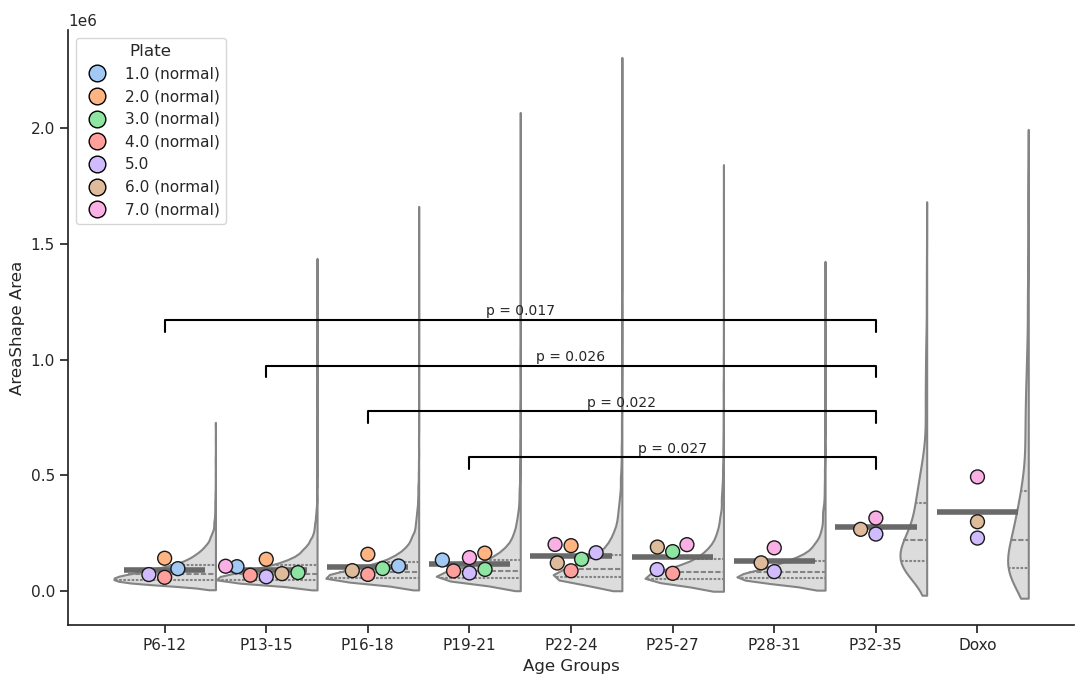

In [90]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None#"Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
#this_df = norm_cell_df_mitolyso.copy()
data_df = this_df # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
#this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude=[]
plot_dir = "plots/notnorm" 
os.makedirs(plot_dir, exist_ok=True)

figsize = (11, 7)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="games",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,#True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=False,
    legend=True,
    context = "talk",
    figsize = figsize,
    pallete=pallete,
    p_correction="fdr_bh"
    #truncate_outliers=True
)

#NOTE: R5 has smallest cells in p23-25, which is also highest mito density 

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2       F    p-unc    np2
---------  -------  -------  ------  -------  -----
AllGroups        8       43  13.362    0.000  0.713


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T    p-tukey    hedges
------  ------  ----------  ----------  -----------  ---------  ------  ---------  --------
Doxo    P13-15  347472.278   94098.301   253373.976  34474.397   7.350      0.000     3.701
Doxo    P16-18  347472.278  103961.970   243510.308  36565.620   6.660      0.000     2.949
Doxo    P19-21  347472.278  114712.716   232759.562  35008.916   6.649      0.000     3.106
Doxo    P22-24  347472.278  141147.302   206324.975  35008.916   5.893      0.000     2.549
Doxo    P25-27  347472.278  155080.394   192391.884  36565.620   5.262      0.000     2.044
Doxo    P28-31  347472.278  130904.965   216567.313  42222.341   5.129      0.000     1.772
Doxo    P32-35  347472.278  308865.162    38607.115  39495.383   0.978    

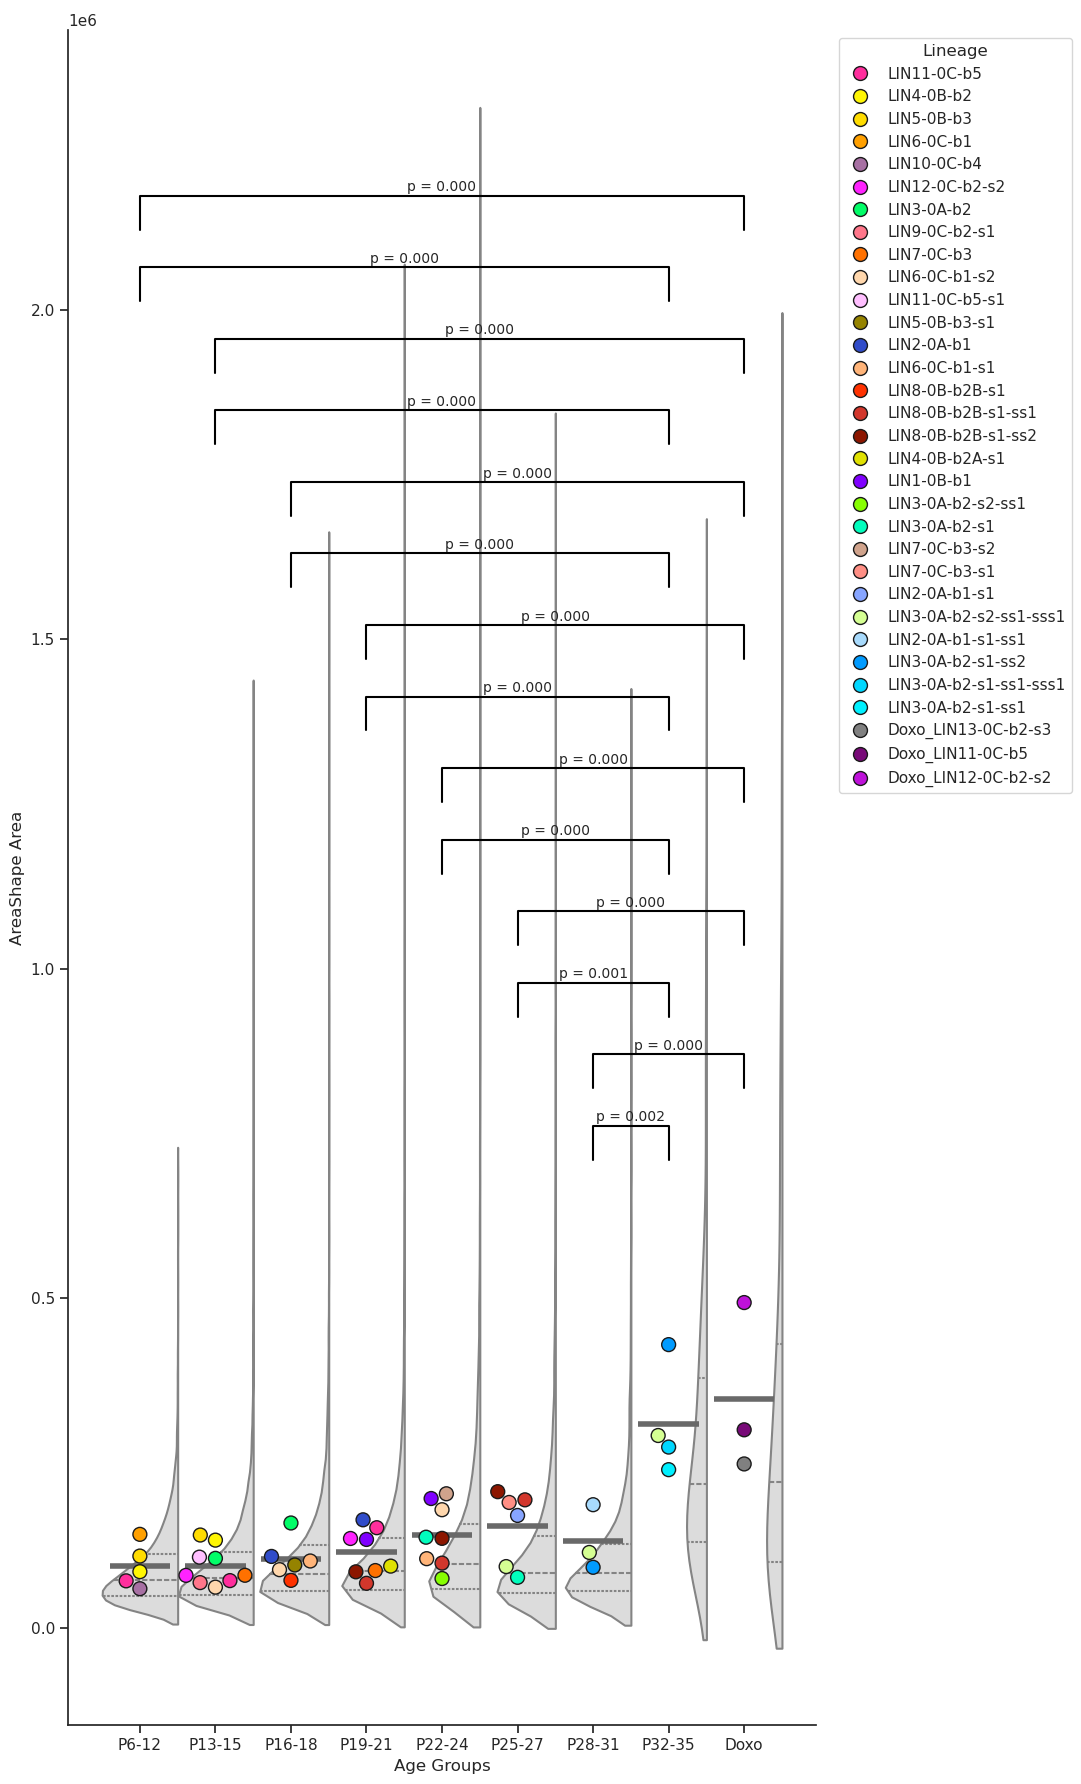

In [91]:
#Lineage Version
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"
stat_grouping = "Lineage"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
data_df = this_df 

no_drug_values = {None,"", "None", "none", "NoDrug", "Control", "control"}

drug_clean = data_df["Drug"].astype(str).str.strip()
data_df["Lineage"] = data_df["Lineage"].where(
    data_df["Drug"].isna() | drug_clean.isin(no_drug_values),
    drug_clean + "_" + data_df["Lineage"].astype(str),
)

data_df["Lineage"] = data_df["Lineage"].replace("LIN3-0A-b2-s2-ss1-ss1","LIN3-0A-b2-s2-ss1-sss1")
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-ss1"),
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-sss1"),
# )


def get_hard_code_lineage_colours(
    df, lineage_col_name="Lineage", plate_col_name="Plate_Number"
):
    """
    Returns a dictionary mapping each unique lineage number to a hard-coded color.
    This ensures color consistency for each Plate_Number in seaborn/matplotlib plots.
    """
    # Get colour codes from my csv and then convert it into a dict in the {key: #hexcode} format
    colour_codes = pd.read_csv(
        "proliferation_growth_curves/Lineage_only_hexcolour.csv"
    )
    hard_pallete_dict = dict(
        zip(colour_codes[lineage_col_name], colour_codes["Colour"])
    )

    # print(hard_pallete_dict)
    unique_lineages = sorted(df[lineage_col_name].drop_duplicates())
    # display(unique_lineages)

    # If more lineages than colors, fill in missing colours by using a default seaborn color_palette
    for lineage in unique_lineages:
        if lineage not in hard_pallete_dict:
            extra_colours = sns.color_palette("tab20", len(unique_lineages)).as_hex()
            hard_pallete_dict = {
                lineage: extra_colours[i] for i, lineage in enumerate(unique_lineages)
            }
    return hard_pallete_dict
lindict = {
    "LIN1-0B-b1": "#8000FF",
    "LIN2-0A-b1": "#304CC9",
    "LIN3-0A-b2": "#02FD68",
    "LIN4-0B-b2": "#FFF604",
    "LIN5-0B-b3": "#FFDC00",
    "LIN6-0C-b1": "#FFA000",
    "LIN2-0A-b1-s1": "#87A5FF",
    "LIN3-0A-b2-s1": "#01FDBD",
    "LIN4-0B-b2A-s1": "#E0E102",
    "LIN5-0B-b3-s1": "#958300",
    "LIN6-0C-b1-s1": "#FFB479",
    "LIN3-0A-b2-s2-ss1": "#87FE02",
    "LIN7-0C-b3": "#FF7100",
    "LIN8-0B-b2B-s1": "#FF3200",
    "LIN9-0C-b2-s1": "#FF768A",
    "LIN10-0C-b4": "#A770A3",
    "Doxo_LIN13-0C-b2-s3": "#808080",
    "LIN3-0A-b2-s1-ss1": "#00F0FF",
    "LIN3-0A-b2-s1-ss1-sss1": "#00D7FF",
    "LIN3-0A-b2-s1-ss2": "#019BFF",
    "LIN3-0A-b2-s2-ss1-sss1": "#D5FF93",
    "LIN7-0C-b3-s1": "#FF8F85",
    "LIN8-0B-b2B-s1-ss1": "#D2372C",
    "LIN8-0B-b2B-s1-ss2": "#8C1600",
    "LIN6-0C-b1-s2": "#FFD7AD",
    "LIN11-0C-b5": "#FF2E9D",
    "Doxo_LIN11-0C-b5": "#780A78",
    "LIN12-0C-b2-s2": "#FF23FF",
    "Doxo_LIN12-0C-b2-s2": "#BE12D9",
    "LIN2-0A-b1-s1-ss1": "#A8DAFC",
    "LIN7-0C-b3-s2": "#D0A38C",
    "LIN11-0C-b5-s1": "#FFBFFF",
}
# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_lineage_colours(data_df)
pallete = lindict 

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/lineage"
os.makedirs(plot_dir, exist_ok=True)

figsize = (11, 18)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name=stat_grouping,
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=False,
    truncate_outliers=True,
    legend=True,
    context="talk",
    figsize=figsize,
    pallete=pallete,
    shapiro=False
    #p_correction="fdr_bh",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density


## Make multiple plots as defined

/tmp/ipykernel_1186/718203363.py:94: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1186/718203363.py:98: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2       F    p-unc    np2
---------  -------  -------  ------  -------  -----
AllGroups        8       43  13.456    0.000  0.715


POST HOC TESTS

A       B          mean(A)     mean(B)         diff         se       T    p-tukey    hedges
------  ------  ----------  ----------  -----------  ---------  ------  ---------  --------
Doxo    P13-15  348068.801   94149.416   253919.385  34403.266   7.381      0.000     3.726
Doxo    P16-18  348068.801  104033.143   244035.658  36490.174   6.688      0.000     2.970
Doxo    P19-21  348068.801  114754.636   233314.164  34936.682   6.678      0.000     3.126
Doxo    P22-24  348068.801  141223.827   206844.974  34936.682   5.921      0.000     2.566
Doxo    P25-27  348068.801  155217.896   192850.905  36490.174   5.285      0.000     2.056
Doxo    P28-31  348068.801  130938.104   217130.697  42135.224   5.153      0.000     1.785
Doxo    P32-35  348068.801  309033.799    39035.002  39413.893   0.990    

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



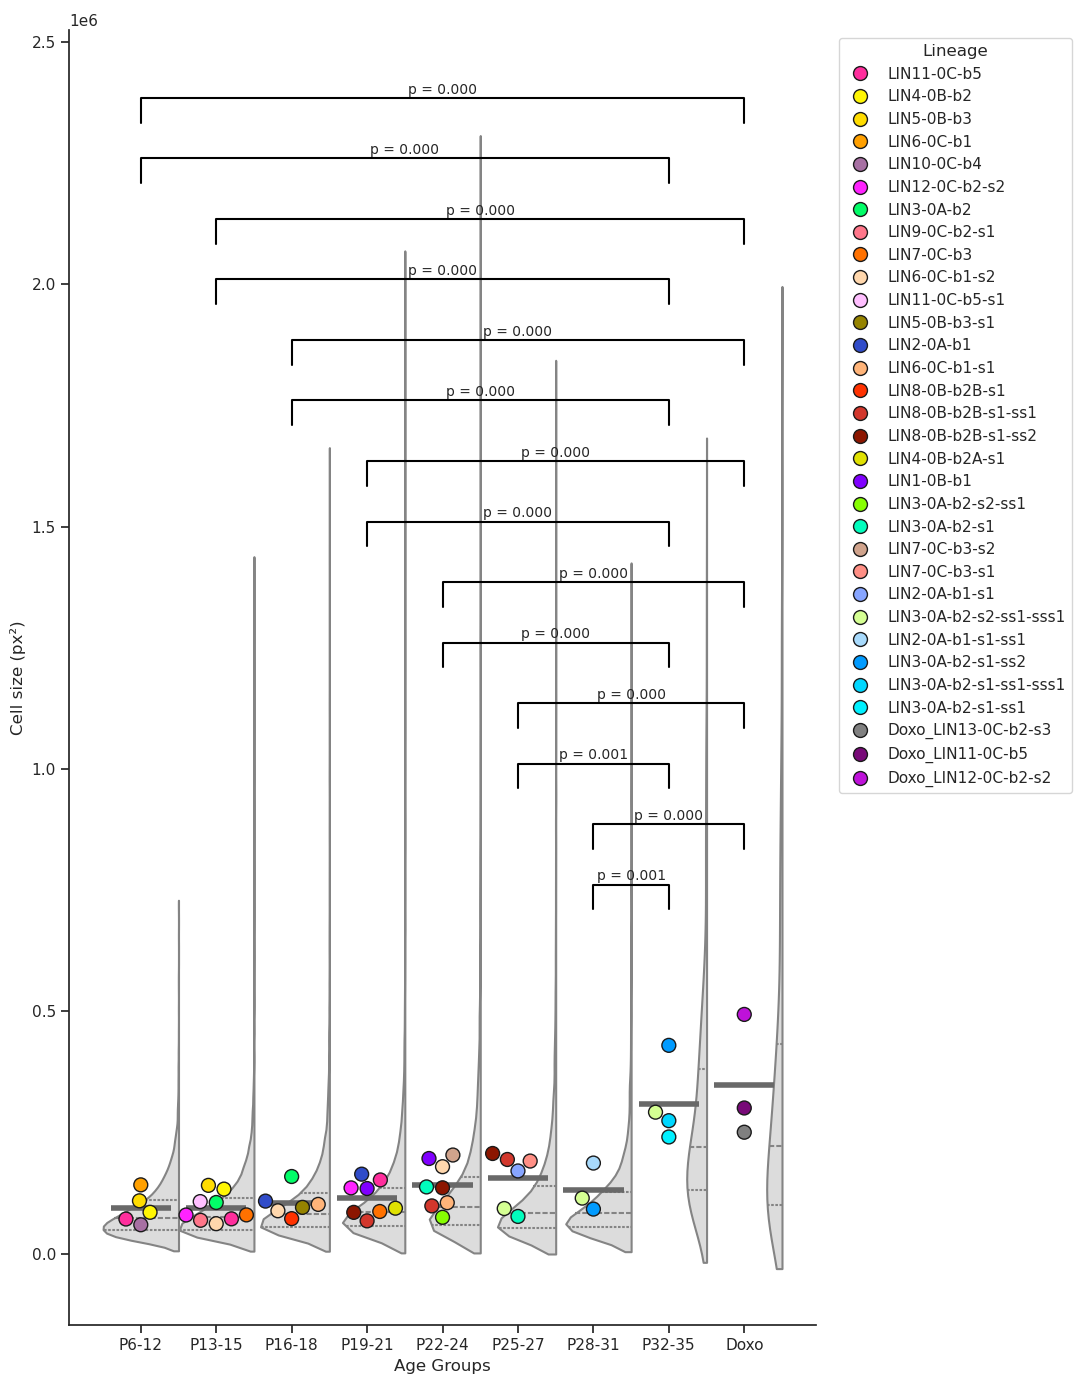

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2       F    p-unc    np2
---------  -------  -------  ------  -------  -----
AllGroups        8       43  11.992    0.000  0.691


POST HOC TESTS

A       B         mean(A)    mean(B)        diff        se       T    p-tukey    hedges
------  ------  ---------  ---------  ----------  --------  ------  ---------  --------
Doxo    P13-15  42889.301  22058.174   20831.127  2981.385   6.987      0.000     3.641
Doxo    P16-18  42889.301  22771.045   20118.256  3162.237   6.362      0.000     3.185
Doxo    P19-21  42889.301  23565.214   19324.087  3027.611   6.383      0.000     3.031
Doxo    P22-24  42889.301  25082.791   17806.510  3027.611   5.881      0.000     2.880
Doxo    P25-27  42889.301  25689.576   17199.724  3162.237   5.439      0.000     2.452
Doxo    P28-31  42889.301  26041.922   16847.379  3651.437   4.614      0.001     2.014
Doxo    P32-35  42889.301  39471.808    3417.493  3415.606   1.001      0.984     0.406
Doxo    P6-12   42

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



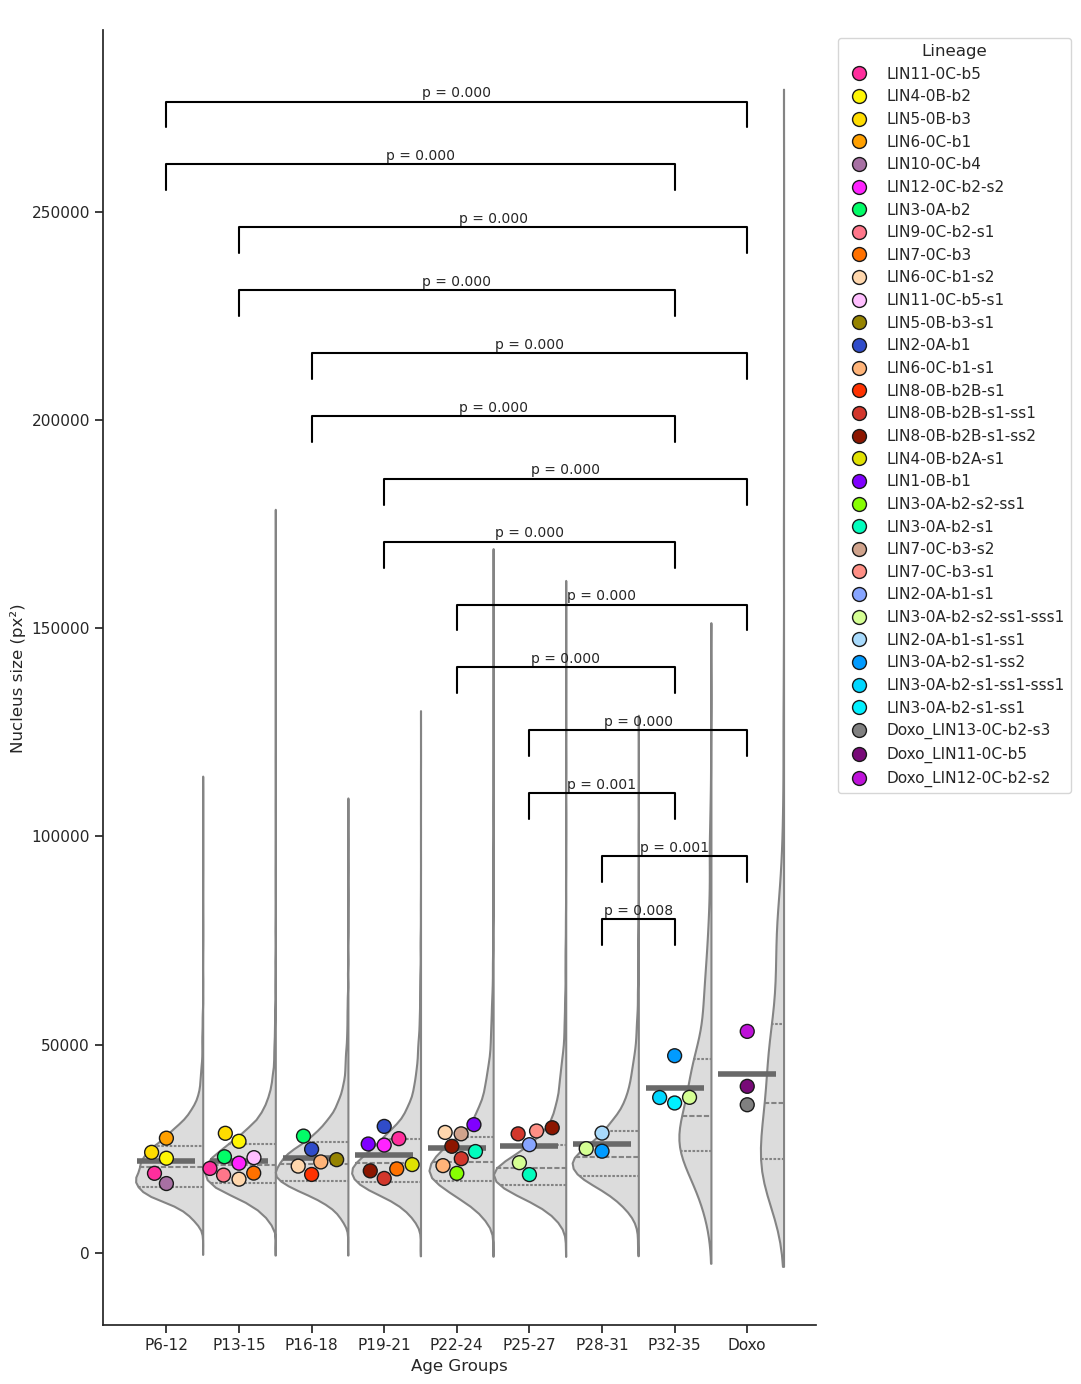

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

37.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/


ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  4.912    0.000  0.478


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      9.225      4.799   4.427  1.559   2.839      0.134     2.796
Doxo    P16-18      9.225      4.751   4.475  1.654   2.706      0.176     2.906
Doxo    P19-21      9.225      5.044   4.181  1.583   2.641      0.200     2.522
Doxo    P22-24      9.225      5.626   3.599  1.583   2.273      0.380     2.187
Doxo    P25-27      9.225      5.736   3.489  1.654   2.110      0.480     1.912
Doxo    P28-31      9.225      4.812   4.413  1.910   2.311      0.358     1.963
Doxo    P32-35      9.225     11.759  -2.534  1.786  -1.419      0.884    -0.347
Doxo    P6-12       9.225      4.106   5.119  1.708   2.997      0.094     3.120
P13

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points c

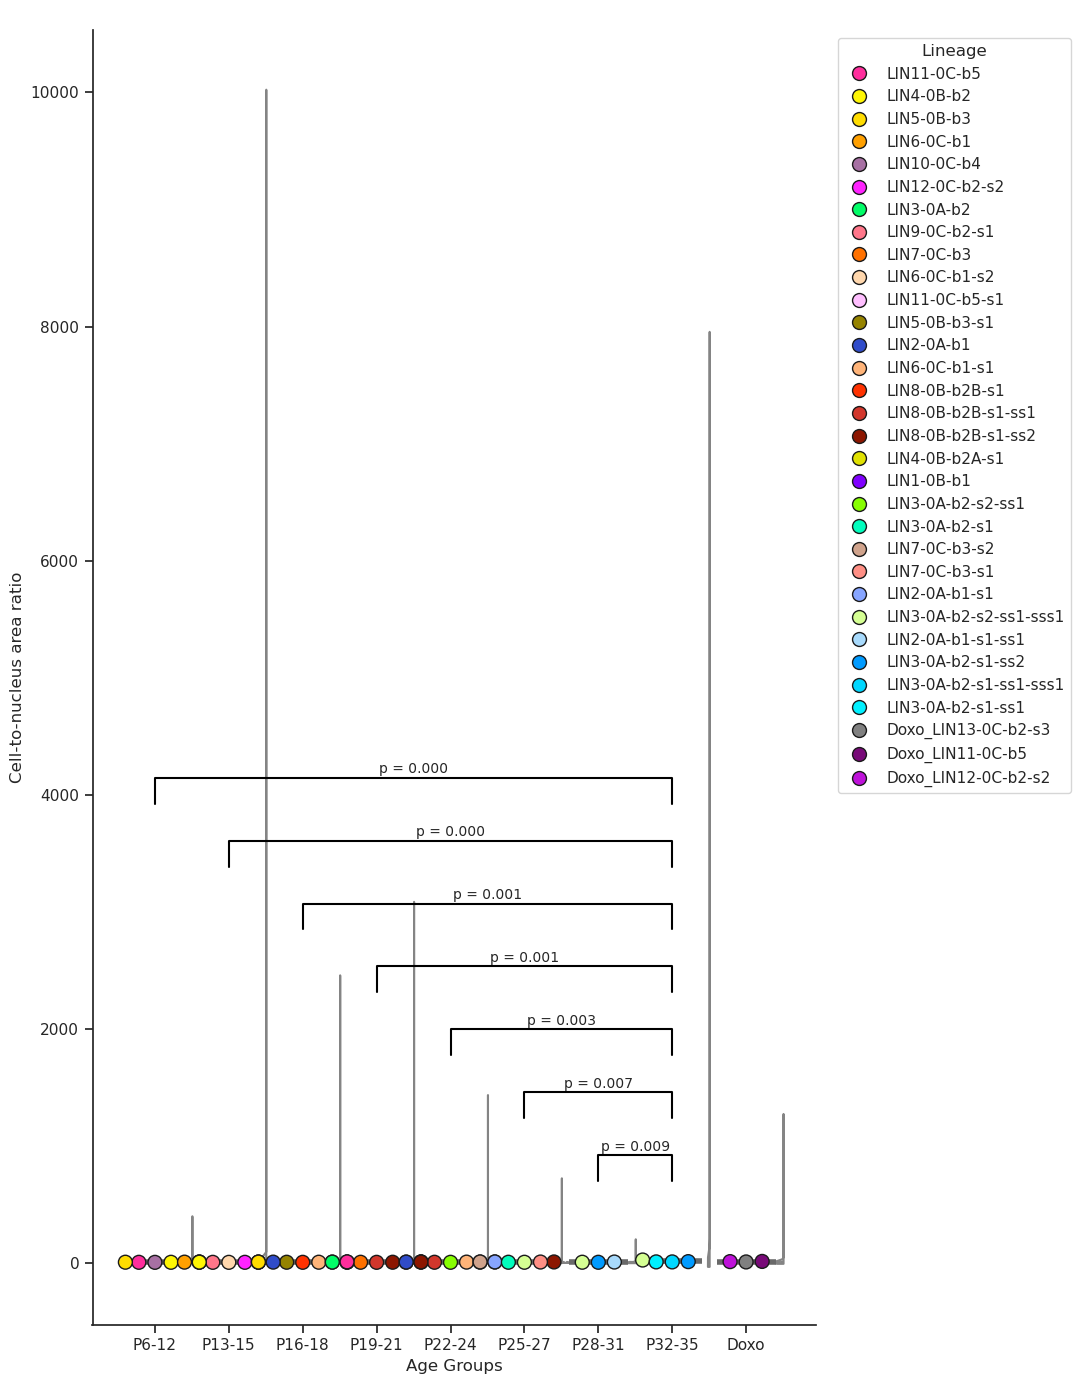

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  2.348    0.034  0.304


POST HOC TESTS

A       B         mean(A)    mean(B)     diff      se       T    p-tukey    hedges
------  ------  ---------  ---------  -------  ------  ------  ---------  --------
Doxo    P13-15    145.437    200.678  -55.241  19.489  -2.834      0.135    -1.457
Doxo    P16-18    145.437    195.767  -50.329  20.672  -2.435      0.292    -1.786
Doxo    P19-21    145.437    189.437  -43.999  19.792  -2.223      0.410    -1.631
Doxo    P22-24    145.437    187.761  -42.324  19.792  -2.138      0.462    -1.511
Doxo    P25-27    145.437    178.825  -33.388  20.672  -1.615      0.791    -1.376
Doxo    P28-31    145.437    165.815  -20.378  23.870  -0.854      0.994    -0.858
Doxo    P32-35    145.437    142.573    2.865  22.328   0.128      1.000     0.191
Doxo    P6-12     145.437    182.180  -36.742  21.350  -1.721     

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



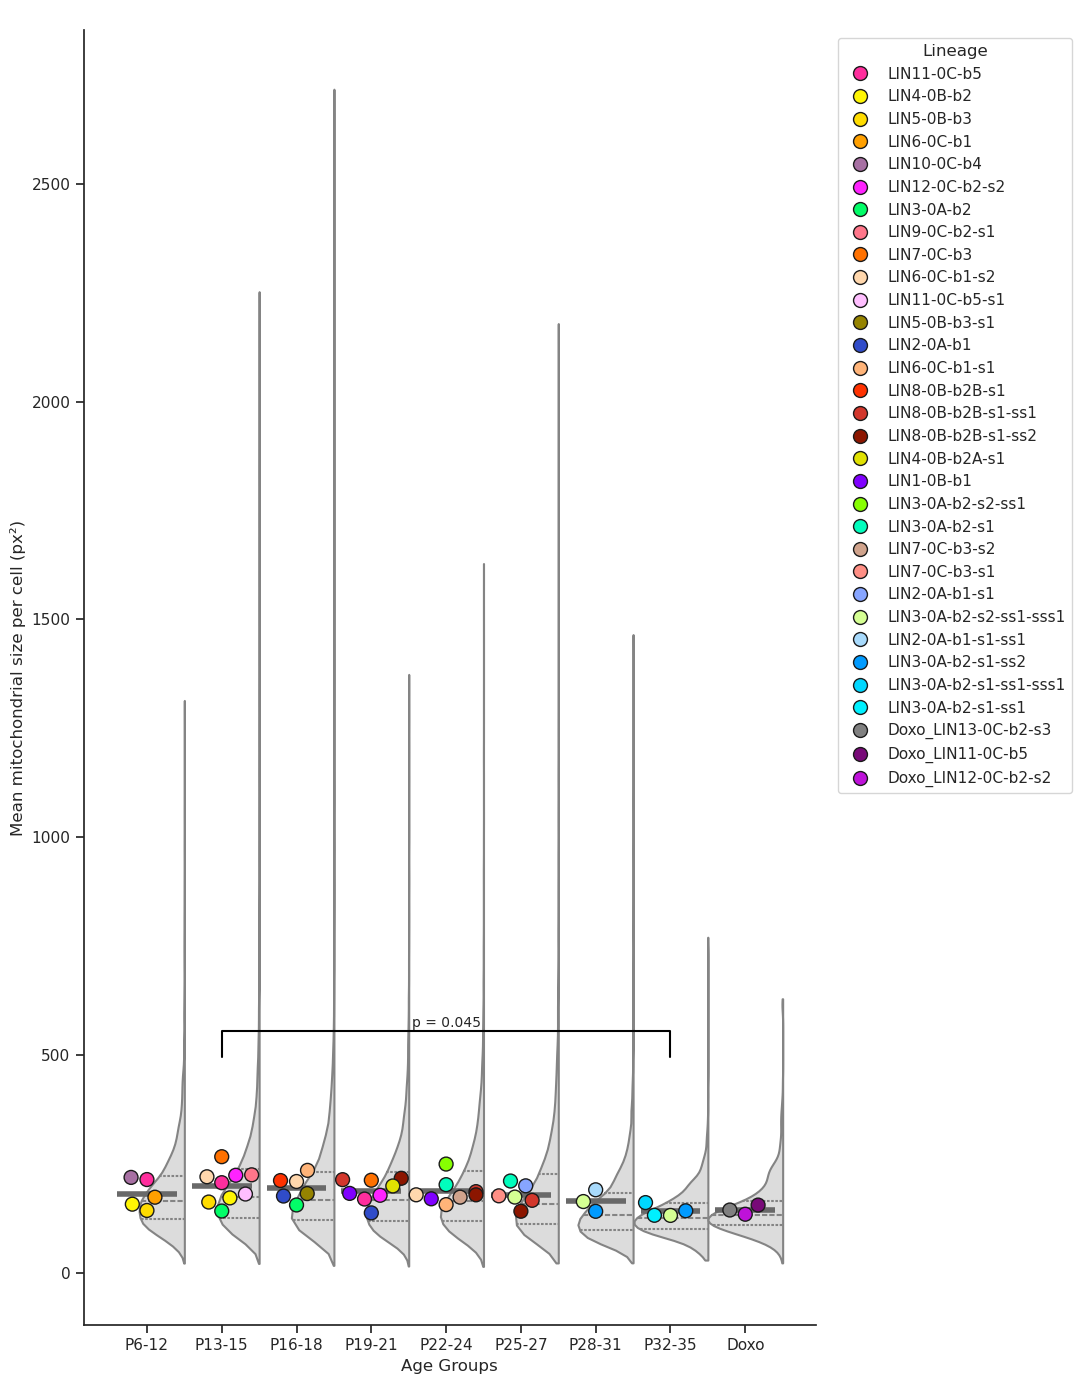

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  2.324    0.036  0.302


POST HOC TESTS

A       B         mean(A)    mean(B)     diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  -------  -----  ------  ---------  --------
Doxo    P13-15     68.971     90.180  -21.209  7.786  -2.724      0.170    -1.366
Doxo    P16-18     68.971     89.005  -20.034  8.258  -2.426      0.297    -1.788
Doxo    P19-21     68.971     86.142  -17.171  7.906  -2.172      0.441    -1.612
Doxo    P22-24     68.971     84.248  -15.277  7.906  -1.932      0.596    -1.337
Doxo    P25-27     68.971     81.733  -12.762  8.258  -1.545      0.828    -1.169
Doxo    P28-31     68.971     76.050   -7.079  9.536  -0.742      0.998    -0.981
Doxo    P32-35     68.971     67.039    1.932  8.920   0.217      1.000     0.357
Doxo    P6-12      68.971     82.852  -13.881  8.529  -1.627      0.785    

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



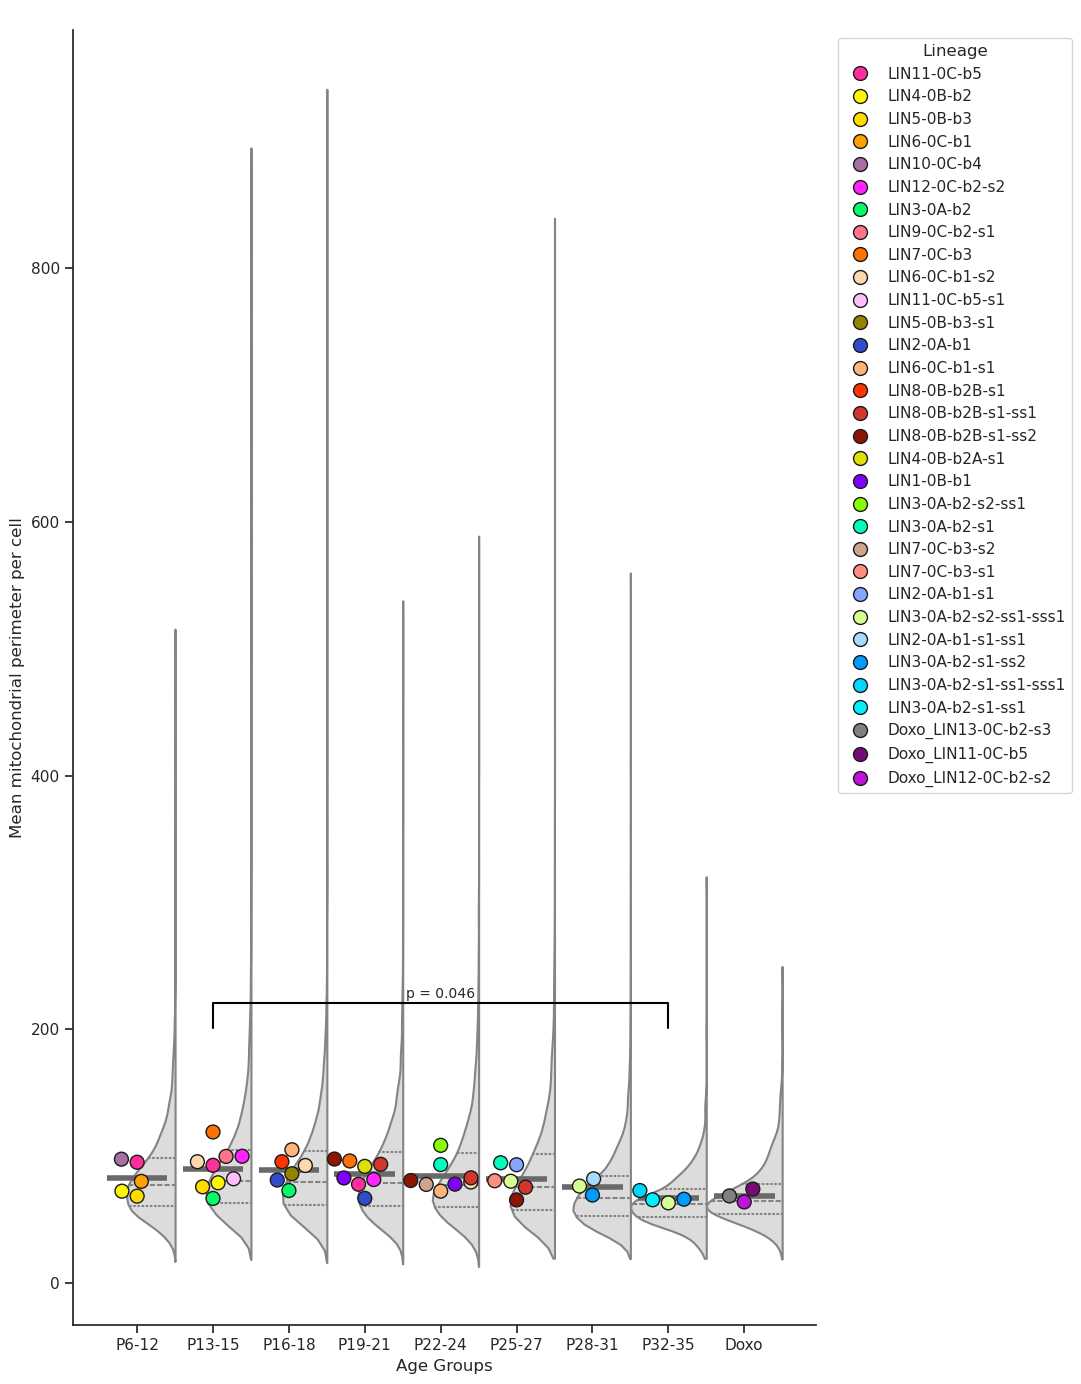

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.651    0.139  0.235

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


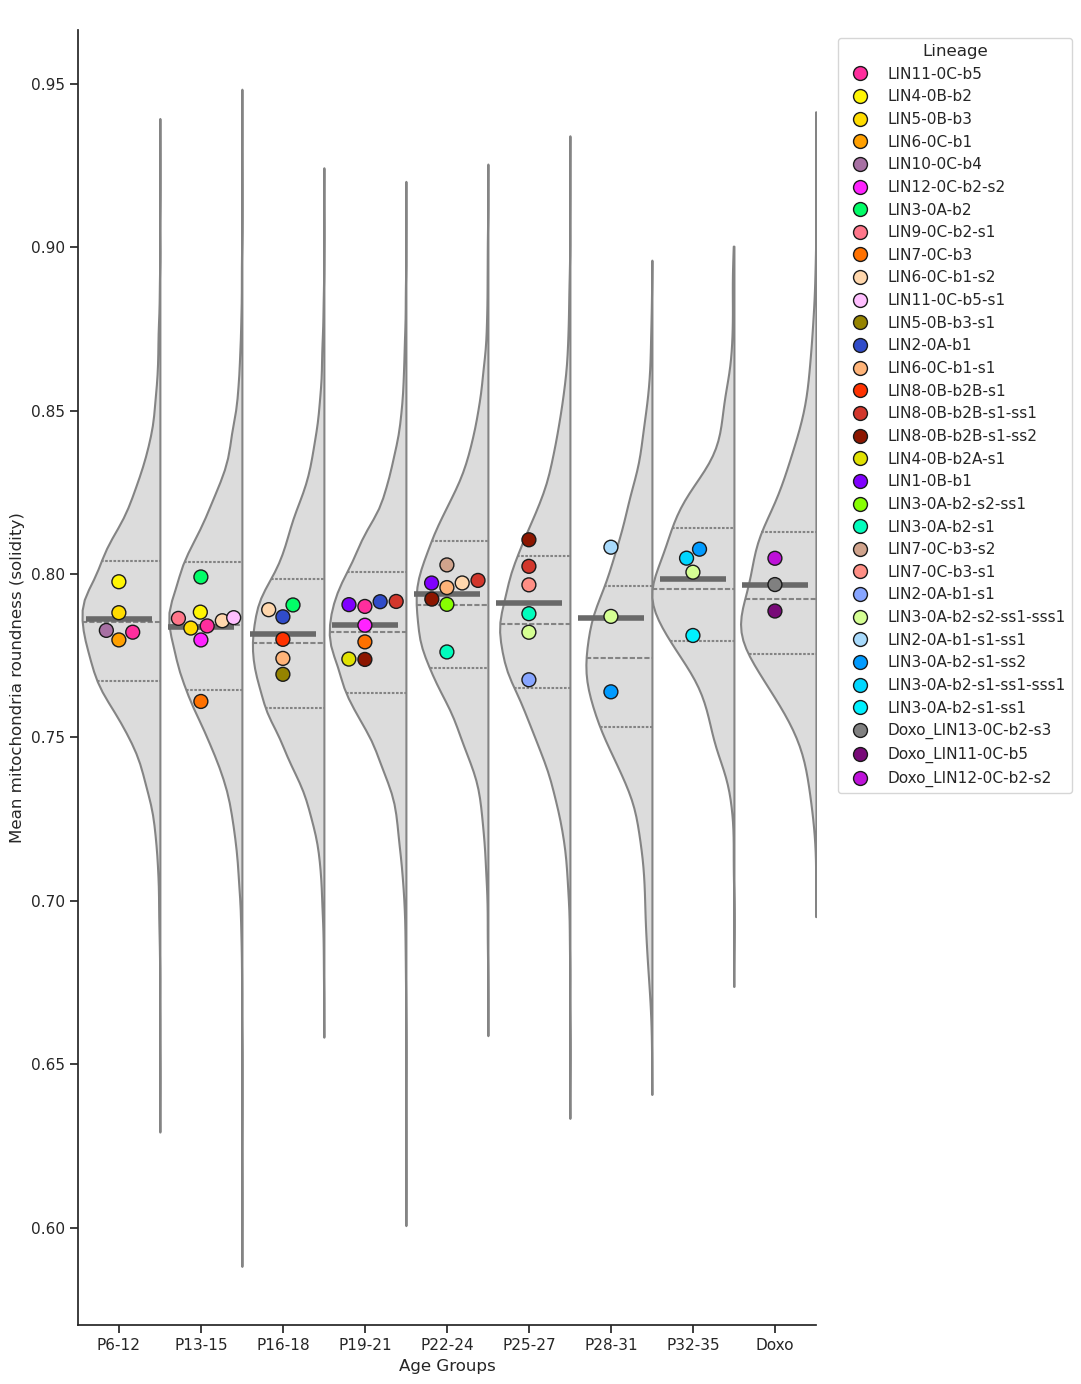

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


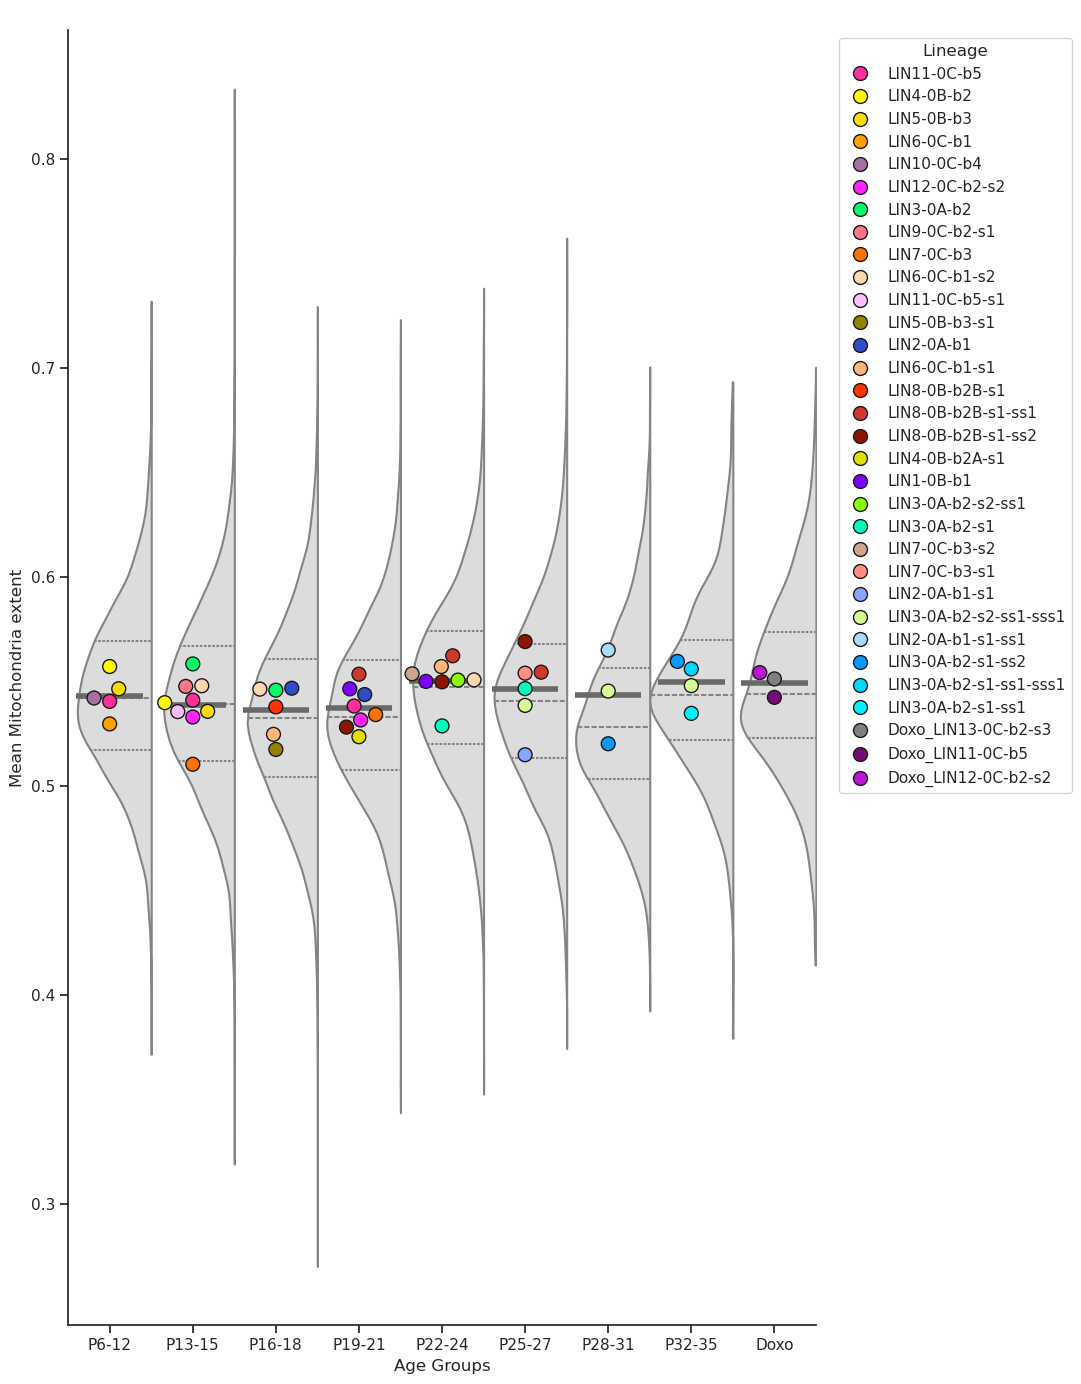

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  2.630    0.019  0.329


POST HOC TESTS

A       B         mean(A)    mean(B)      diff       se       T    p-tukey    hedges
------  ------  ---------  ---------  --------  -------  ------  ---------  --------
Doxo    P13-15    656.476   1512.899  -856.423  278.267  -3.078      0.078    -1.770
Doxo    P16-18    656.476   1236.456  -579.980  295.147  -1.965      0.575    -1.535
Doxo    P19-21    656.476   1253.346  -596.870  282.582  -2.112      0.479    -1.236
Doxo    P22-24    656.476   1149.690  -493.214  282.582  -1.745      0.716    -1.338
Doxo    P25-27    656.476   1063.497  -407.021  295.147  -1.379      0.900    -1.066
Doxo    P28-31    656.476    950.850  -294.374  340.806  -0.864      0.994    -0.749
Doxo    P32-35    656.476    665.327    -8.851  318.795  -0.028      1.000    -0.031
Doxo    P6-12     656.476   1489.563  -833.087  

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

33.3% of the points c

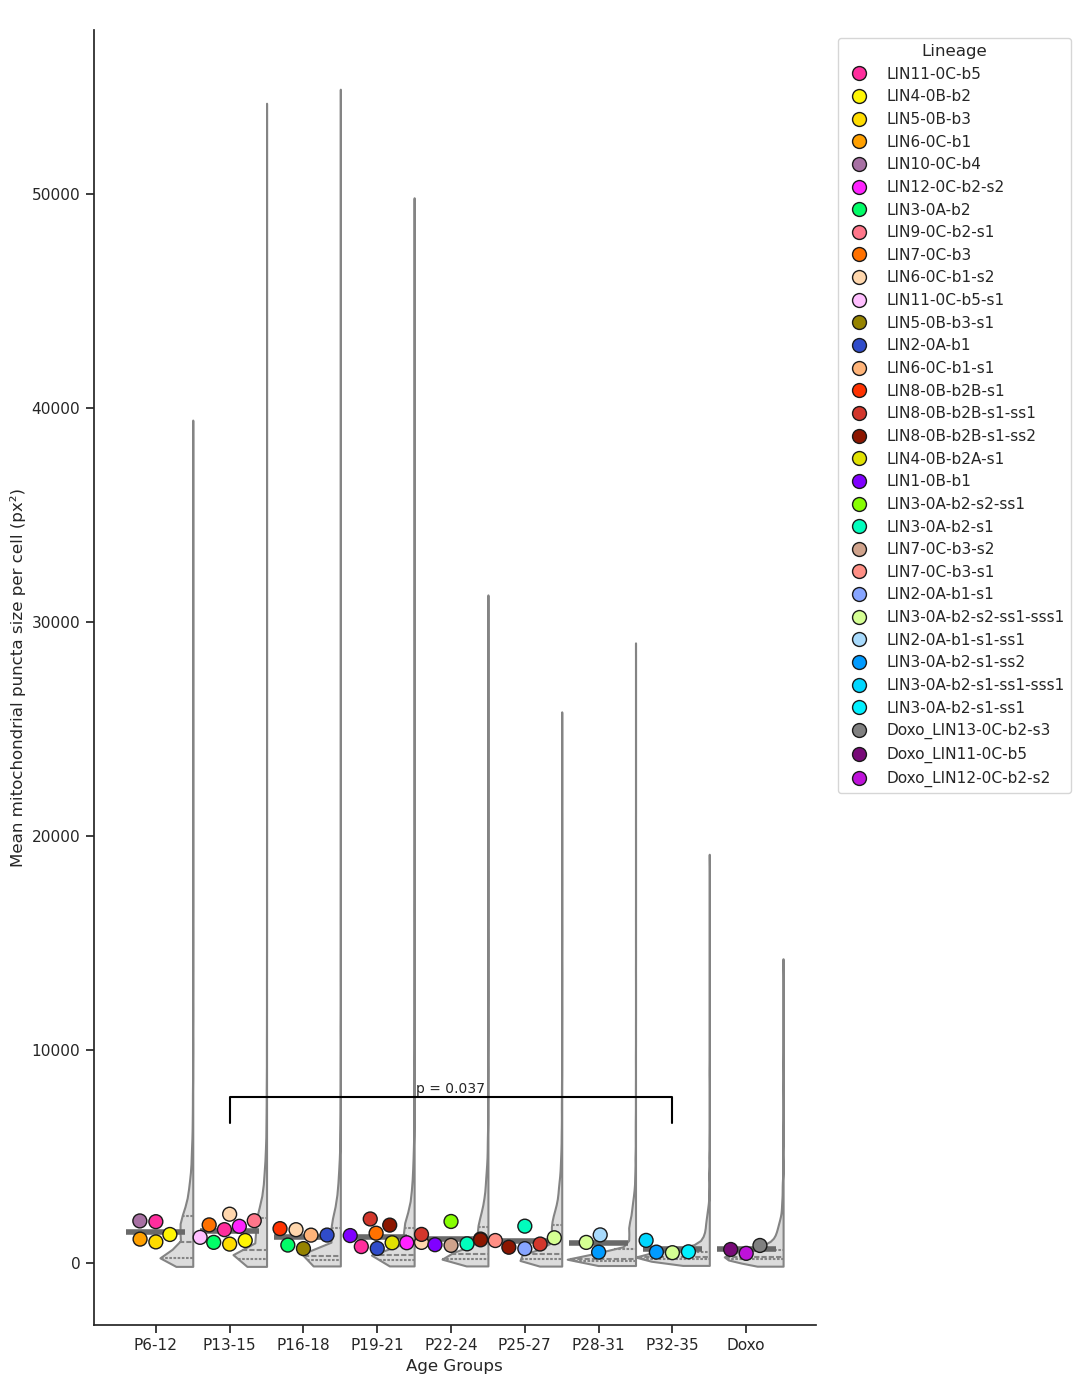

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  3.064    0.008  0.363


POST HOC TESTS

A       B         mean(A)    mean(B)     diff      se       T    p-tukey    hedges
------  ------  ---------  ---------  -------  ------  ------  ---------  --------
Doxo    P13-15    116.067    214.128  -98.061  29.698  -3.302      0.046    -1.893
Doxo    P16-18    116.067    182.631  -66.564  31.499  -2.113      0.478    -1.593
Doxo    P19-21    116.067    184.021  -67.954  30.158  -2.253      0.392    -1.396
Doxo    P22-24    116.067    171.018  -54.951  30.158  -1.822      0.668    -1.400
Doxo    P25-27    116.067    164.718  -48.651  31.499  -1.545      0.828    -1.121
Doxo    P28-31    116.067    147.024  -30.957  36.372  -0.851      0.994    -0.732
Doxo    P32-35    116.067    118.496   -2.429  34.023  -0.071      1.000    -0.075
Doxo    P6-12     116.067    214.267  -98.200  32.532  -3.019     

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

50.0% of the points c

P13-15 vs. Doxo: Custom statistical test, P_val:4.555e-02


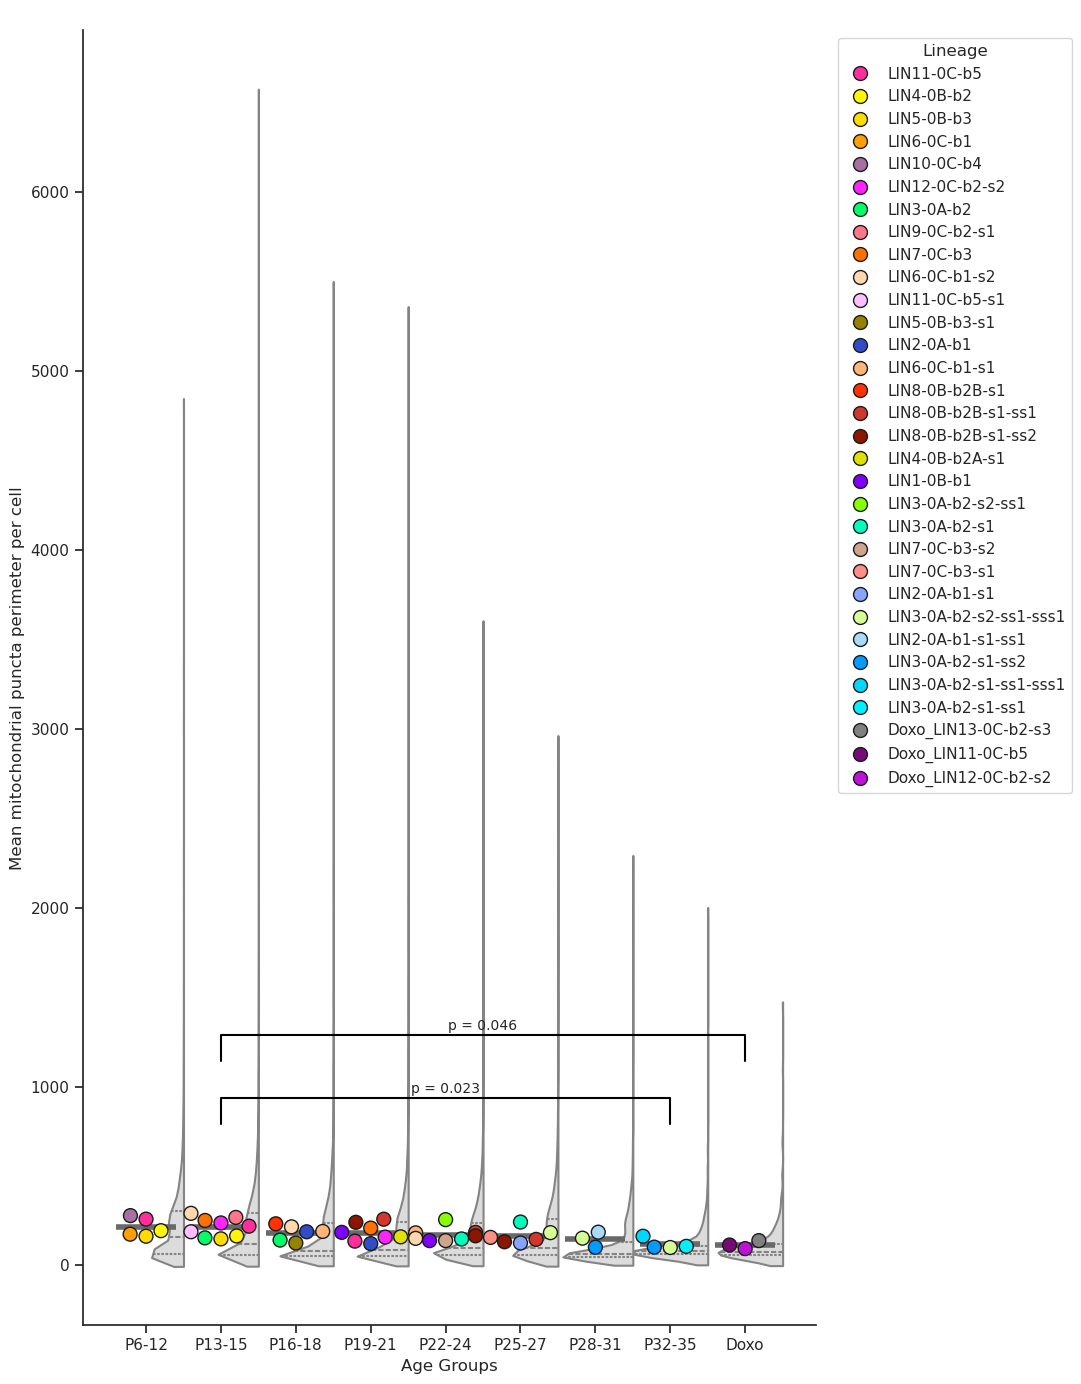

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.617    0.759  0.103

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


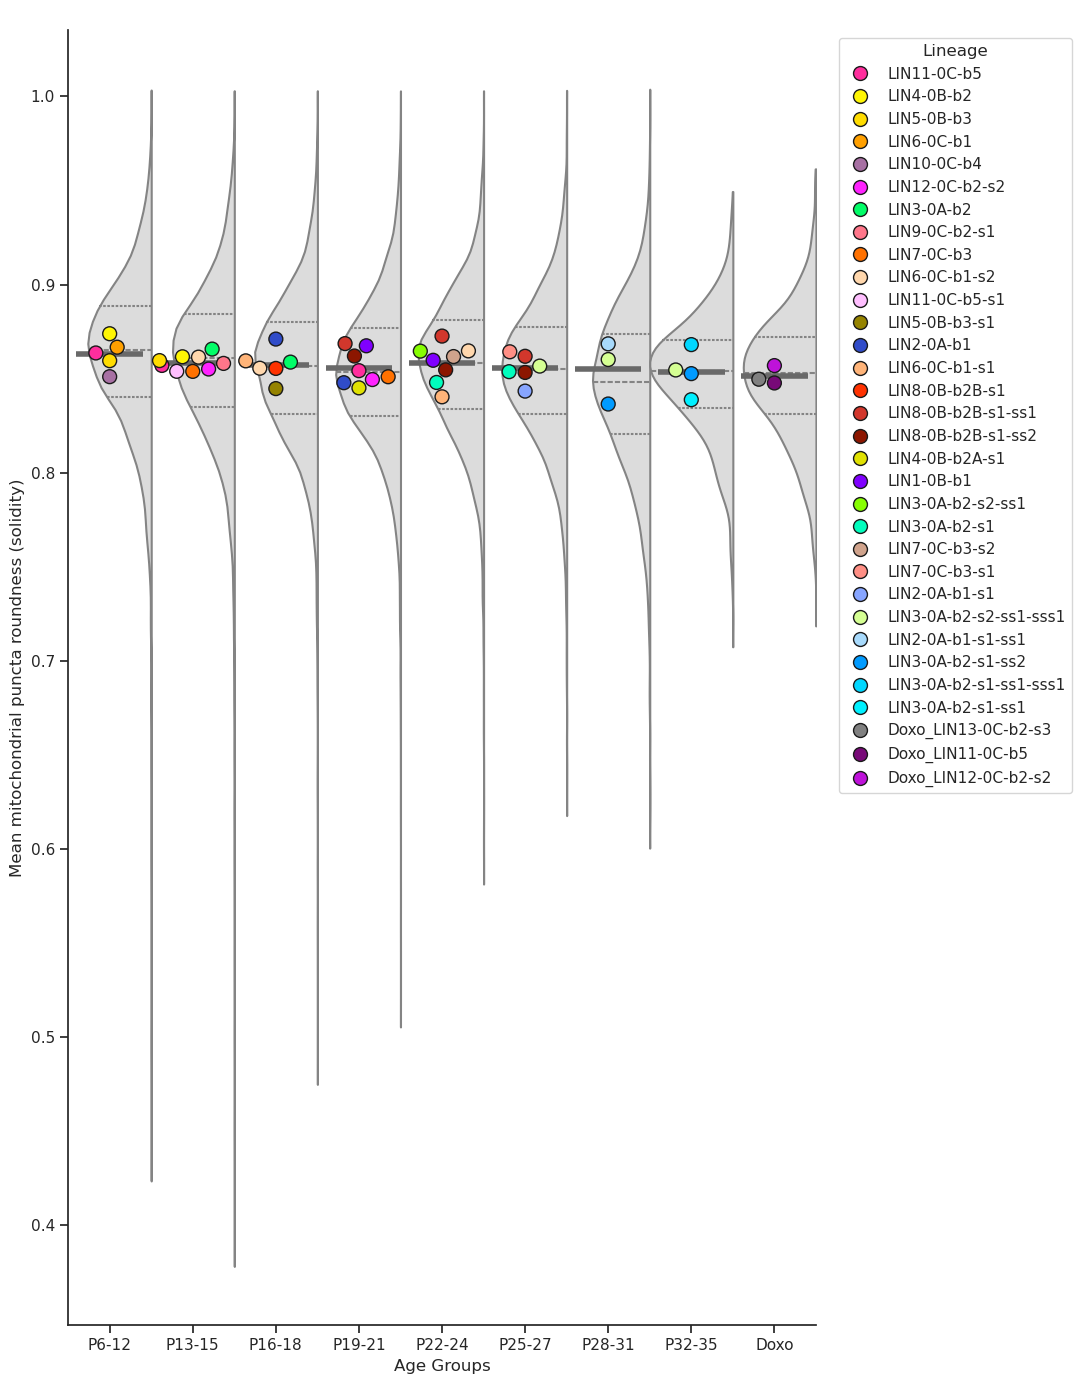

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.764    0.636  0.124

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


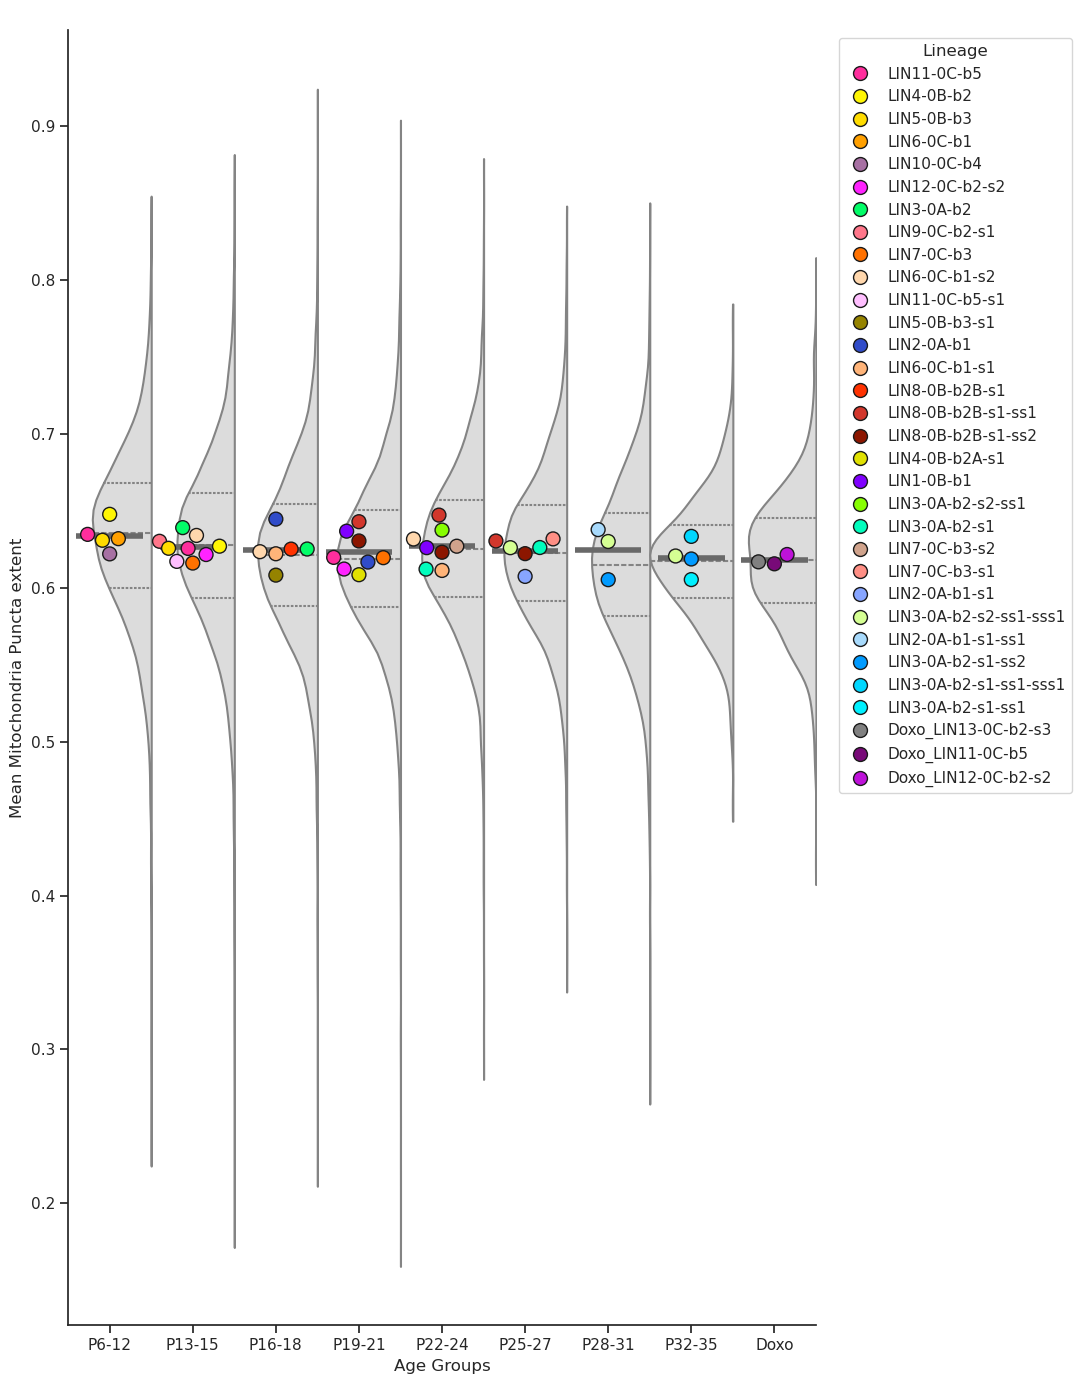

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.769    0.632  0.125

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


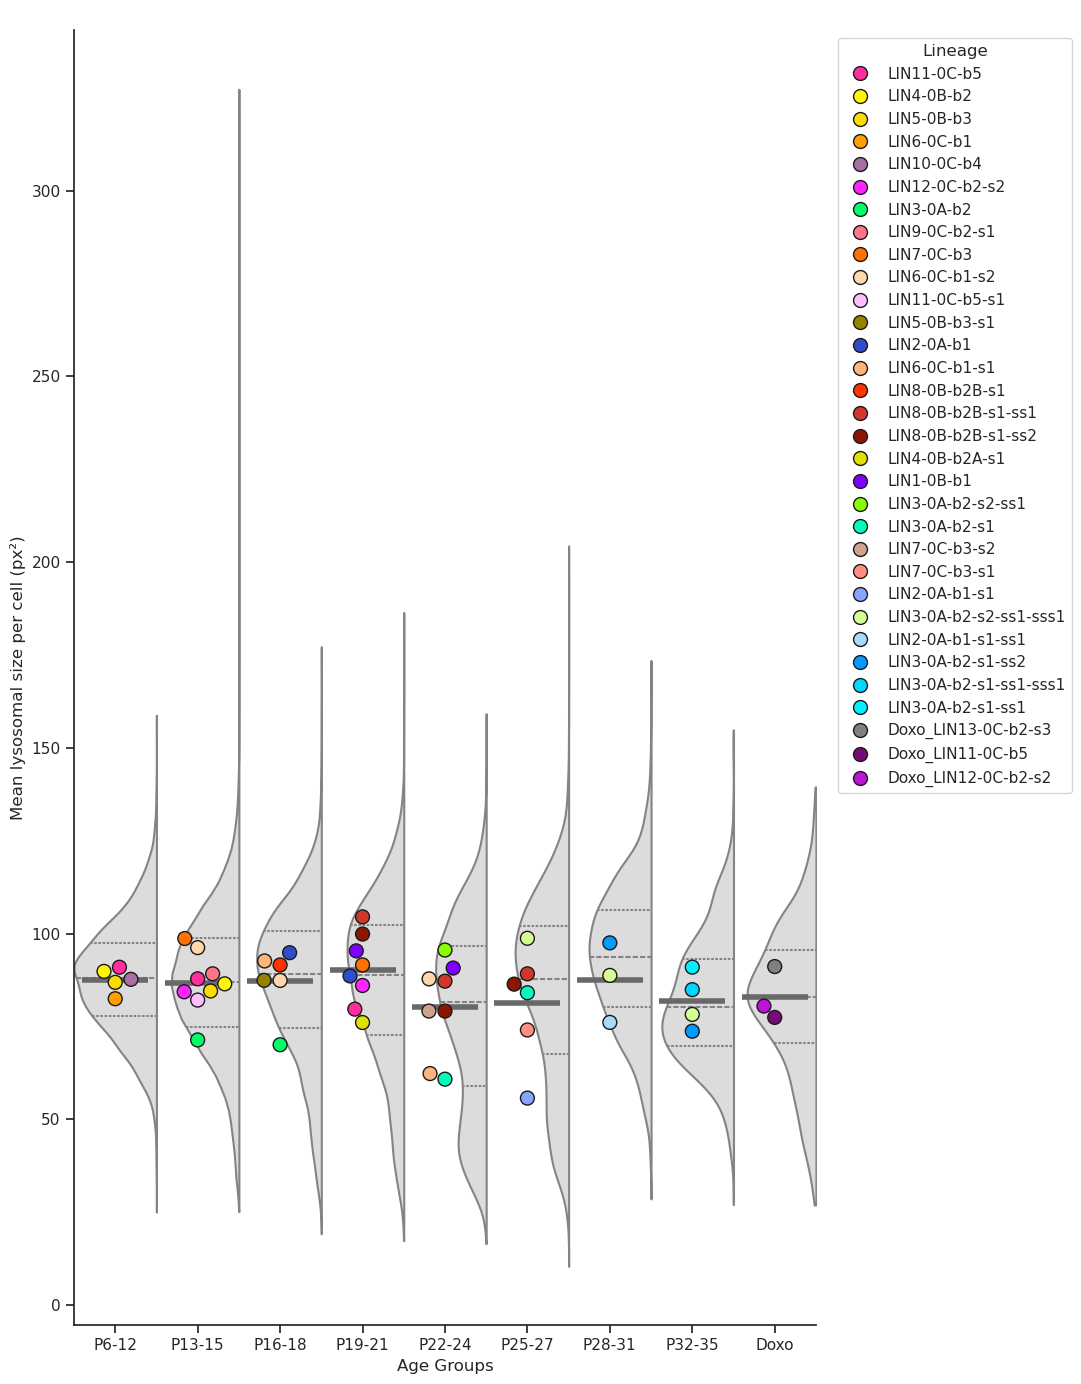

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.743    0.654  0.121

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


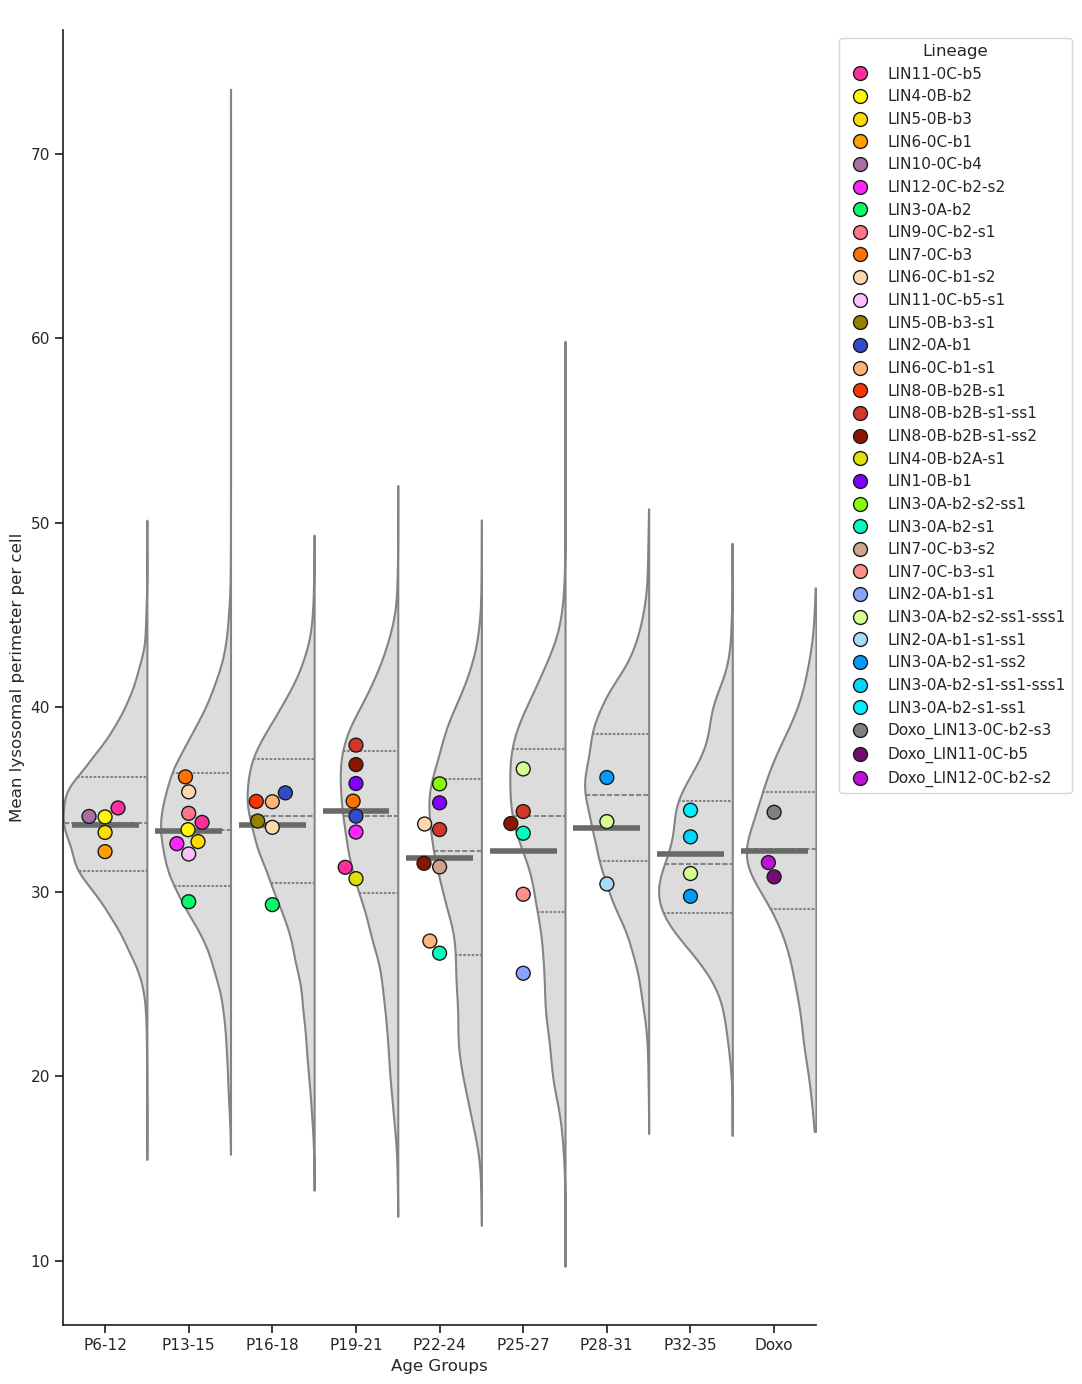

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.386    0.230  0.205

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


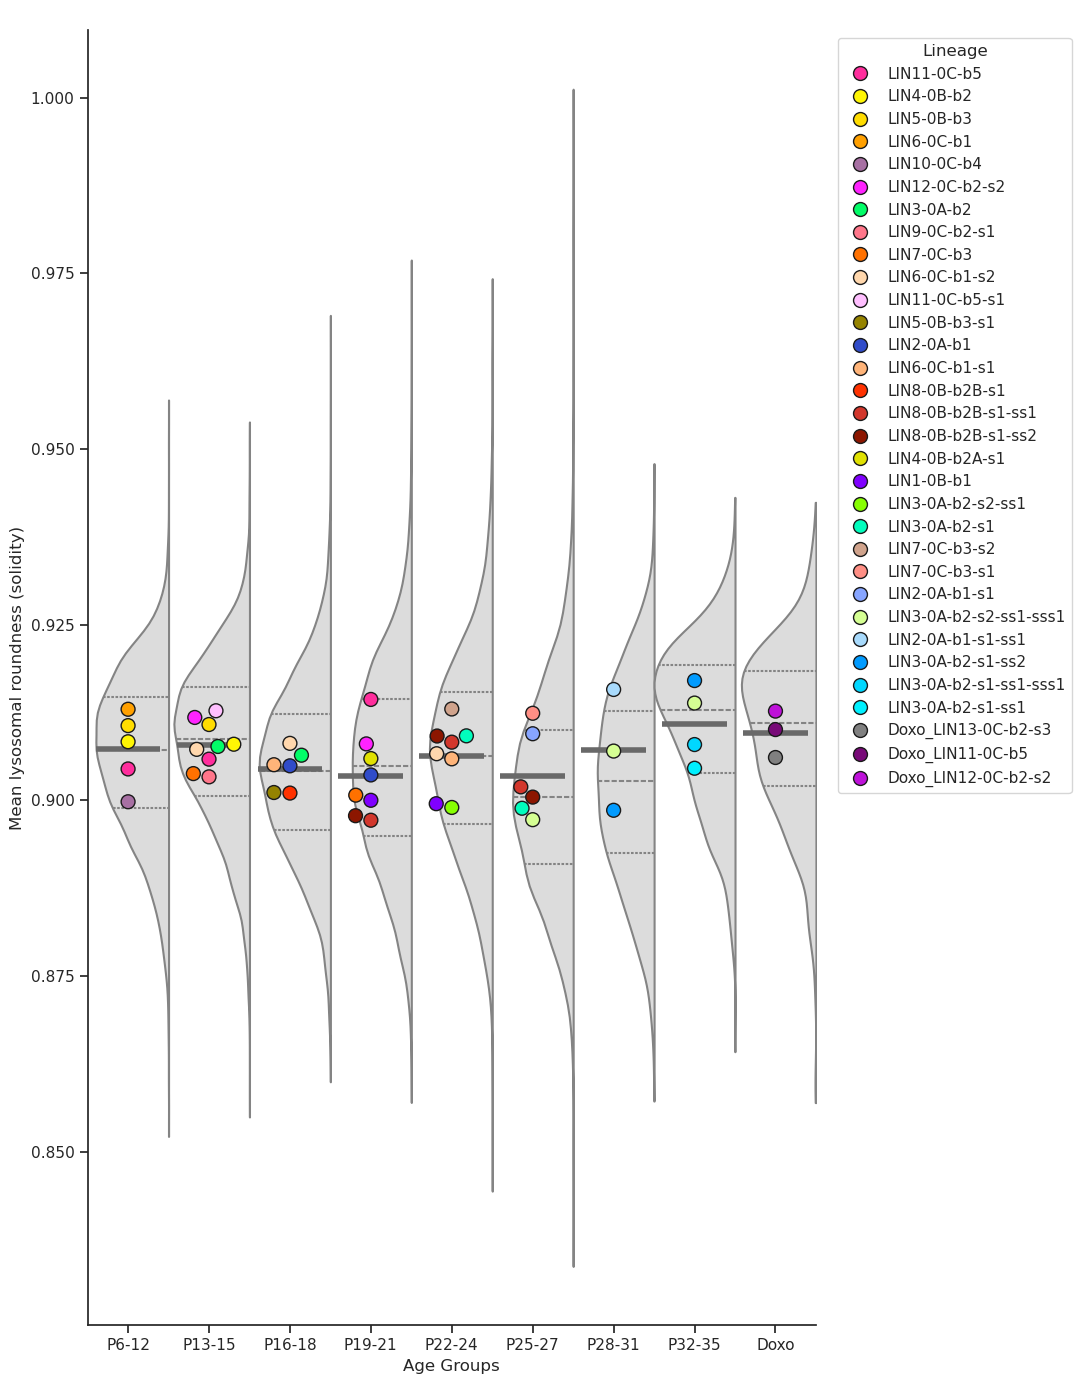

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.122    0.368  0.173

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


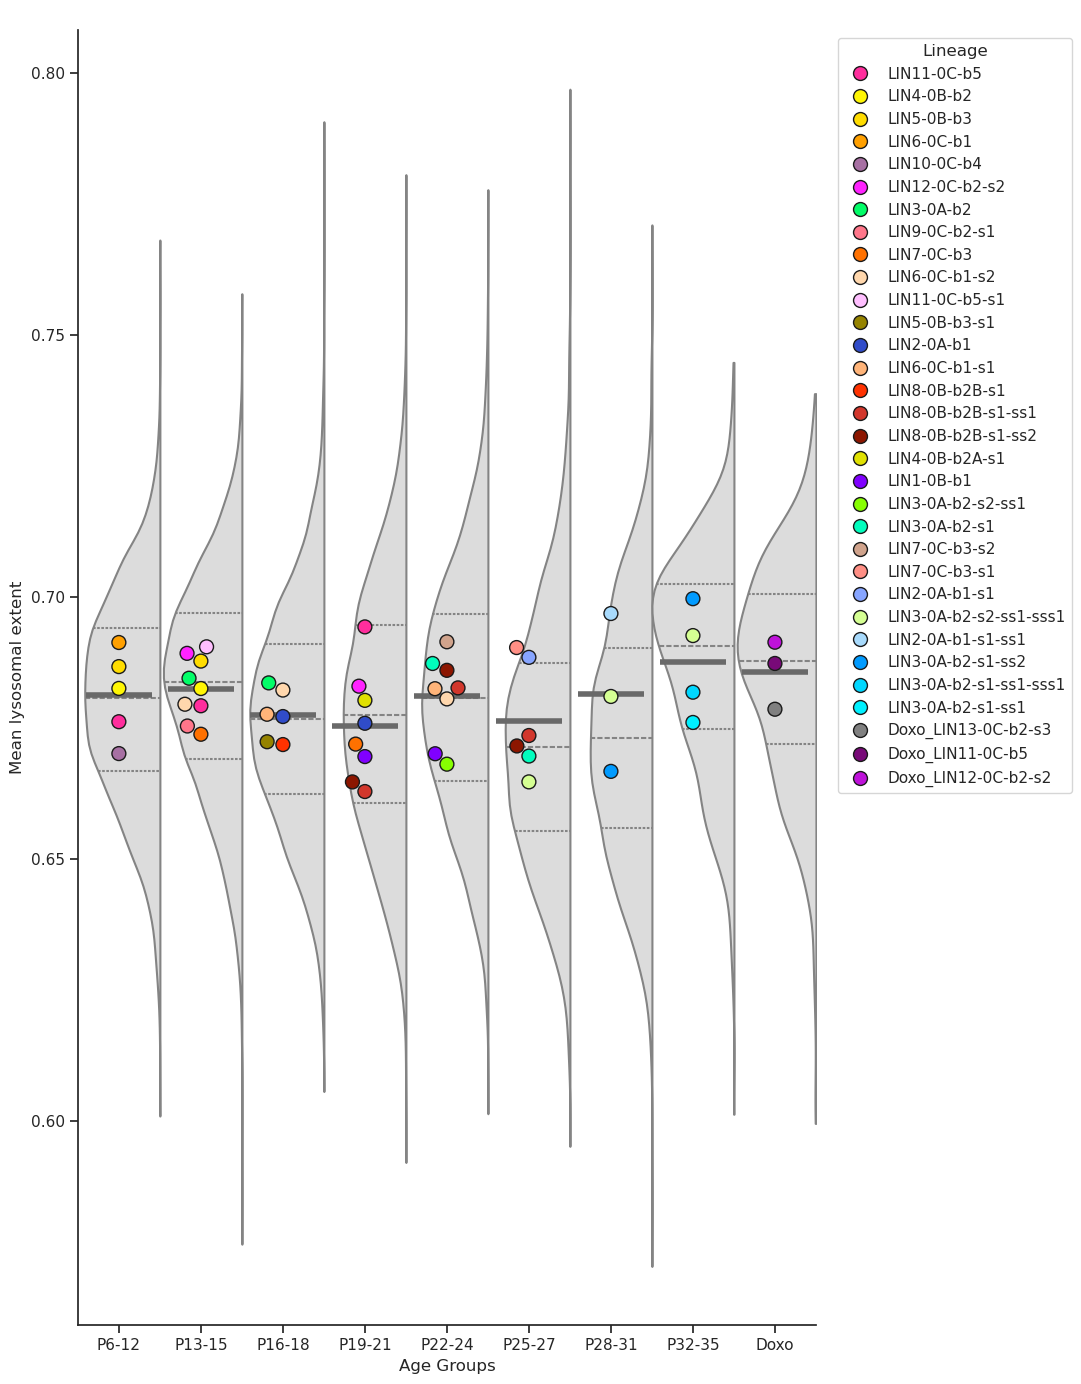

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.446    0.886  0.077

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


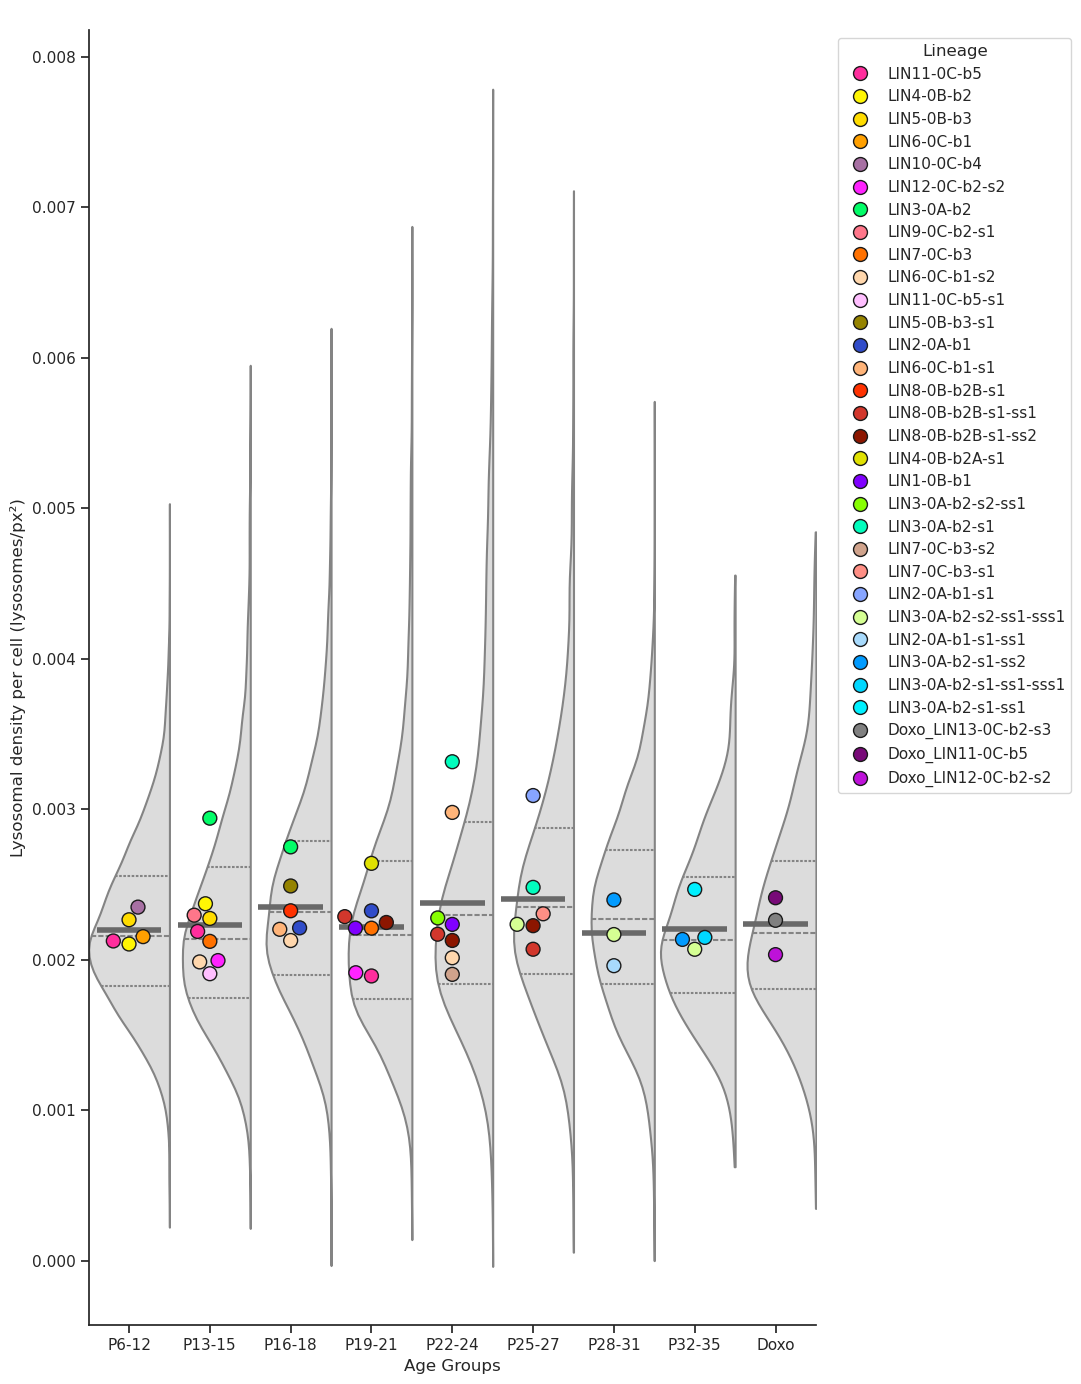

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



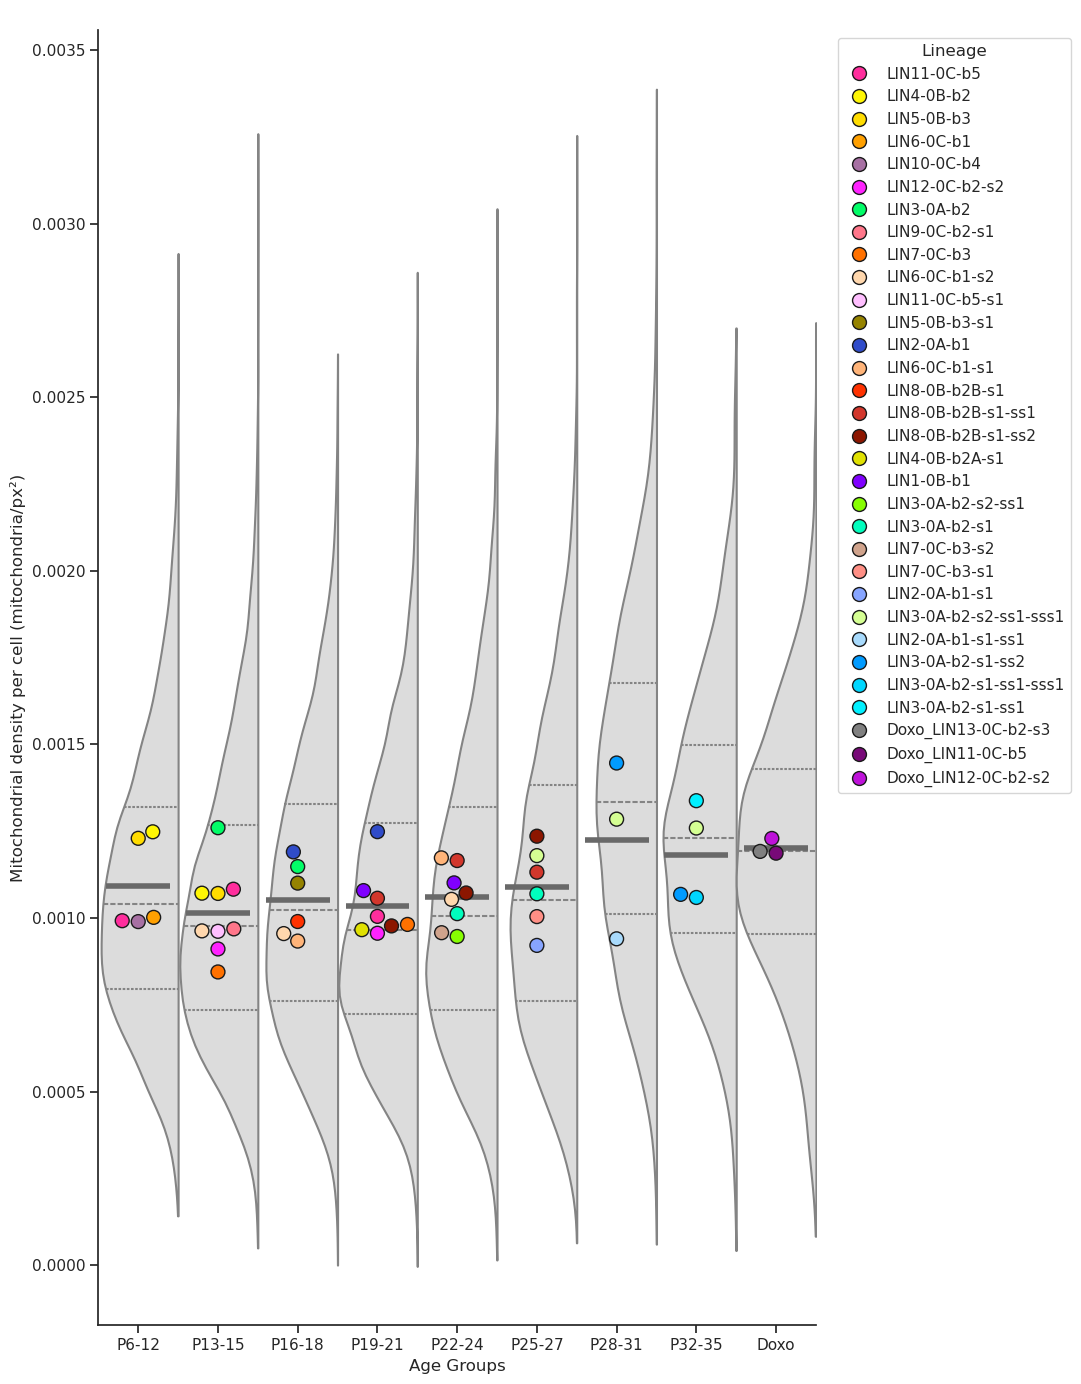

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.164    0.342  0.178

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


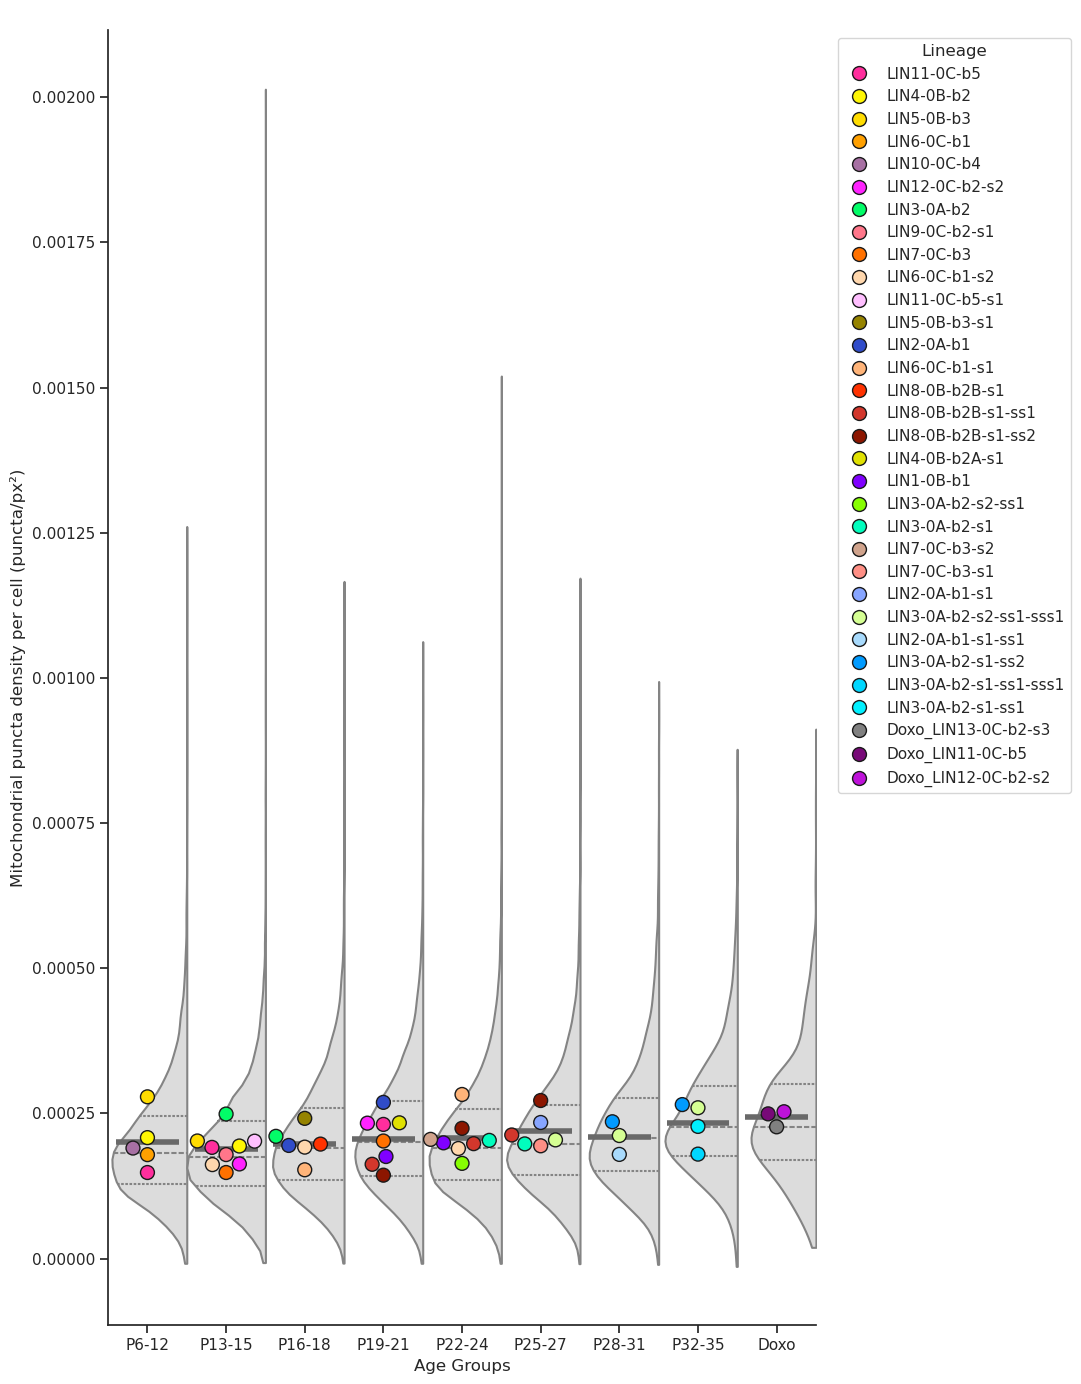

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.212    0.315  0.184

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


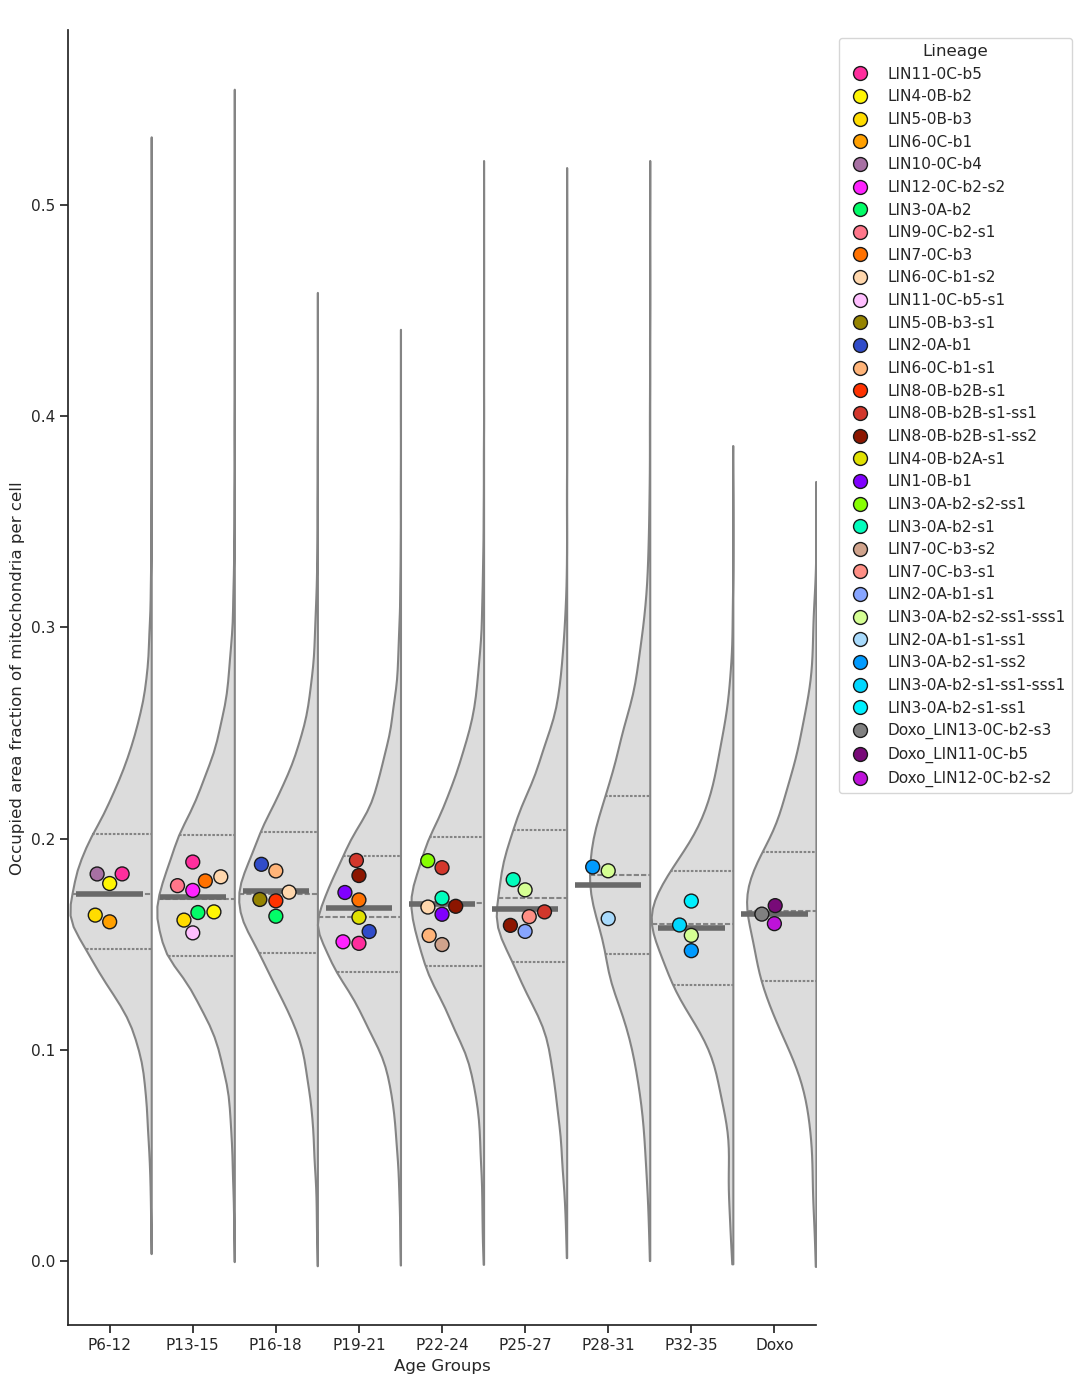

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



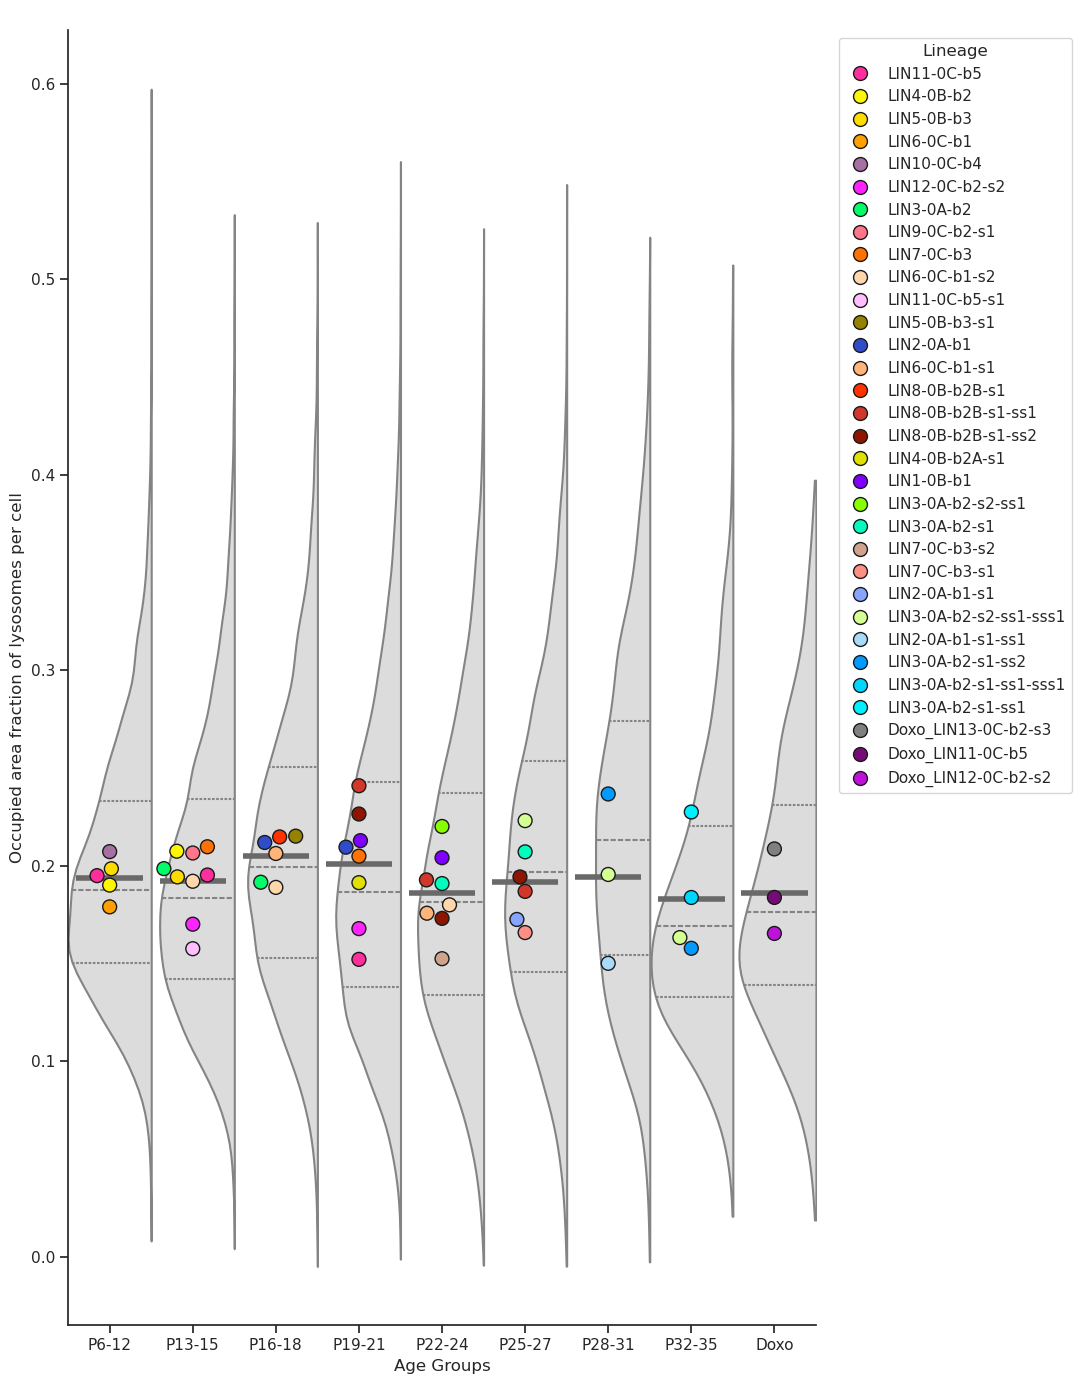

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.954    0.483  0.151

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


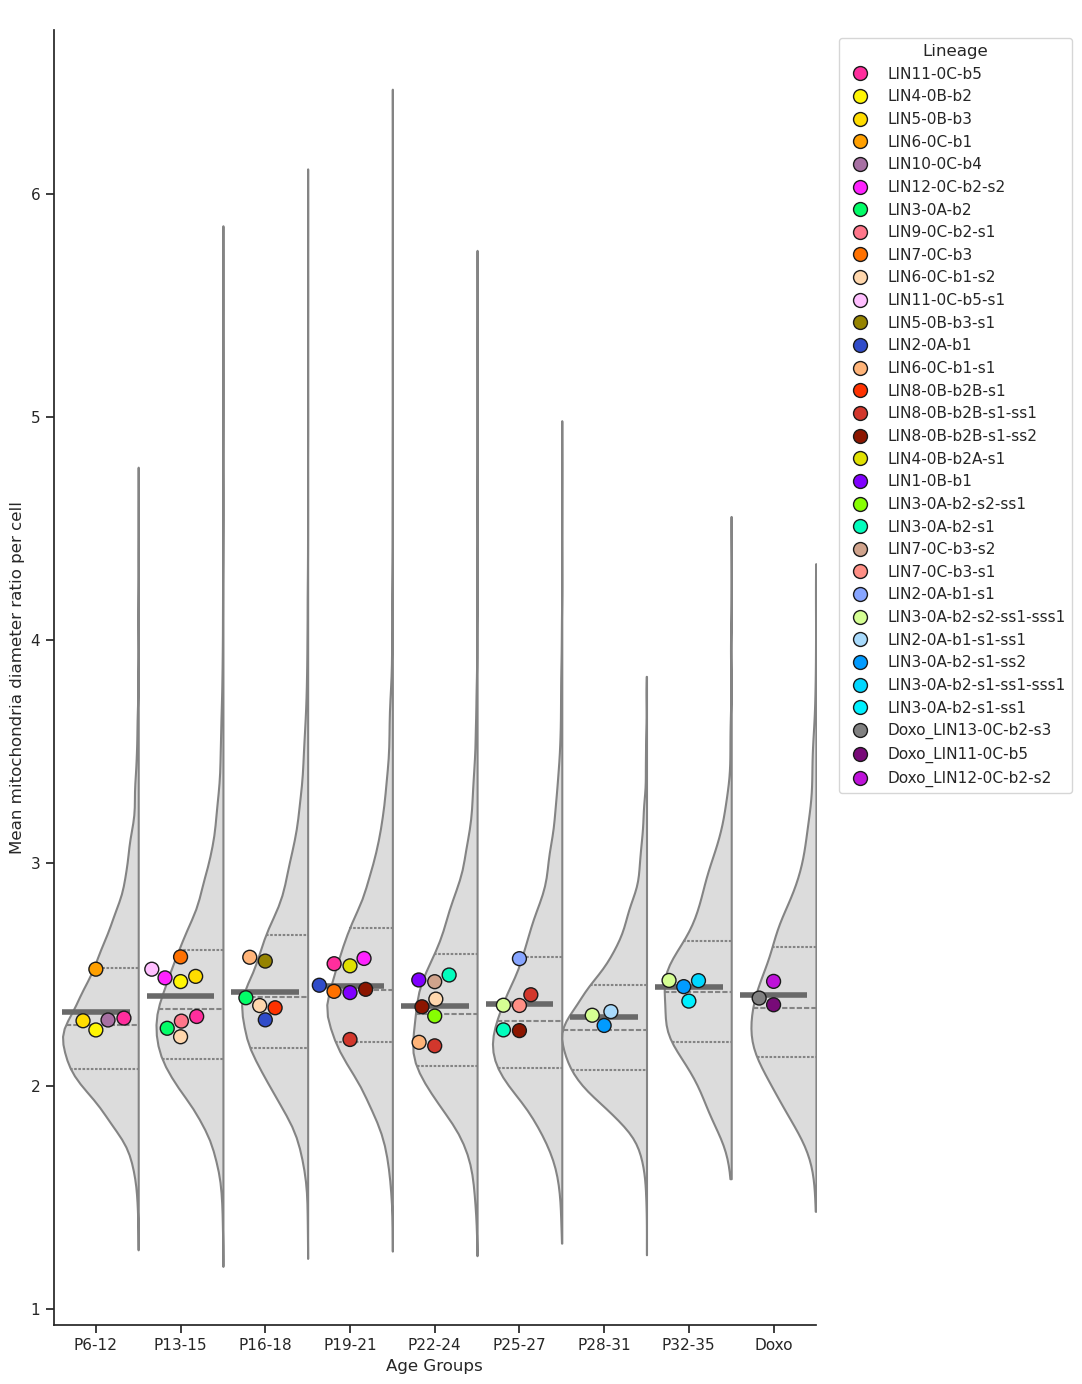

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.911    0.083  0.262

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


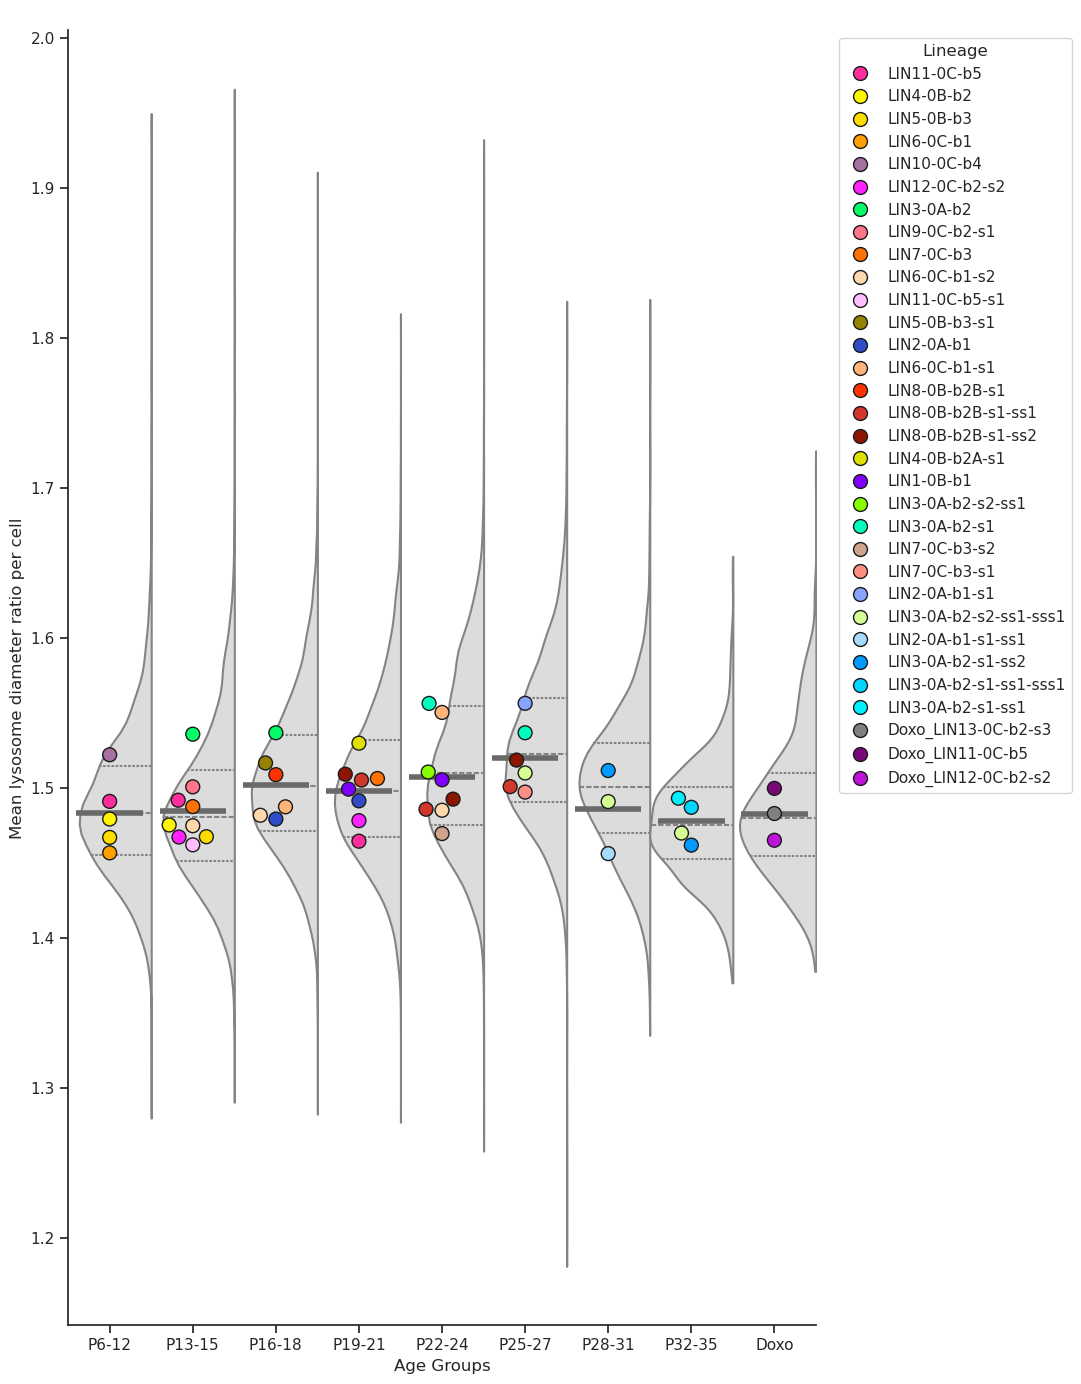

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  5.010    0.000  0.482


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      0.001      0.002  -0.001  0.000  -4.268      0.003    -2.657
Doxo    P16-18      0.001      0.002  -0.001  0.000  -3.634      0.019    -2.768
Doxo    P19-21      0.001      0.002  -0.000  0.000  -3.442      0.032    -2.242
Doxo    P22-24      0.001      0.002  -0.000  0.000  -2.786      0.150    -1.862
Doxo    P25-27      0.001      0.002  -0.000  0.000  -2.388      0.316    -1.415
Doxo    P28-31      0.001      0.002  -0.000  0.000  -2.747      0.162    -1.888
Doxo    P32-35      0.001      0.001  -0.000  0.000  -0.107      1.000    -0.120
Doxo    P6-12       0.001      0.002  -0.001  0.000  -3.856      0.010    -2.304
P13

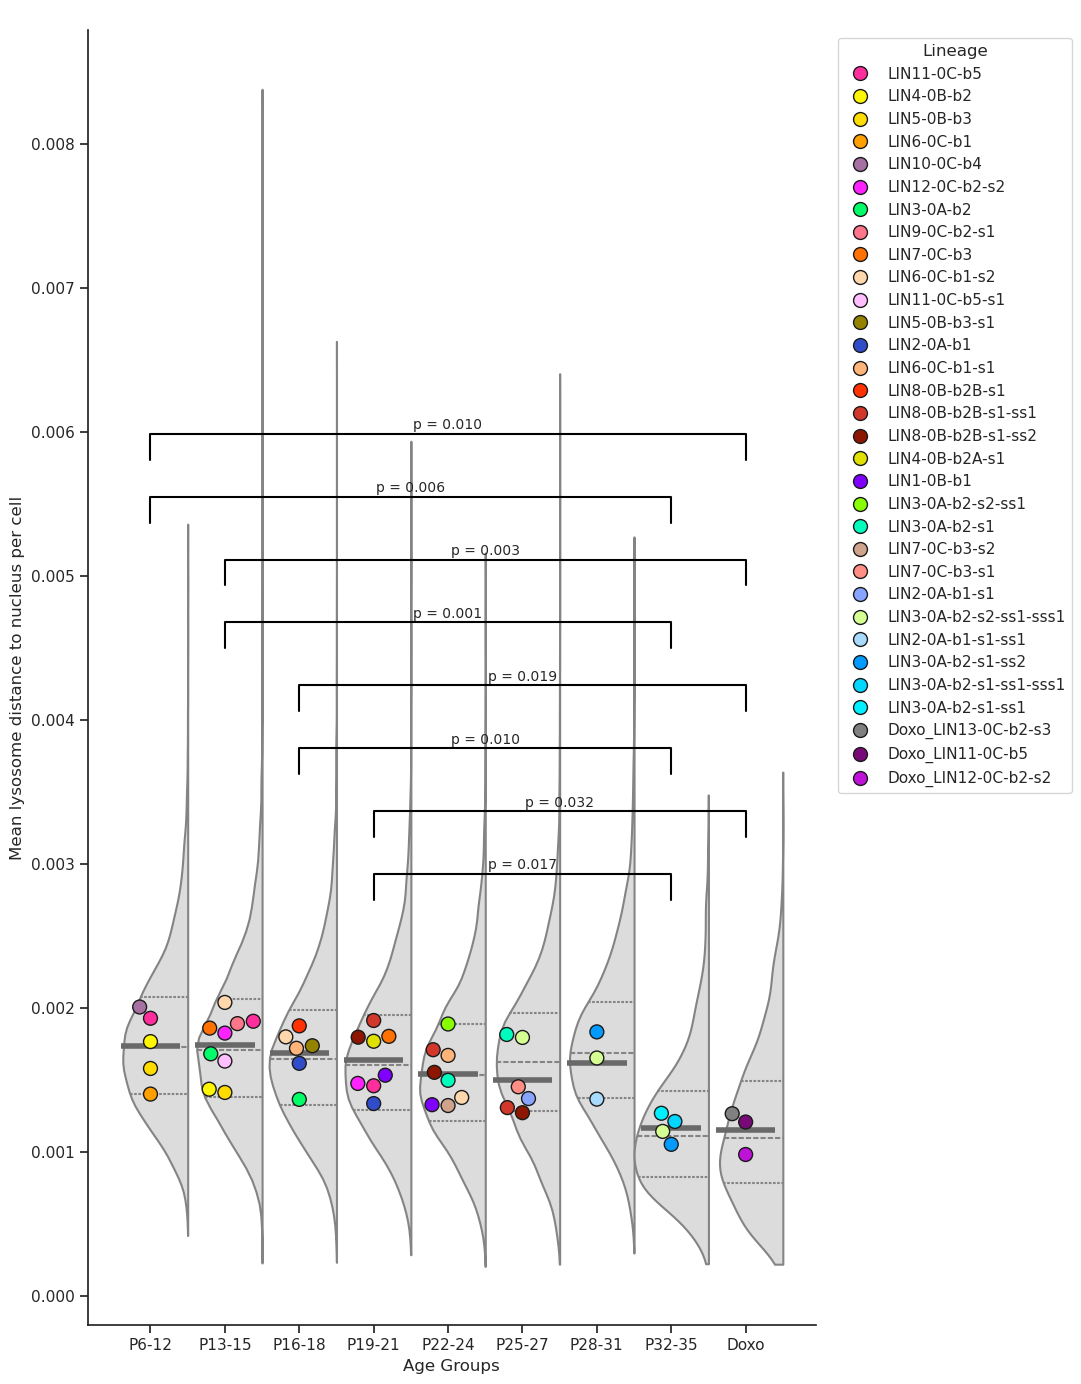

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  0.991    0.456  0.156

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


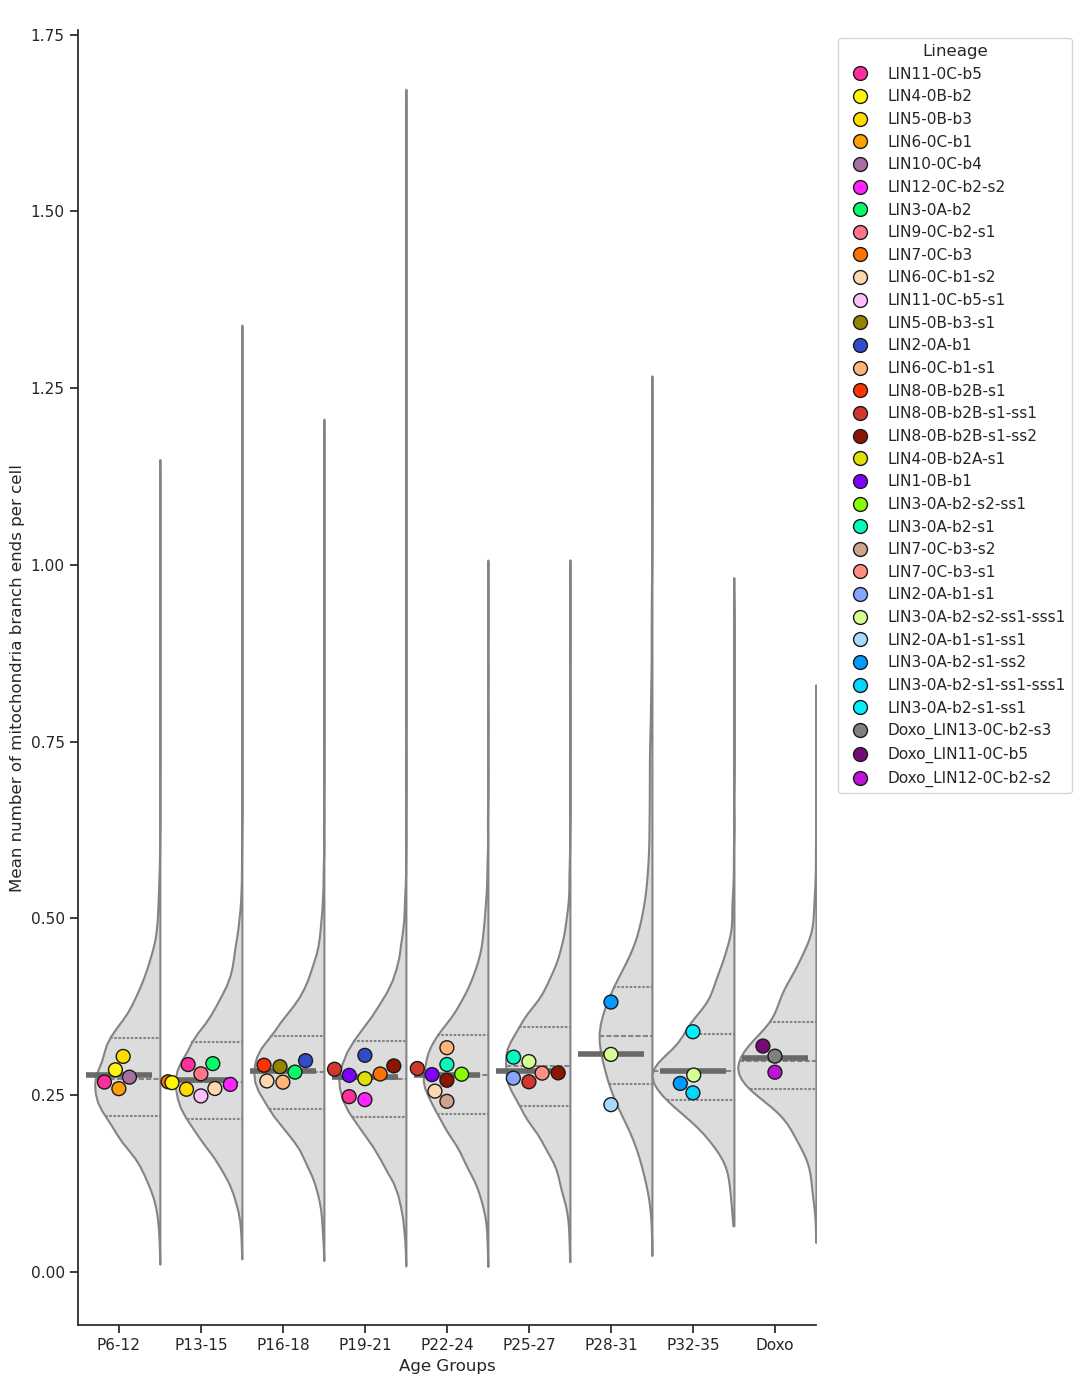

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.906    0.084  0.262

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


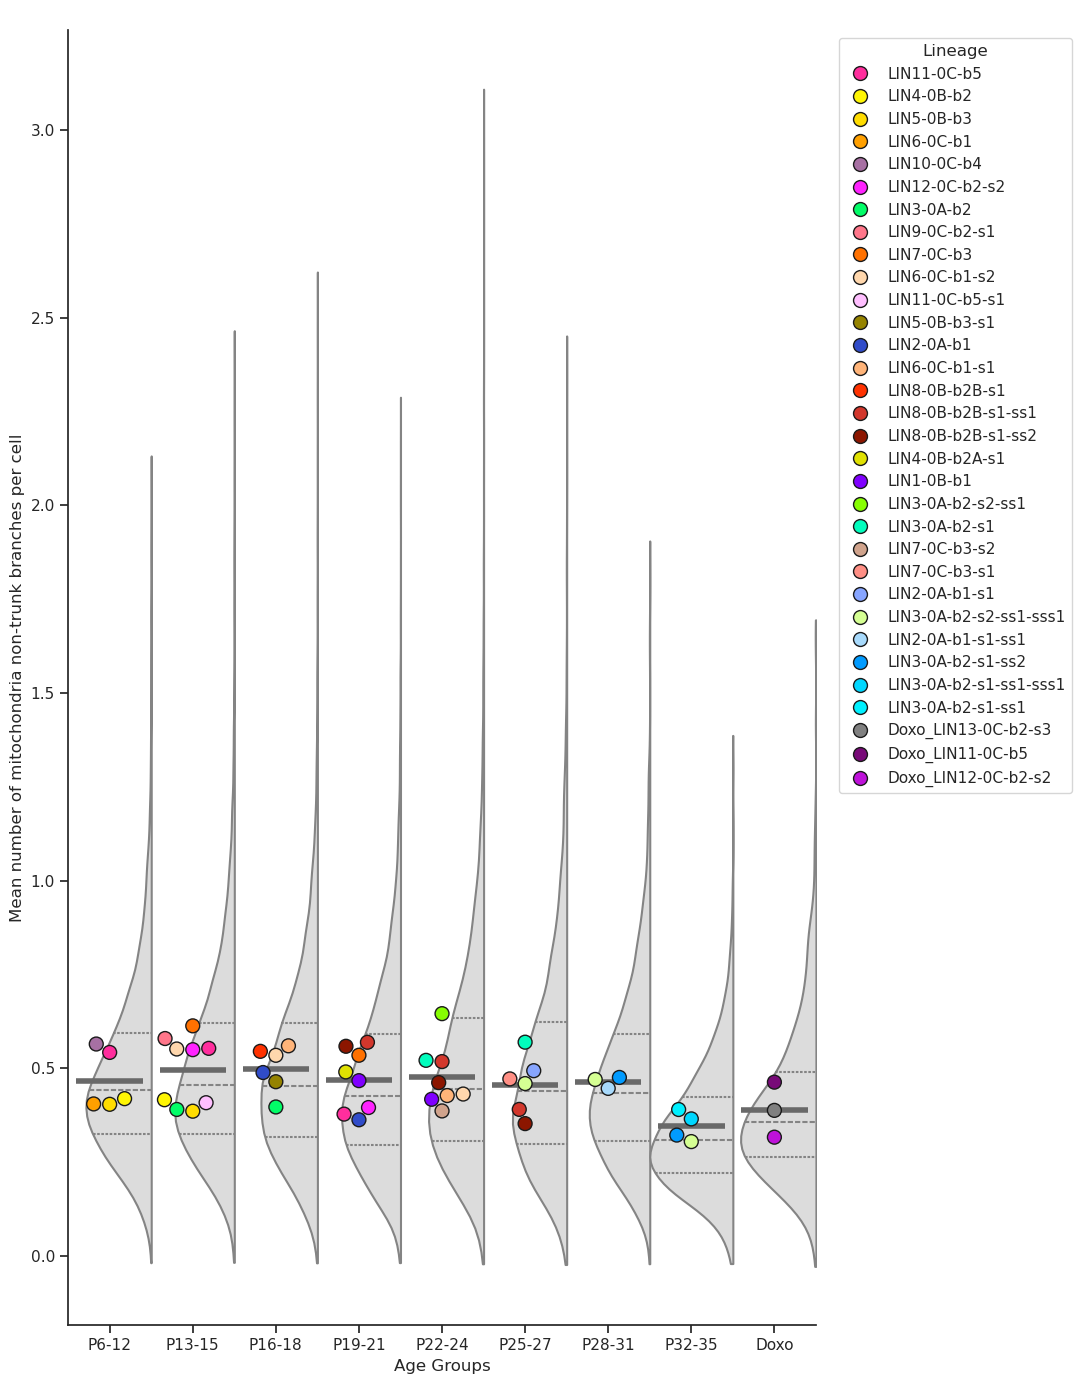

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/


ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.051    0.415  0.164

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


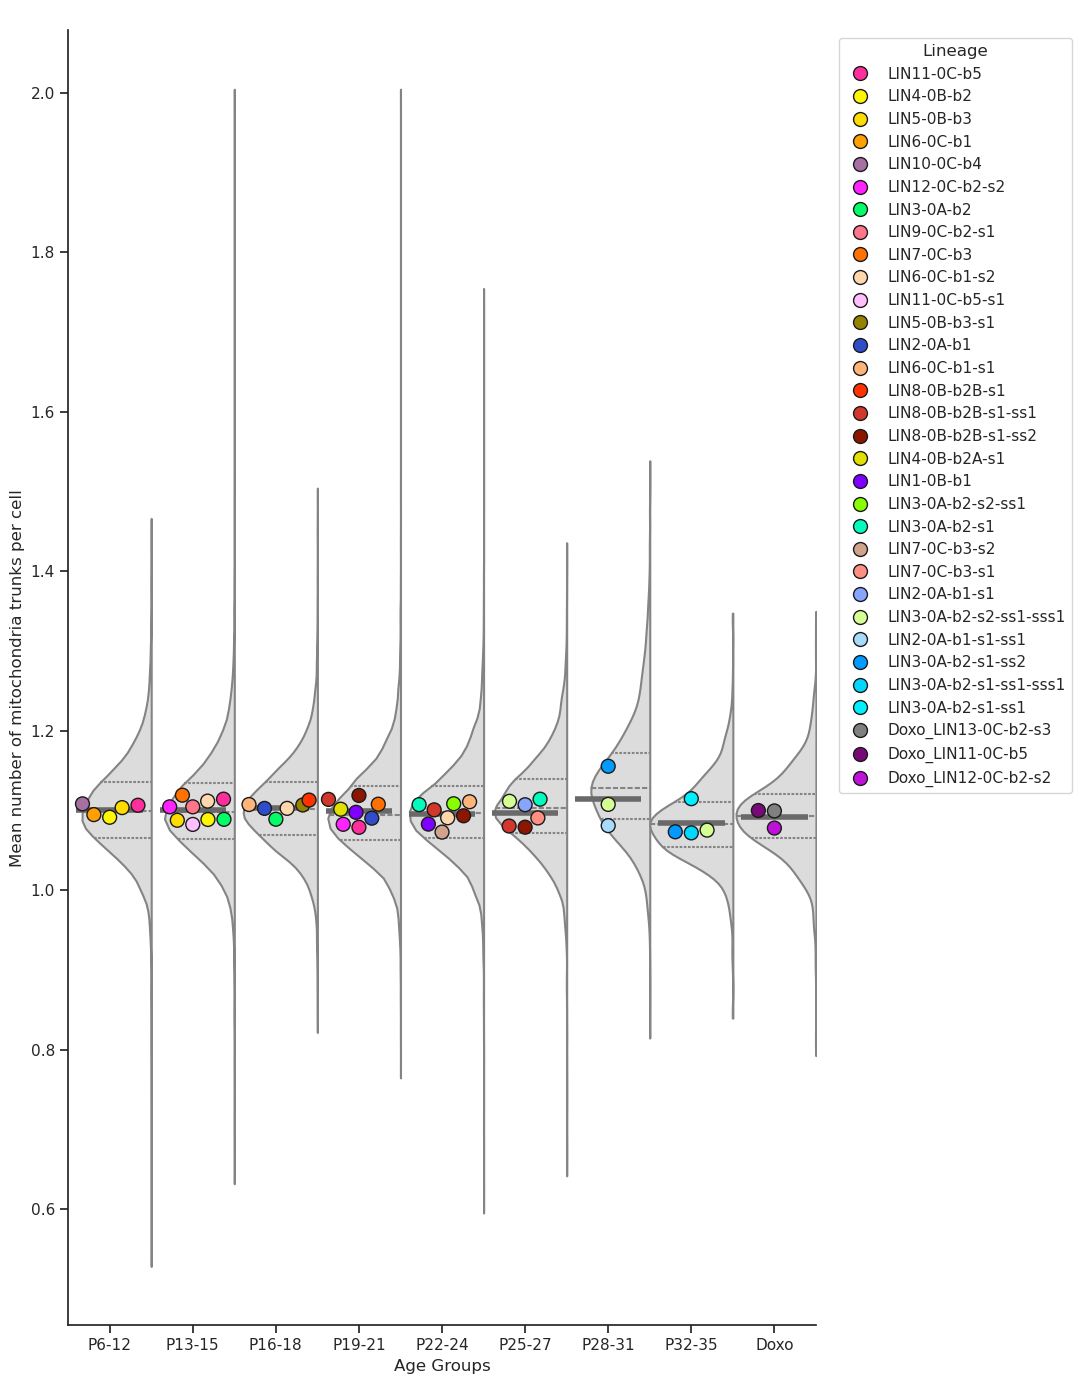

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  2.240    0.043  0.294


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15     11.339     13.434  -2.095  0.880  -2.380      0.321    -1.238
Doxo    P16-18     11.339     13.544  -2.205  0.934  -2.362      0.330    -1.672
Doxo    P19-21     11.339     13.278  -1.939  0.894  -2.169      0.443    -1.712
Doxo    P22-24     11.339     12.746  -1.407  0.894  -1.573      0.813    -1.026
Doxo    P25-27     11.339     12.493  -1.154  0.934  -1.236      0.944    -0.772
Doxo    P28-31     11.339     11.957  -0.618  1.078  -0.573      1.000    -0.817
Doxo    P32-35     11.339     10.973   0.366  1.009   0.363      1.000     0.539
Doxo    P6-12      11.339     12.578  -1.239  0.964  -1.285      0.930    -0.871
P13

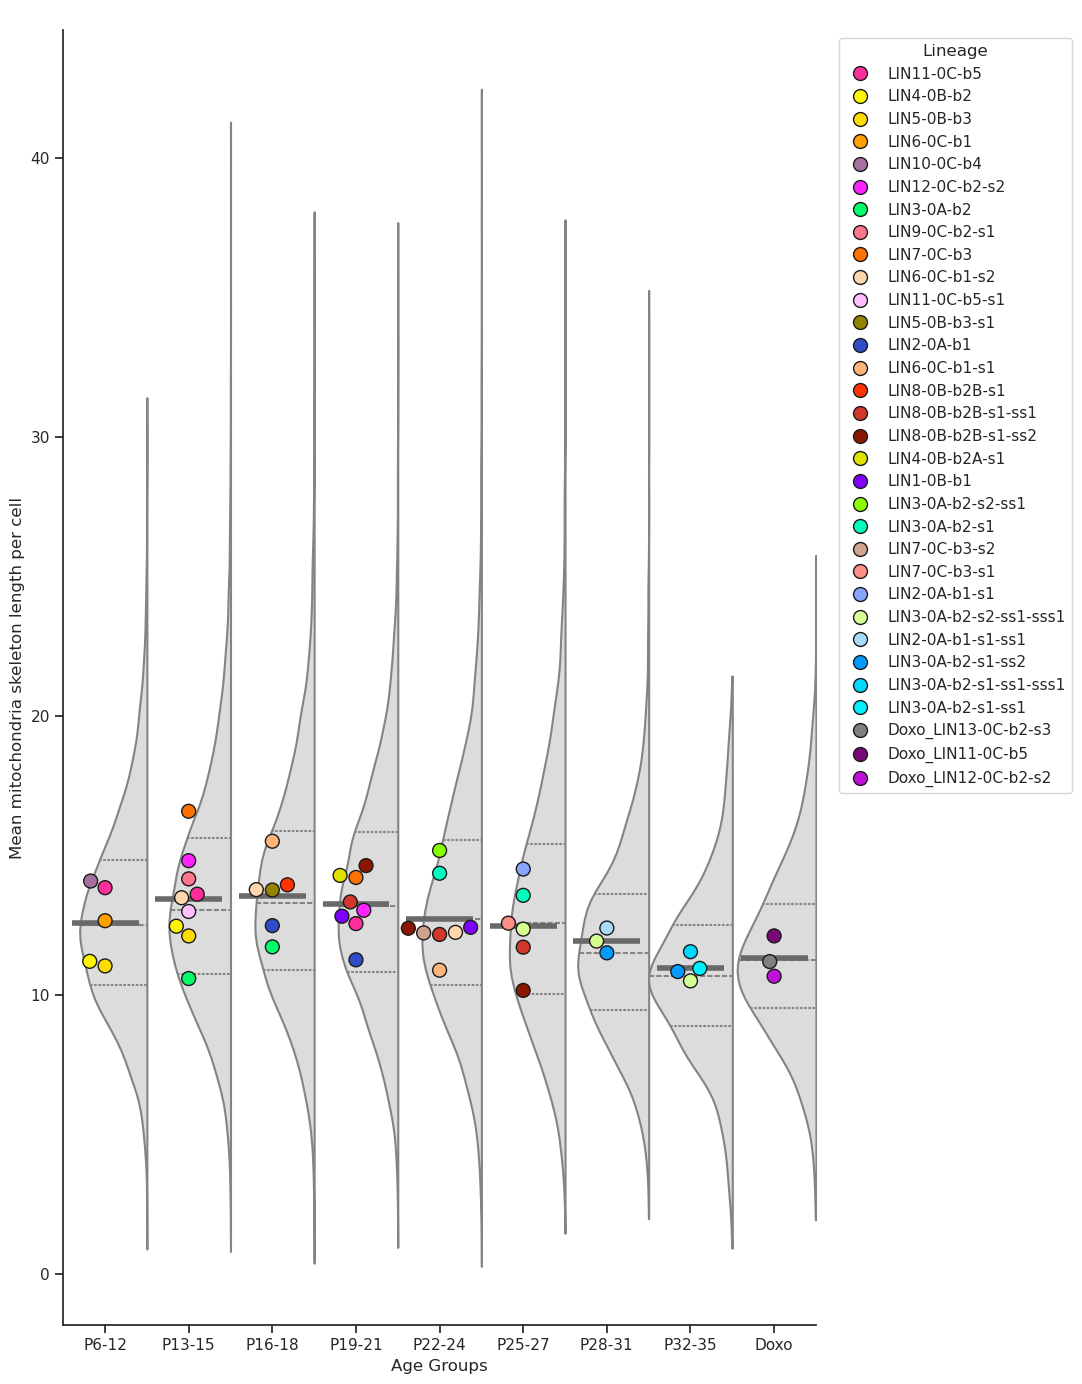

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.223    0.309  0.185

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


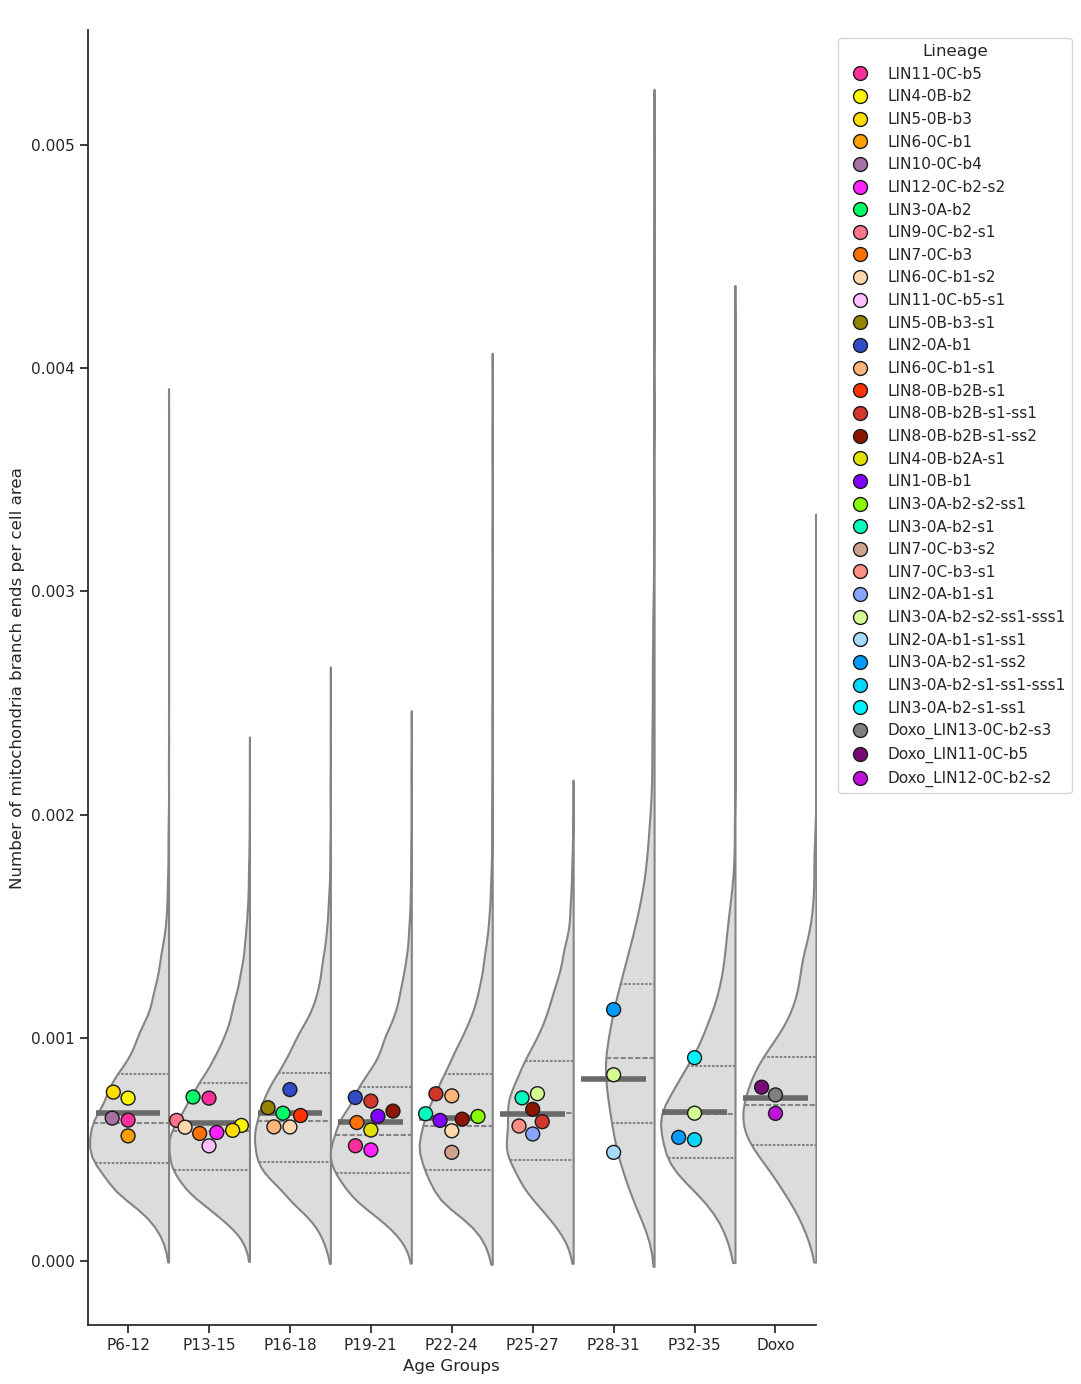

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  1.245    0.297  0.188

ANOVA test is not significant, skipping Tukey's post-hoc test.
No significant pairs found for the tukey_v3 test.


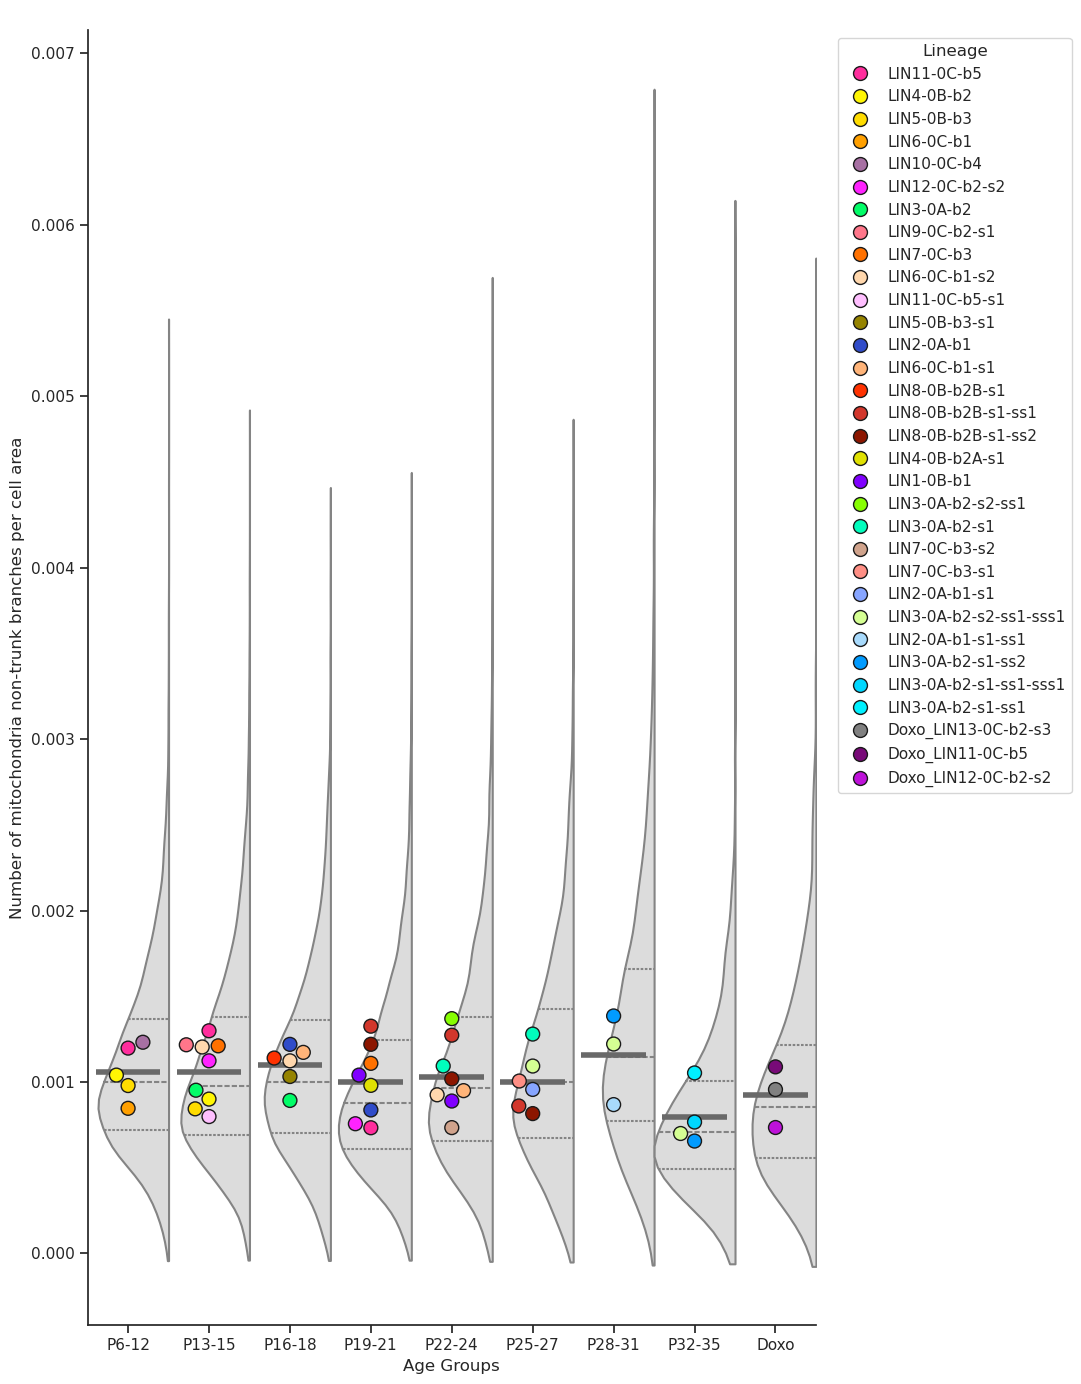

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



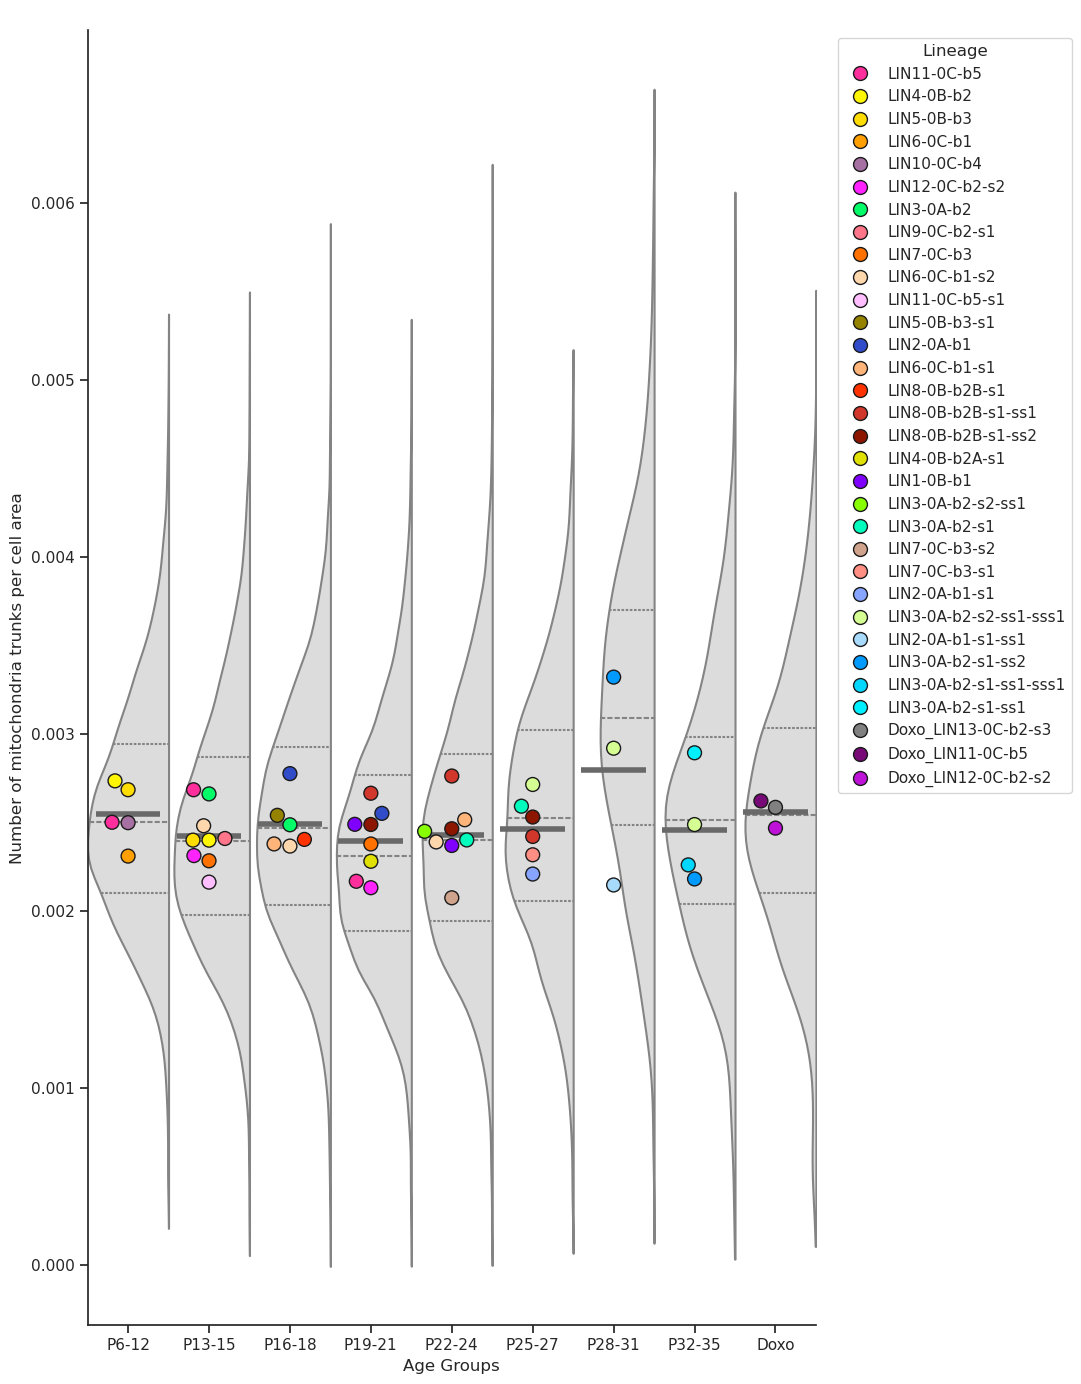

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



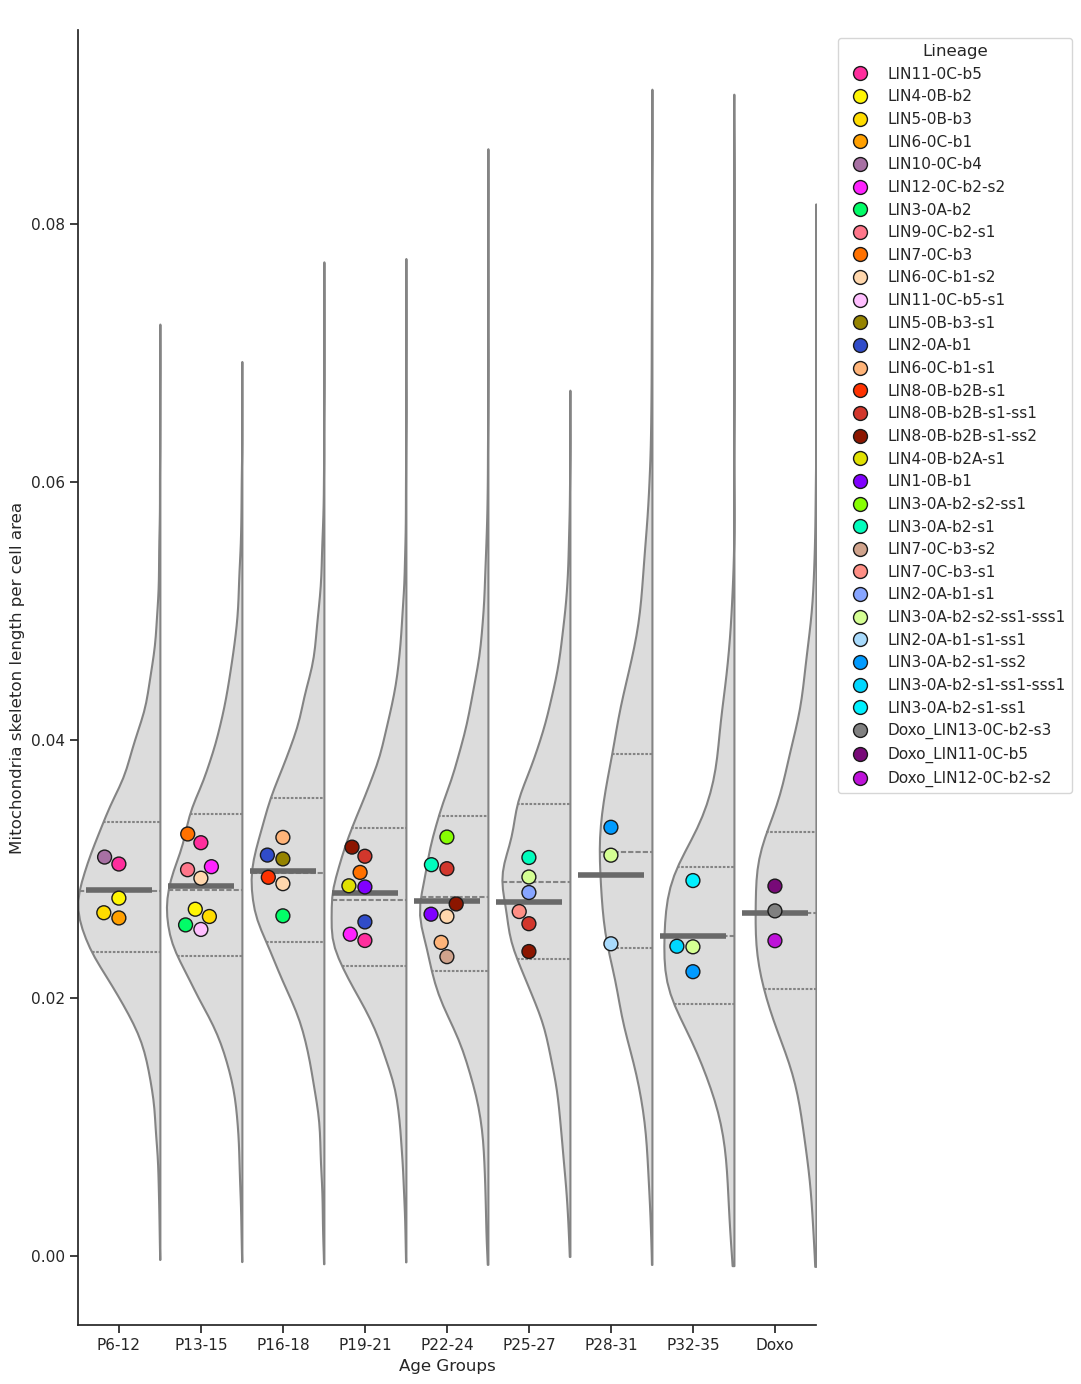

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  4.066    0.001  0.431


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      0.000      0.000  -0.000  0.000  -3.396      0.036    -2.023
Doxo    P16-18      0.000      0.000  -0.000  0.000  -3.155      0.065    -2.580
Doxo    P19-21      0.000      0.000  -0.000  0.000  -2.624      0.207    -1.521
Doxo    P22-24      0.000      0.000  -0.000  0.000  -2.493      0.264    -1.435
Doxo    P25-27      0.000      0.000  -0.000  0.000  -1.985      0.562    -1.259
Doxo    P28-31      0.000      0.000  -0.000  0.000  -2.225      0.409    -1.690
Doxo    P32-35      0.000      0.000   0.000  0.000   0.471      1.000     0.455
Doxo    P6-12       0.000      0.000  -0.000  0.000  -3.168      0.063    -1.977
P13

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



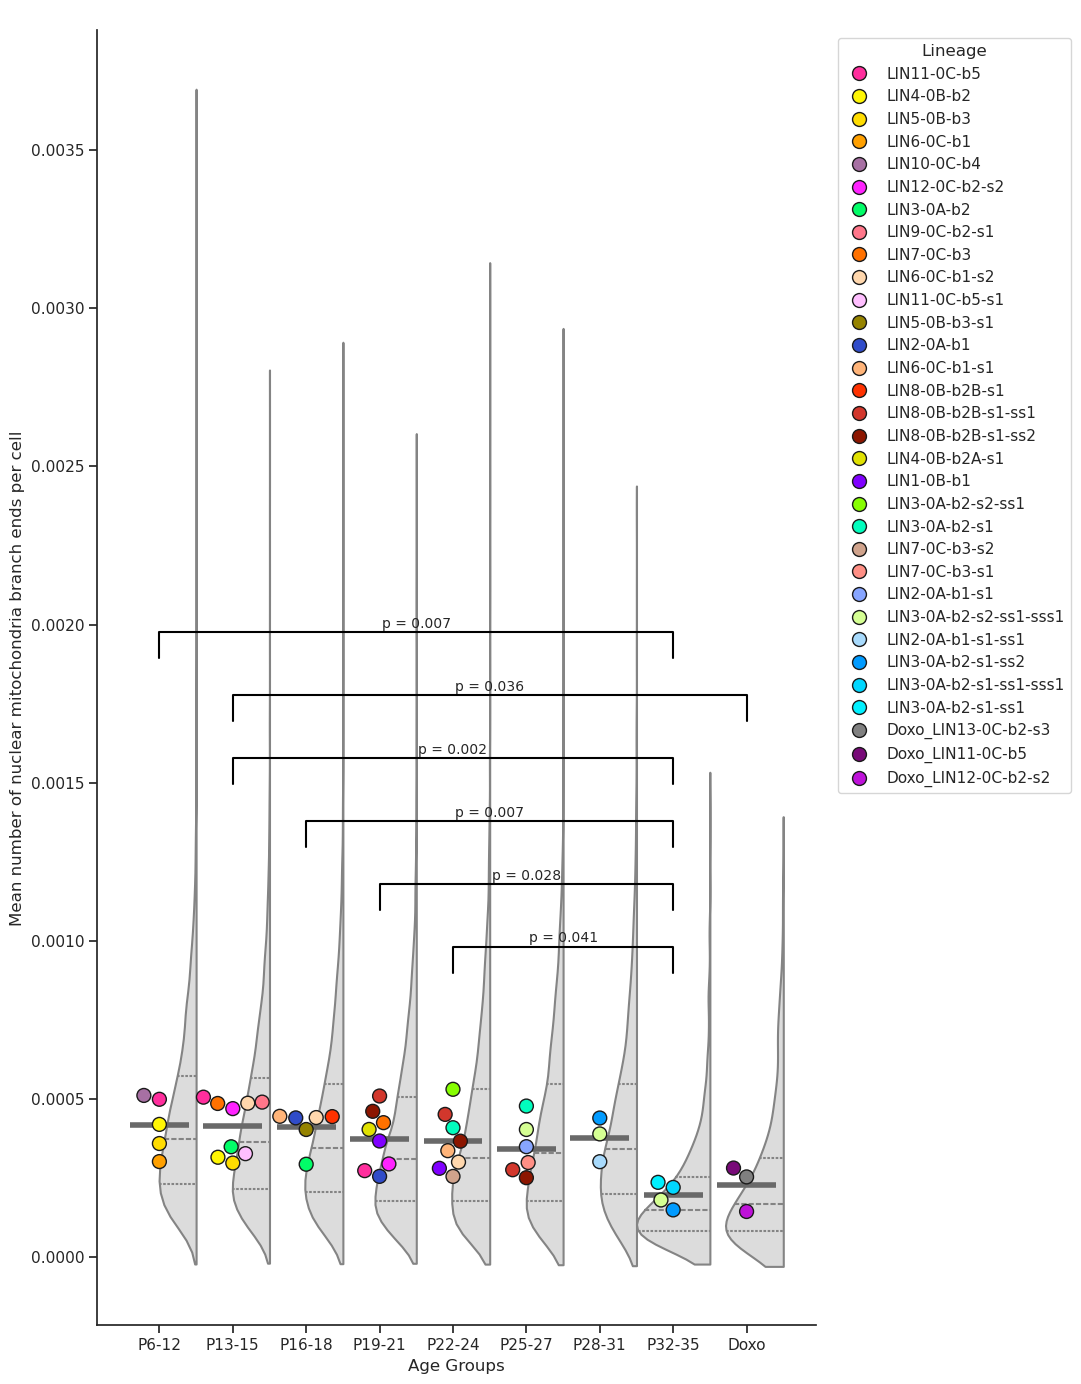

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  2.923    0.011  0.352


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      0.000      0.000  -0.000  0.000  -2.808      0.143    -1.582
Doxo    P16-18      0.000      0.000  -0.000  0.000  -2.713      0.173    -2.170
Doxo    P19-21      0.000      0.000  -0.000  0.000  -2.185      0.433    -1.310
Doxo    P22-24      0.000      0.000  -0.000  0.000  -2.330      0.348    -1.298
Doxo    P25-27      0.000      0.000  -0.000  0.000  -1.740      0.719    -1.172
Doxo    P28-31      0.000      0.000  -0.000  0.000  -1.786      0.691    -1.727
Doxo    P32-35      0.000      0.000   0.000  0.000   0.523      1.000     0.555
Doxo    P6-12       0.000      0.000  -0.000  0.000  -2.338      0.343    -1.471
P13

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



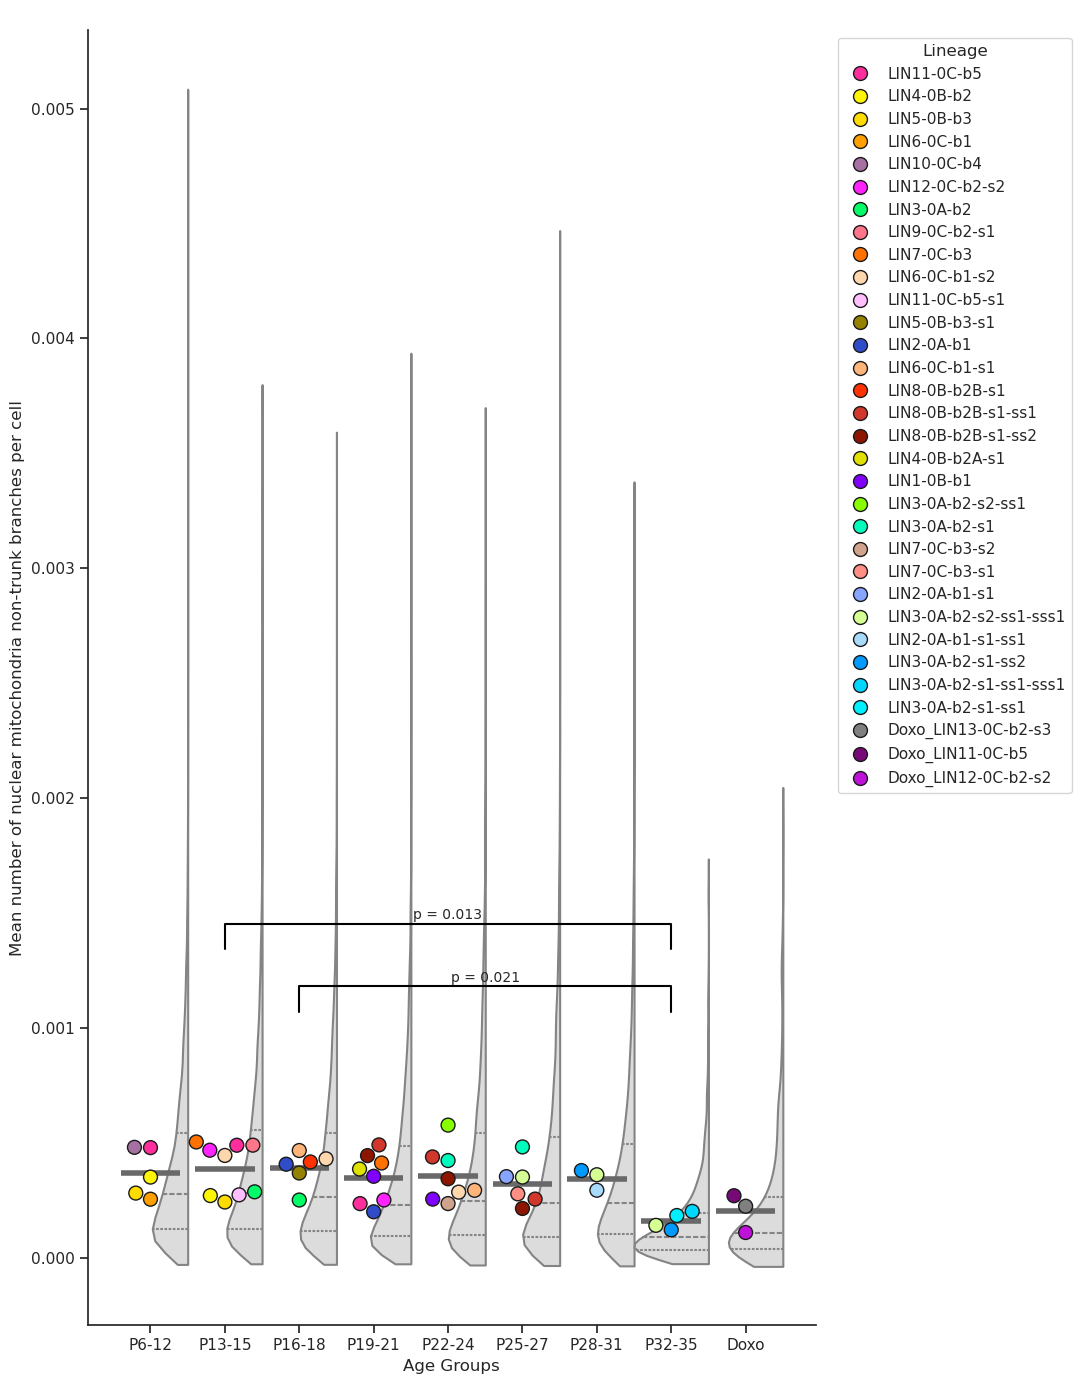

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  4.751    0.000  0.469


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      0.000      0.000  -0.000  0.000  -3.894      0.009    -2.406
Doxo    P16-18      0.000      0.000  -0.000  0.000  -3.252      0.052    -2.877
Doxo    P19-21      0.000      0.000  -0.000  0.000  -2.901      0.117    -1.782
Doxo    P22-24      0.000      0.000  -0.000  0.000  -2.448      0.285    -1.529
Doxo    P25-27      0.000      0.000  -0.000  0.000  -1.949      0.585    -1.253
Doxo    P28-31      0.000      0.000  -0.000  0.000  -2.366      0.328    -1.927
Doxo    P32-35      0.000      0.000   0.000  0.000   0.181      1.000     0.209
Doxo    P6-12       0.000      0.000  -0.000  0.000  -3.773      0.013    -2.247
P13

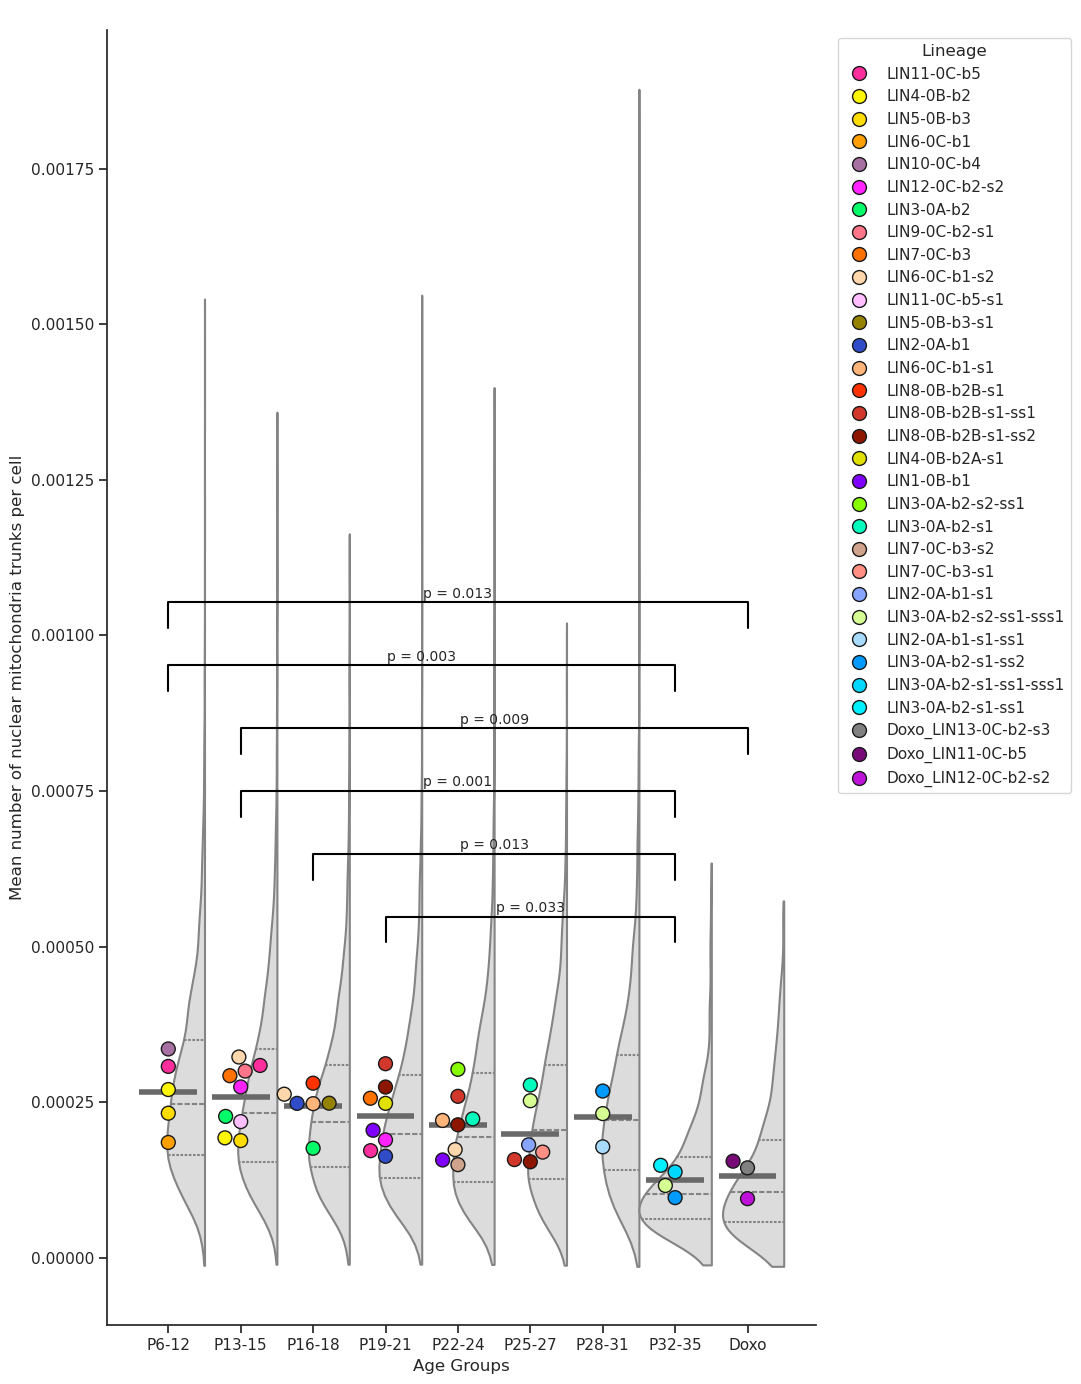

[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24'), ('P13-15', 'P25-27'), ('P13-15', 'P28-31'), ('P13-15', 'P32-35'), ('P13-15', 'Doxo'), ('P16-18', 'P19-21'), ('P16-18', 'P22-24'), ('P16-18', 'P25-27'), ('P16-18', 'P28-31'), ('P16-18', 'P32-35'), ('P16-18', 'Doxo'), ('P19-21', 'P22-24'), ('P19-21', 'P25-27'), ('P19-21', 'P28-31'), ('P19-21', 'P32-35'), ('P19-21', 'Doxo'), ('P22-24', 'P25-27'), ('P22-24', 'P28-31'), ('P22-24', 'P32-35'), ('P22-24', 'Doxo'), ('P25-27', 'P28-31'), ('P25-27', 'P32-35'), ('P25-27', 'Doxo'), ('P28-31', 'P32-35'), ('P28-31', 'Doxo'), ('P32-35', 'Doxo')]
[('P6-12', 'P13-15'), ('P6-12', 'P16-18'), ('P6-12', 'P19-21'), ('P6-12', 'P22-24'), ('P6-12', 'P25-27'), ('P6-12', 'P28-31'), ('P6-12', 'P32-35'), ('P6-12', 'Doxo'), ('P13-15', 'P16-18'), ('P13-15', 'P19-21'), ('P13-15', 'P22-24')

/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/mitolyso_plot_functions.py:290: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior




ANOVA SUMMARY

Source       ddof1    ddof2      F    p-unc    np2
---------  -------  -------  -----  -------  -----
AllGroups        8       43  3.906    0.002  0.421


POST HOC TESTS

A       B         mean(A)    mean(B)    diff     se       T    p-tukey    hedges
------  ------  ---------  ---------  ------  -----  ------  ---------  --------
Doxo    P13-15      0.004      0.008  -0.004  0.001  -3.434      0.033    -1.926
Doxo    P16-18      0.004      0.009  -0.004  0.001  -3.264      0.050    -2.472
Doxo    P19-21      0.004      0.008  -0.003  0.001  -2.768      0.155    -1.729
Doxo    P22-24      0.004      0.007  -0.003  0.001  -2.594      0.219    -1.496
Doxo    P25-27      0.004      0.007  -0.003  0.001  -1.988      0.560    -1.331
Doxo    P28-31      0.004      0.007  -0.003  0.002  -1.875      0.634    -2.035
Doxo    P32-35      0.004      0.004   0.001  0.001   0.379      1.000     0.425
Doxo    P6-12       0.004      0.008  -0.004  0.001  -2.830      0.136    -1.758
P13

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



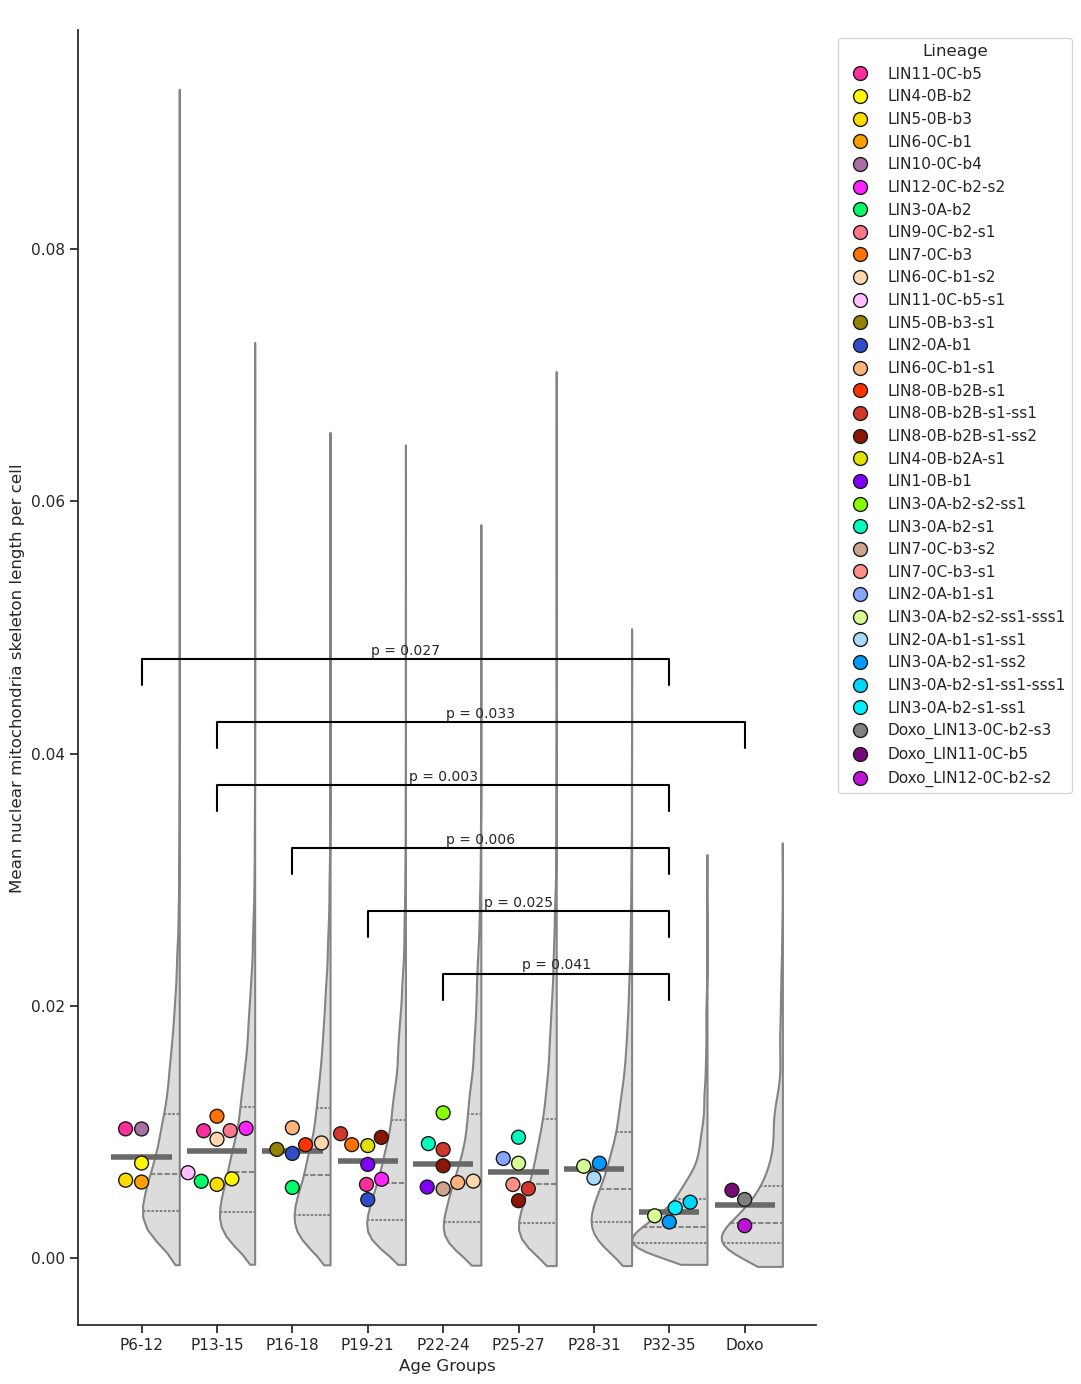

In [92]:
#prep these for the presentation
features_for_presentation = [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Mean_Mitochondria_AreaShape_Area",
    "Mean_Mitochondria_AreaShape_Perimeter",
    "Mean_Mitochondria_AreaShape_Solidity",
    "Mean_Mitochondria_AreaShape_Extent",
    "Mean_Mitochondria_Puncta_AreaShape_Area",
    "Mean_Mitochondria_Puncta_AreaShape_Perimeter",
    "Mean_Mitochondria_Puncta_AreaShape_Solidity",
    "Mean_Mitochondria_Puncta_AreaShape_Extent",
    # "Mean_Mitochondria_AreaShape_FormFactor",
    "Mean_Lysosomes_AreaShape_Area",
    "Mean_Lysosomes_AreaShape_Perimeter",
    "Mean_Lysosomes_AreaShape_Solidity",
    "Mean_Lysosomes_AreaShape_Extent",
    "Density_Children_Lysosomes_Count_PerCell_Area",
    "Density_Children_Mitochondria_Count_PerCell_Area",
    "Density_Children_Mitochondria_Puncta_Count_PerCell_Area",
    "OccupiedAreaFraction_Mitochondria_PerCell_Area",
    "OccupiedAreaFraction_Lysosomes_PerCell_Area",
    "Mean_Mitochondria_MaxMinFeret_DiameterRatio_PerCell",
    "Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell",
    "Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area",
    "Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton",
    "Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn",
    "Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton",
    "Mean_MitoEnds_ObjectSkeleton_TotalObjectSkeltnLngth_MtSkltn",
    "MitoEnds_NumberBranchEnds_PerCell_Area",
    "MitoEnds_NumberNonTrunkBranches_PerCell_Area",
    "MitoEnds_NumberTrunks_PerCell_Area",
    "MitoEnds_TotalObjectSkeltnLngth_PerCell_Area",
    "Nuclei_ObjectSkeleton_NumberBranchEnds_PerCell_Area",
    "Nuclei_ObjectSkeleton_NumberNonTrunkBranches_PerCell_Area",
    "Nuclei_ObjectSkeleton_NumberTrunks_PerCell_Area",
    "Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_PerCell_Area",
]
feature_names = [
    "Cell size (px\u00b2)",
    "Nucleus size (px\u00b2)",
    "Cell-to-nucleus area ratio",
    "Mean mitochondrial size per cell (px\u00b2)",
    "Mean mitochondrial perimeter per cell",
    "Mean mitochondria roundness (solidity)",
    "Mean Mitochondria extent",
    "Mean mitochondrial puncta size per cell (px\u00b2)",
    "Mean mitochondrial puncta perimeter per cell",
    "Mean mitochondrial puncta roundness (solidity)",
    "Mean Mitochondria Puncta extent",
    # "Mean_Mitochondria_AreaShape_FormFactor",
    "Mean lysosomal size per cell (px\u00b2)",
    "Mean lysosomal perimeter per cell",
    "Mean lysosomal roundness (solidity)",
    "Mean lysosomal extent",
    "Lysosomal density per cell (lysosomes/px\u00b2)",
    "Mitochondrial density per cell (mitochondria/px\u00b2)",
    "Mitochondrial puncta density per cell (puncta/px\u00b2)",
    "Occupied area fraction of mitochondria per cell",
    "Occupied area fraction of lysosomes per cell",
    "Mean mitochondria diameter ratio per cell",
    "Mean lysosome diameter ratio per cell",
    "Mean lysosome distance to nucleus per cell",
    "Mean number of mitochondria branch ends per cell",
    "Mean number of mitochondria non-trunk branches per cell",
    "Mean number of mitochondria trunks per cell",
    "Mean mitochondria skeleton length per cell",
    "Number of mitochondria branch ends per cell area",
    "Number of mitochondria non-trunk branches per cell area",
    "Number of mitochondria trunks per cell area",
    "Mitochondria skeleton length per cell area",
    "Mean number of nuclear mitochondria branch ends per cell",
    "Mean number of nuclear mitochondria non-trunk branches per cell",
    "Mean number of nuclear mitochondria trunks per cell",
    "Mean nuclear mitochondria skeleton length per cell",
]
analysis_mode = "Lineages"
norm = False
if norm:
    data_df = norm_cell_df_mitolyso.copy()
else:
    this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
    data_df = this_df[this_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
    plot_dir = "plots/notnorm" 
    
if analysis_mode == "Lineages":
    stat_grouping = "Lineage"
    plot_dir = "plots/lineages"
    
    #Temp
    no_drug_values = {None,"", "None", "none", "NoDrug", "Control", "control"}
    drug_clean = data_df["Drug"].astype(str).str.strip()
    data_df["Lineage"] = data_df["Lineage"].where(
        data_df["Drug"].isna() | drug_clean.isin(no_drug_values),
        drug_clean + "_" + data_df["Lineage"].astype(str),
    )
    data_df["Lineage"] = data_df["Lineage"].replace("LIN3-0A-b2-s2-ss1-ss1","LIN3-0A-b2-s2-ss1-sss1")
    
    #then get the correct colours
    colour_dict = get_hard_code_lineage_colours(data_df)
elif analysis_mode == "Plates":
    stat_grouping = "Plate_Number"
    colour_dict = get_hard_code_plate_colours(data_df)

pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude=[]

os.makedirs(plot_dir, exist_ok=True)
figsize = (11, 14)
truncate_outliers=True
rm_outliers_method = "gesd_2"
test="tukey_v3"
pairs = getpairs(combined_cell_df_mitolyso, group, order)

for i,feature in enumerate(features_for_presentation):
    order = get_all_group_order()
    
    ylabel = feature_names[i]
    xlabel = "Age Groups"
    group = "AllGroups"
    
    single_feature_super_splitviolinplot(
        data_df,
        x_value=group,
        y_value=feature,
        plate_col_name=stat_grouping,
        xtitle=xlabel,
        ytitle=ylabel,
        out_dir=plot_dir,
        annotate=True,
        order=order,
        test=test,
        reps_to_exclude=reps_to_exclude,
        show_hist=False,  # True,
        remove_outliers=remove_outliers,
        rm_outliers_method=rm_outliers_method,
        truncate_outliers=truncate_outliers,
        legend=True,
        context="talk",
        figsize=figsize,
        pallete=pallete,
        p_correction="fdr_bh",
        shapiro=False
        # truncate_outliers=True
    )
#Make the one without annoations
    # single_feature_super_splitviolinplot(
    #     data_df,
    #     x_value=group,
    #     y_value=feature,
    #     plate_col_name="Plate_Number",
    #     xtitle=xlabel,
    #     ytitle=ylabel,
    #     out_dir=plot_dir,
    #     annotate=False,
    #     order=order,
    #     test="None",
    #     reps_to_exclude=reps_to_exclude,
    #     show_hist=False,
    #     remove_outliers=remove_outliers,
    #     rm_outliers_method=rm_outliers_method,
    #     legend=False,
    #     context="talk",
    #     figsize=figsize,
    #     truncate_outliers=True,
    #     norm=norm,
    # )


In [93]:
def make_a_shitton_of_plots(
    order = [],
    xlabel = "Age Groups",
    group = "AllGroups",
    pairs = getpairs(combined_cell_df_mitolyso, group, order),
    pallete = "pastel",
    remove_outliers = False,
    truncate_outliers = False,
    reps_to_exclude=[],
    norm = False
):
    if not order:
        order = get_all_group_order()
        
        
        
        
        
        
        
    if norm:
        this_df = norm_cell_df_mitolyso.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/norm"
        )
    else:
        this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/notnorm"
        )
    os.makedirs(big_out_folder, exist_ok=True)
    #iterate and make big ball of plots
    for compartment, feature_dict in zip(feature_names, feature_dicts):
        feature_folder = Path(big_out_folder, compartment)
        Path.mkdir(feature_folder, exist_ok=True)
        for feature_type, features in feature_dict.items():
            newfolder = Path(feature_folder,feature_type)
            Path.mkdir(newfolder, exist_ok=True)
            for feature in features:
                single_feature_super_splitviolinplot(
                    this_df,
                    x_value=group,
                    y_value=feature,
                    plate_col_name="Plate_Number",
                    xtitle=xlabel,
                    ytitle=None,
                    out_dir=newfolder,
                    annotate=True,
                    order=order,
                    test="conover",
                    reps_to_exclude=reps_to_exclude,
                    show_hist=False,
                    remove_outliers=remove_outliers,
                    #truncate_outliers=truncate_outliers,
                    show=False,
                    legend=True,
                    context = "talk",
                    figsize = (12,8)
                )
# make_a_shitton_of_plots(reps_to_exclude=[],norm=False)
# make_a_shitton_of_plots(reps_to_exclude=[], norm=True)

## Attempting PCA

In [94]:
vars = cell_features["areashape"]
vars = vars + nuc_features["areashape"]
vars = vars+ mito_features["areashape"]
vars = vars + lyso_features["areashape"]
vars = vars + mito_features["texture"]
vars = vars + lyso_features["texture"]
vars = vars + mito_features["count"]
vars = vars + lyso_features["count"]
#vars = vars + mito_features["radialdistribution"]
vars = vars + mito_features["per_cell_area"]
vars = vars + lyso_features["per_cell_area"]
#var = vars + mito_features["granularity"]

# Stratified sampling by group
def stratified_sample(df, group_col, sample_size, random_state=40):
    """
    Take a stratified sample maintaining group proportions
    """
    # Calculate sampling fraction and sample from each group proportionally
    frac = sample_size / len(df)
    sample_df = df.groupby(group_col, group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=random_state), include_groups=True
    )
    return sample_df

sample_df = stratified_sample(this_df, "AllGroups", sample_size=10000)

/tmp/ipykernel_1186/109701810.py:21: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:

from sklearn.decomposition import PCA
n_components = 2
pca = PCA(n_components)

x_df = sample_df[vars.__add__
    (["AllGroups",
    "Plate_Number","AreaShape_Area"])].dropna()
display(x_df)
components = pca.fit_transform(x_df[vars])
display(components)

fig = px.scatter(components, x=0, y=1, color=x_df["AllGroups"],symbol=x_df["Plate_Number"])
total_var = pca.explained_variance_ratio_.sum() * 100

# labels = {str(i): f"PC {i + 1}" for i in range(n_components)}
# labels["color"] = "AllGroups"

# fig = px.scatter_matrix(
#     components,
#     color=x_df["AllGroups"],
#     dimensions=range(n_components),
#     labels=labels,
#     title=f"Total Explained Variance: {total_var:.2f}%",
# )
# fig.update_traces(diagonal_visible=False)
fig.show()

# labels = {
#     str(i): f"PC {i + 1} ({var:.1f}%)"
#     for i, var in enumerate(pca.explained_variance_ratio_ * 100)
# }

# fig = px.scatter_matrix(
#     components, labels=labels, dimensions=range(4), color=df["species"]
# )
# fig.update_traces(diagonal_visible=False)
# fig.show()


In [ ]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(x_df[vars])
reducer = UMAP(random_state=40)
reducer.fit(scaled_data)

embedding = reducer.transform(scaled_data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert np.all(embedding == reducer.embedding_)
print(embedding.shape)

import sklearn.cluster as cluster

import sklearn.metrics as metrics


In [ ]:

kmeans_labels = cluster.KMeans(n_clusters=9).fit_predict(scaled_data)

"""
From https://umap-learn.readthedocs.io/en/latest/clustering.html: 
The next thing to be aware of is that when using UMAP for dimension reduction you will want to select different parameters 
than if you were using it for visualization. First of all we will want a larger n_neighbors value 
small values will focus more on very local structure and are more prone to producing fine grained cluster structure 
that may be more a result of patterns of noise in the data than actual clusters. 
In this case well double it from the default 15 up to 30. Second it is beneficial to set min_dist to a very low value. 
Since we actually want to pack points together densely (density is what we want after all) a low value will help,
as well as making cleaner separations between clusters.
In this case we will simply set min_dist to be 0.
"""
clusterable_embedding = UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=40,
).fit_transform(scaled_data)

#now plot the embeddings
fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=kmeans_labels.astype(str),  # x_df["Plate_Number"],
    symbol=x_df["AllGroups"].astype(str),
    size=x_df["AreaShape_Area"],
    labels={"color": "kmeans"},
)
fig.show()


# labels = cluster.HDBSCAN(
#     min_samples=10,
#     min_cluster_size=500,
# ).fit_predict(clusterable_embedding)

fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=x_df["Plate_Number"].astype(str),
    #symbol=x_df["Plate_Number"].astype(str),  # x_df["Plate_Number"],
    size=x_df["AreaShape_Area"],
    labels={
        "color": "Plate Number"
    }
)
fig.update_legends()
fig.show()




In [ ]:
from umap import plot
# Take a random sample of n rows

new_embedding = UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=40,
).fit(scaled_data)
plot.points(
    new_embedding, labels=x_df.Plate_Number.astype(str), theme="fire"
)
plt.savefig("umap_test_2.png")

In [ ]:
#Using one-way anova and Tukey's HSD to compare means of non normalized values
order = get_all_group_order()
feature_meas = "AreaShape_Area"
ylabel = "Area"


group = 'AllGroups'
plates = 'Plate_Number'
pairs = getpairs(combined_cell_df_mitolyso, group, order)
this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
pallete = "pastel"
remove_outliers = True

feature_df = make_single_feature_df(this_df, group=group, feature=feature_meas, plates='Plate_Number')
group_avg_df = average_groups_by_plate(feature_df, x_value=group, y_value=feature_meas, plates='Plate_Number')
group_avg_df_pivot = average_groups_pivot(group_avg_df, x_value=group, y_value=feature_meas, plate_col_name='Plate_Number')

if remove_outliers is True:
    feature_df = remove_outliers_iqr(feature_df)
    display(feature_df)

display(feature_df)
display(group_avg_df)
display(group_avg_df_pivot)

sns.set_theme(style="ticks")
#sns.set_context("notebook", font_scale=1.9)

plt.figure(figsize=(12, 8))
sns.set_context("talk", font_scale=0.5)
plt.figure(dpi=300)


sns.violinplot(data=feature_df, x=group,
            y=feature_meas,
            order=order,
            fill = False,
            color= 'gainsboro',
            cut=1,
            native_scale=True,
            linecolor='k',
            inner= None,
            #inner_kws=dict(box_width = 5)
            )

ax = sns.swarmplot(data=group_avg_df, x=group,
            y=feature_meas,
            hue = plates,
            order=order,
            palette=pallete,
            size=10, 
            edgecolor="k", 
            linewidth=1,
            dodge=0.5)

#use a boxplot to draw the mean line - thinking outside the box :)
sns.boxplot(data = group_avg_df, x = group,
            y = feature_meas,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'dimgray', 'ls': '-', 'lw': 2.5},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax = ax)

ax.legend_.remove()

sns.despine()
plt.gcf()#.set_size_inches(10, 6)
plt.xlabel(group)
if ylabel == None:
    plt.ylabel(feature_meas.replace('_', ' '))


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

# Extract the data for each group

# Perform the one-way ANOVA test

# Print the results

pvalues,pairs = anova_with_tukey_posthoc(
    group_avg_df, x_value=group, y_value=feature_meas, display_results=True
)


annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order)
annotator.configure(text_format='star', loc='inside', verbose = 2, hide_non_significant=True)
annotator.set_pvalues_and_annotate(pvalues)

plt.savefig("plots/new_plots/" + feature_meas + '_anova_superviolinplot.png', dpi=300)
plt.show()



## Summary Stats

In [ ]:

summary_outpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/postprocessed_summary_stats/"
os.makedirs(summary_outpath, exist_ok=True)

feature_cols = [
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX",
    "Nuclei_Intensity_MeanIntensity_DAPI",
    "Nuclei_Intensity_MaxIntensity_DAPI_MAX",
    "Neighbors_PercentTouching_5",
    "Neighbors_NumberOfNeighbors_5",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]
include_cols = ["Number_Object_Number"] + feature_cols
print(include_cols)

def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag="original",
    plate_col_name="Plate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols=[],
    inculuded_percentiles=[0.01,0.025,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.975,0.99]
):
    from pathlib import Path

    try:
        table_csvname = f"{df_tag}_total_combined_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath, subfolder_name)
        parent_folder.mkdir(exist_ok=True)

        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe(percentiles=inculuded_percentiles).to_csv(
            os.path.join(summary_outpath, table_csvname)
        )
        group_averages = df.groupby(
            [x_value, plate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        # average_df = group_averages.reset_index()
        avg_summary = group_averages.describe(percentiles=inculuded_percentiles)
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, feature_csvname)
        )

        # do the agg by passage group only
        group_averages_agg = df.groupby([x_value], as_index=False, observed=True)[
            feature
        ]
        avg_agg_summary = group_averages_agg.describe(percentiles=inculuded_percentiles)
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_agg_summary_sorted.T.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(
            f"saved files {(table_csvname, feature_csvname, agg_feature_csvname)} to {summary_outpath}"
        )
        return True
    except ValueError as e:
        print(f"Could not make summary stats: {e}")
        return False


this_df=extrafeatures_filtered_cell_df_mitolyso.copy()


for feature in feature_cols:
    df_sorted = this_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    make_summary_stats_for_df_and_feature(
        df_sorted,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols
    )
    seaborn_ridgeplot(
        df_sorted,
        value_col=feature,
        group_col="AllGroups",
        palette="Set2",
        save=True,
        out_dir=summary_outpath,
        show_percentiles=True
    )


### To export the normalized csv:


In [ ]:
this_df_borders_excluded = combined_cell_df_mitolyso_borders_excluded.copy()
filtered_borders_excluded = apply_all_filters(this_df_borders_excluded)

for feature in feature_cols:
    make_summary_stats_for_df_and_feature(
        this_df,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols,
    )
    make_summary_stats_for_df_and_feature(
        filtered_borders_excluded,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="borders_excluded",
        feature_name=feature,
        include_cols=include_cols,
    )


In [ ]:
preprocessed_df = extrafeatures_filtered_cell_df_mitolyso.copy()

preprocessed_df.to_csv(
    os.path.join(csvpath, "CellProfiler_features_preprocessed.csv"), index=False
)

norm_cell_df_mitolyso.to_csv(
    os.path.join(csvpath, "Norm_CellProfiler_features_preprocessed.csv"),
    index=False,
)